**Data Science with Generative AI:**

**INN HOTELS**

Predictive Modelling with Classification


Submitted  BY: DEEPA C A


**Context:**

A significant number of hotel bookings are called off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost, which is beneficial to hotel guests, but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impacts a hotel on various fronts:

1. Loss of resources (revenue) when the hotel cannot resell the room.

2. Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.

3. Lowering prices last minute, so the hotel can resell a room, resulting in a reduction of the profit margin.

4. Human resources to make arrangements for the guests.



**Objective:**

The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, and they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. As a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which bookings are going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.






**Data Description:**

The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.

**Data Dictionary:**

Booking_ID: the unique identifier of each booking

no_of_adults: Number of adults

no_of_children: Number of Children

no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

no_of_week_nights: Number of weeknights (Monday to Friday) the guest stayed or booked to stay at the hotel

type_of_meal_plan: Type of meal plan booked by the customer:

Not Selected – No meal plan selected
Meal Plan 1 – Breakfast
Meal Plan 2 – Half board (breakfast and one other meal)
Meal Plan 3 – Full board (breakfast, lunch, and dinner)

required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)

room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels Group

lead_time: Number of days between the date of booking and the arrival date

arrival_year: Year of arrival date

arrival_month: Month of arrival date

arrival_date: Date of the month

market_segment_type: Market segment designation.

repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)

no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking

no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking

avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)

no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)

booking_status: Flag indicating if the booking was canceled or not.


**EDA Questions:**

What are the busiest months in the hotel?

Which market segment do most of the guests come from?

Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?

What percentage of bookings are canceled?

Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?

Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?



**Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

**Loading The Dataset from CSV File**

In [51]:
import pandas as pd
# Mounting the G Drive
from google.colab import drive
drive.mount("/content/drive")

# Loading the Datafeed placed in the Google drive path
df = pd.read_csv('/content/drive/MyDrive/INNHotelsGroup.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Find the First 5 rows**

In [52]:
df.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


**Find the Last 5 rows**

In [53]:
df.tail(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


**Find the shape of dataset**

In [54]:
df.shape

(36275, 19)

**Find null or missing values**

In [55]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


There are no missing values or null values

**Find Duplicate Values**

In [56]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values.

**Statistical Inference of Numerical Data**

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


**Inference of Categorical Data**

In [58]:
df.describe(exclude='number').T

,count,unique,top,freq
Booking_ID,36275,36275,INN36275,1
type_of_meal_plan,36275,4,Meal Plan 1,27835
room_type_reserved,36275,7,Room_Type 1,28130
market_segment_type,36275,5,Online,23214
booking_status,36275,2,Not_Canceled,24390


In [59]:
print("Unique values for 'type_of_meal_plan':", df['type_of_meal_plan'].unique())
print("Unique values for 'room_type_reserved':", df['room_type_reserved'].unique())

Unique values for 'type_of_meal_plan': ['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']
Unique values for 'room_type_reserved': ['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']


In [60]:
print("Unique values for 'market_segment_type':", df['market_segment_type'].unique())
print("Unique values for 'booking_status':", df['booking_status'].unique())

Unique values for 'market_segment_type': ['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']
Unique values for 'booking_status': ['Not_Canceled' 'Canceled']


1. Unique values for 'type_of_meal_plan':

 ['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']

2. Unique values for 'room_type_reserved':

 ['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']

3. Unique values for 'market_segment_type':

 ['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']

4. Unique values for 'booking_status':

 ['Not_Canceled' 'Canceled']

**Exploratory Data Analysis**

**Univariate Analysis For Numerical Columns**


Descriptive statistics for no_of_adults:
count    36275.000000
mean         1.844962
std          0.518715
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: no_of_adults, dtype: float64


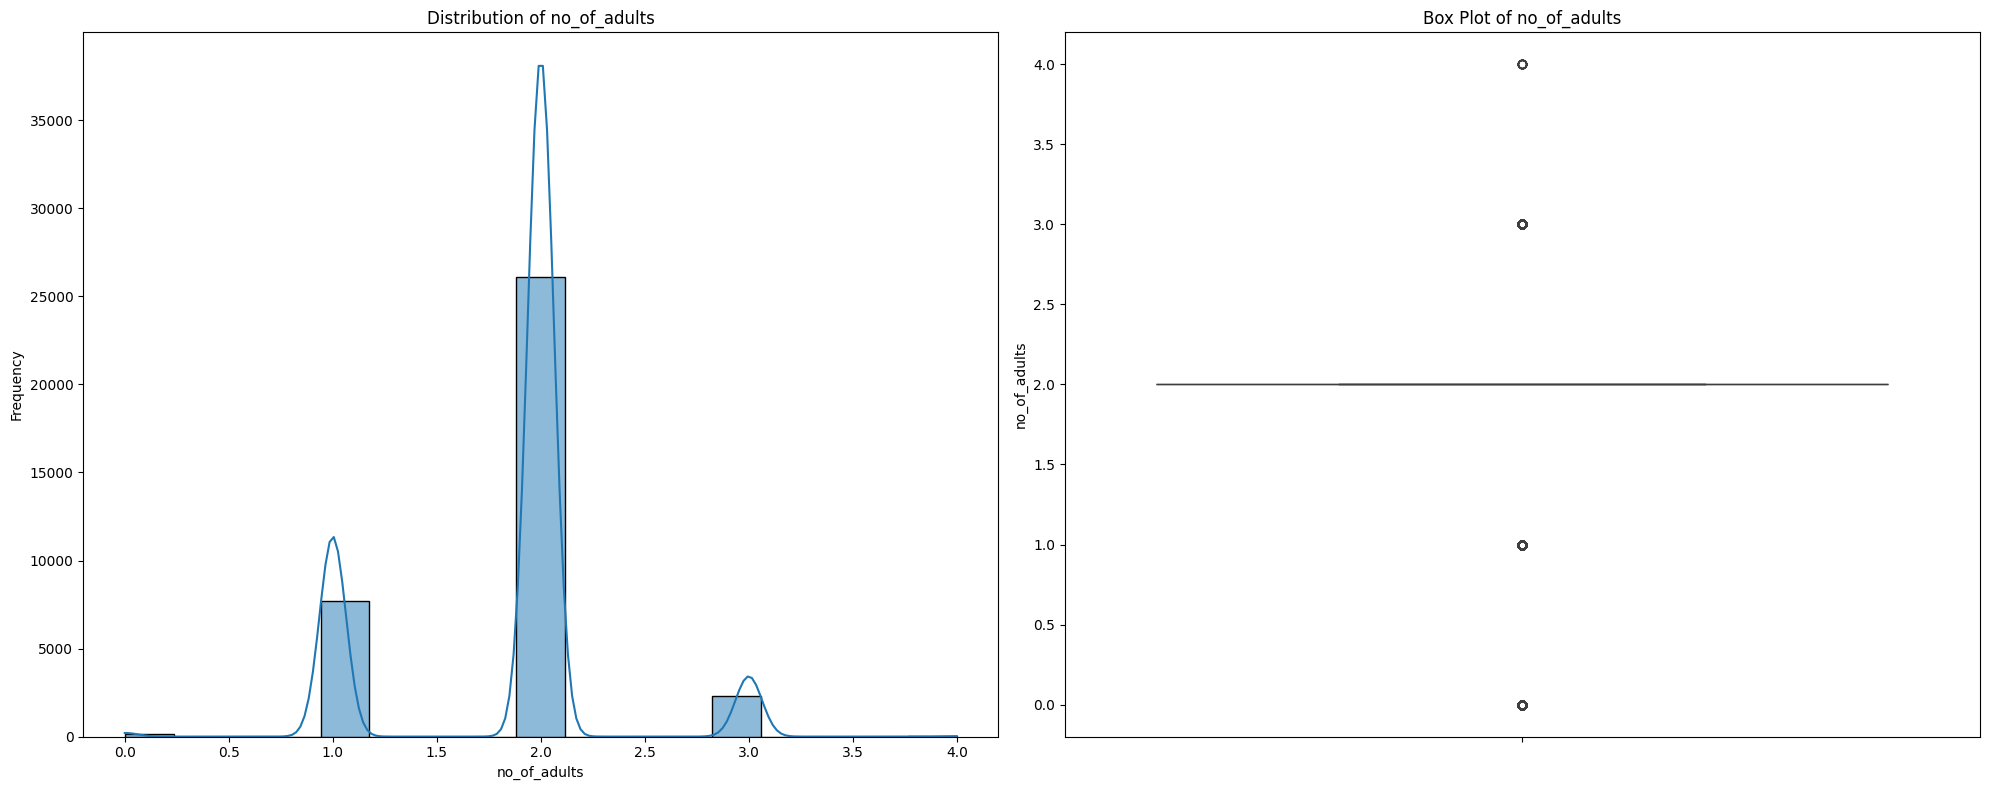

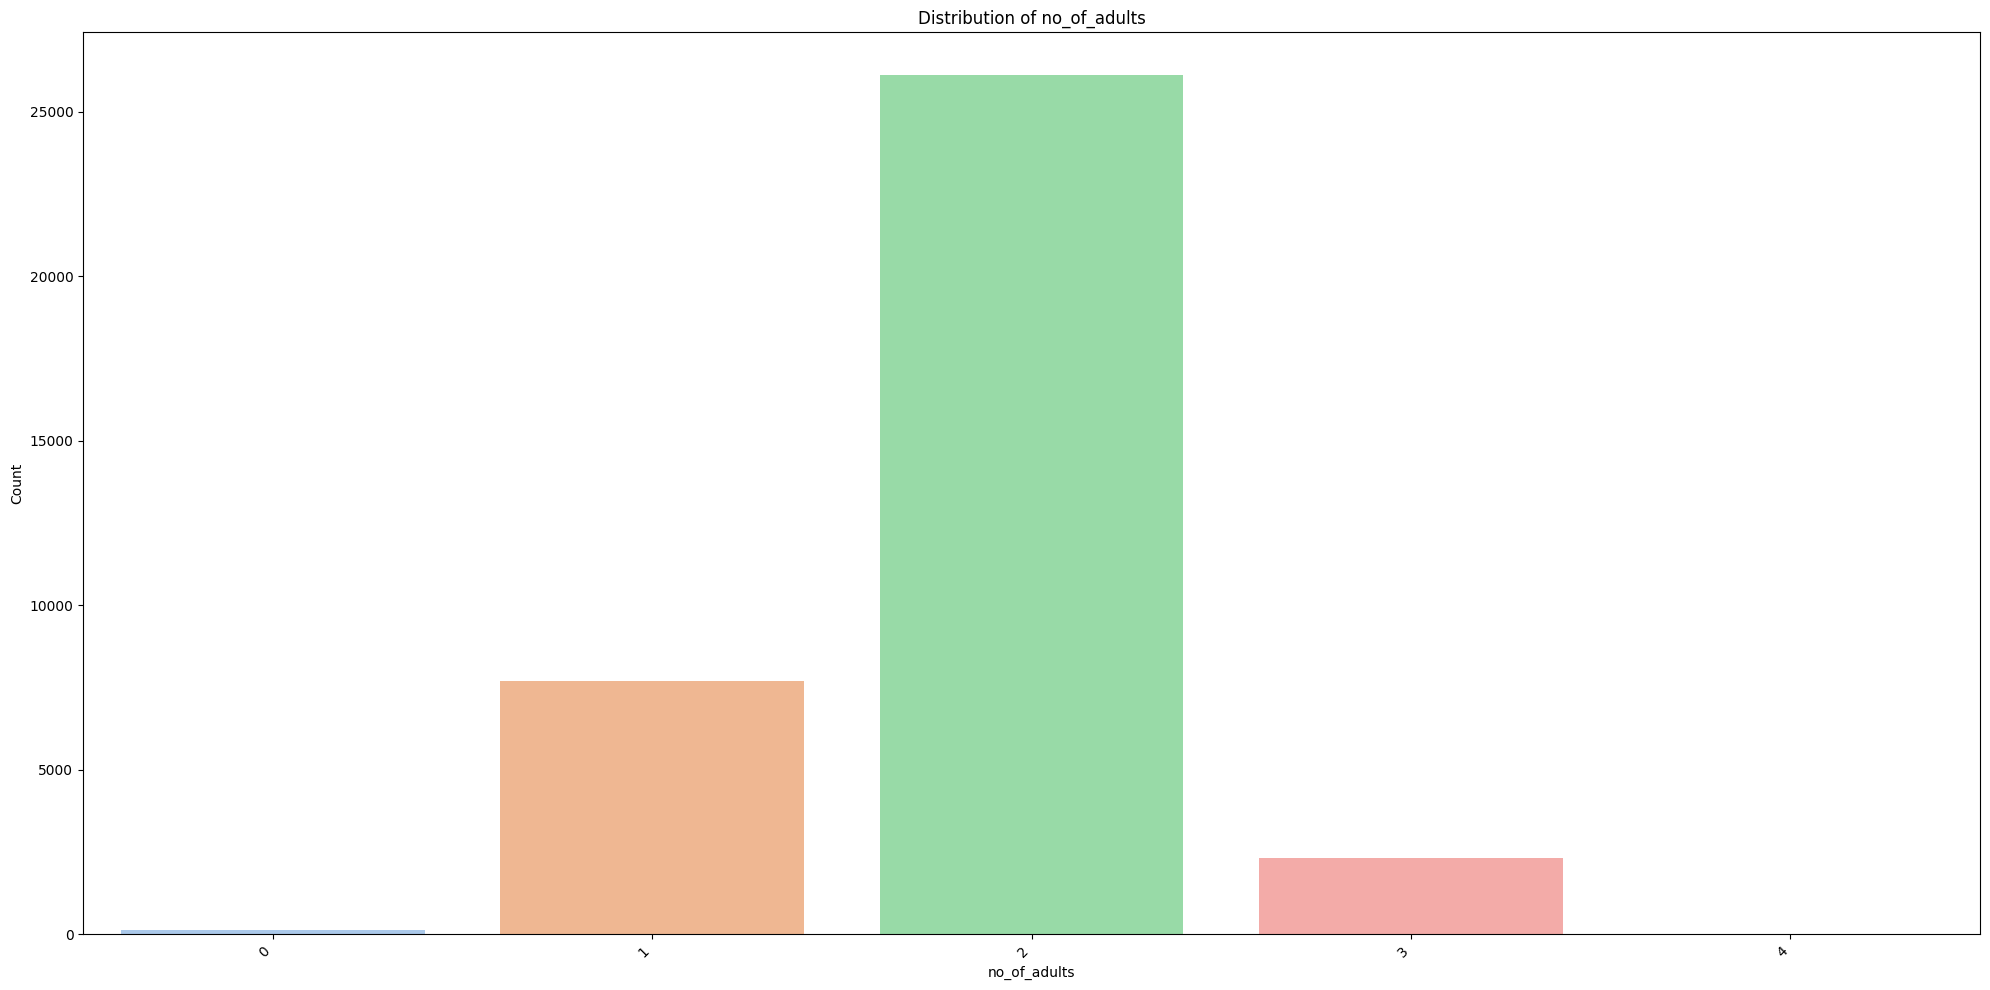


Descriptive statistics for no_of_children:
count    36275.000000
mean         0.105279
std          0.402648
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: no_of_children, dtype: float64


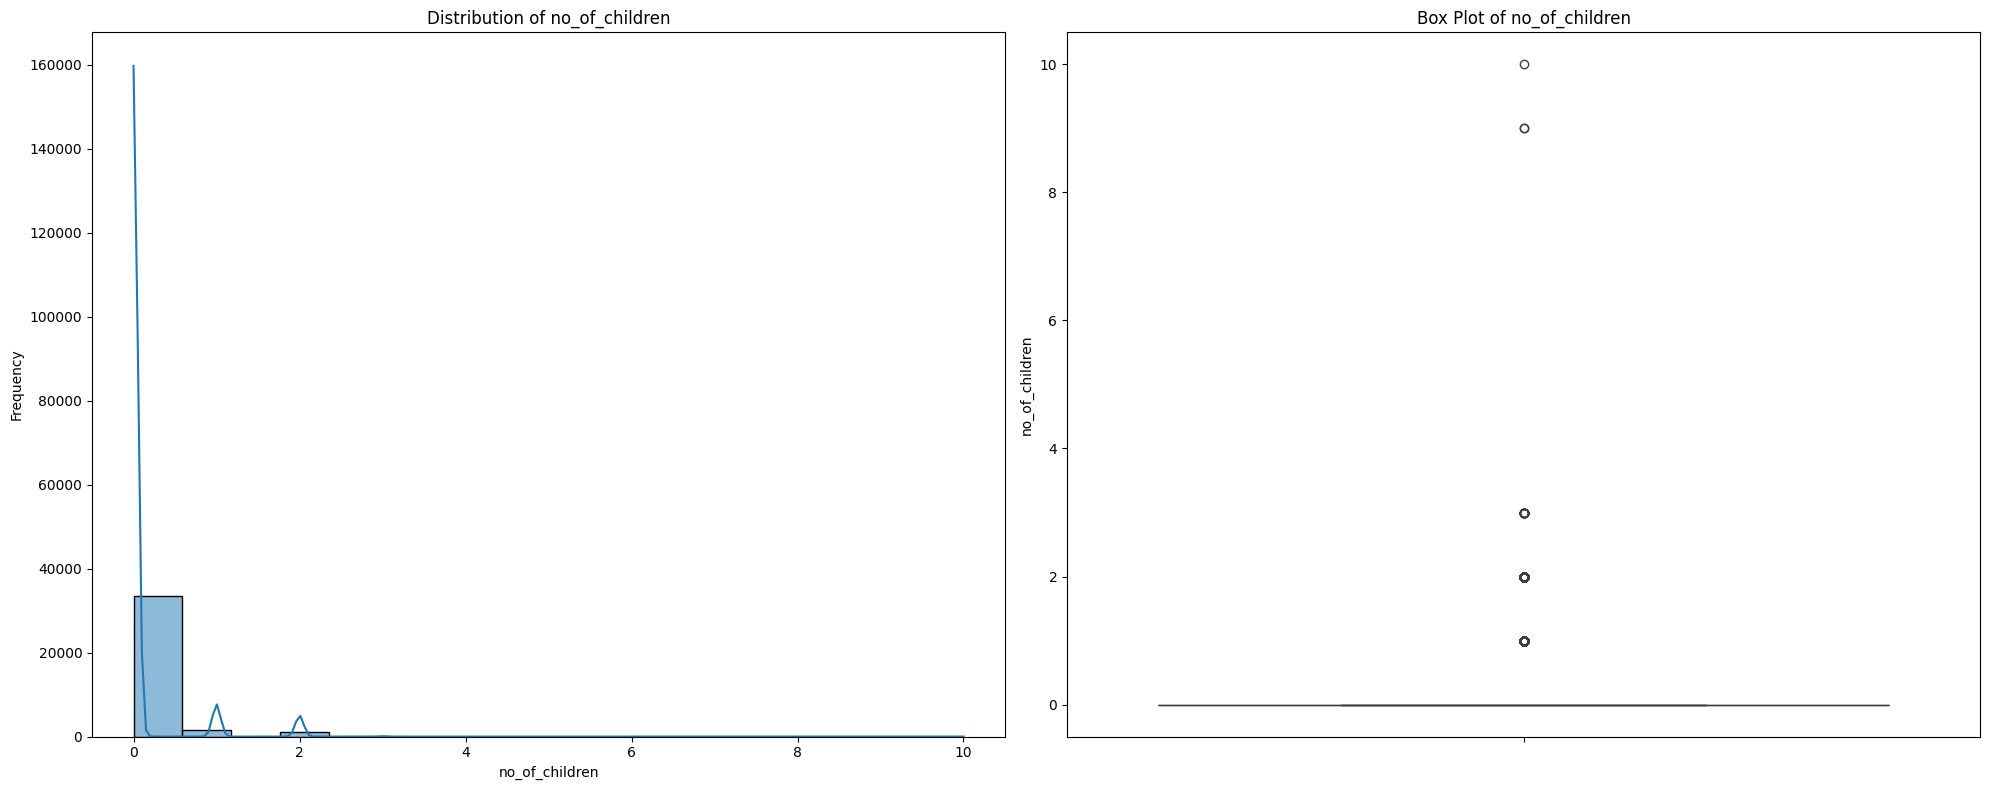

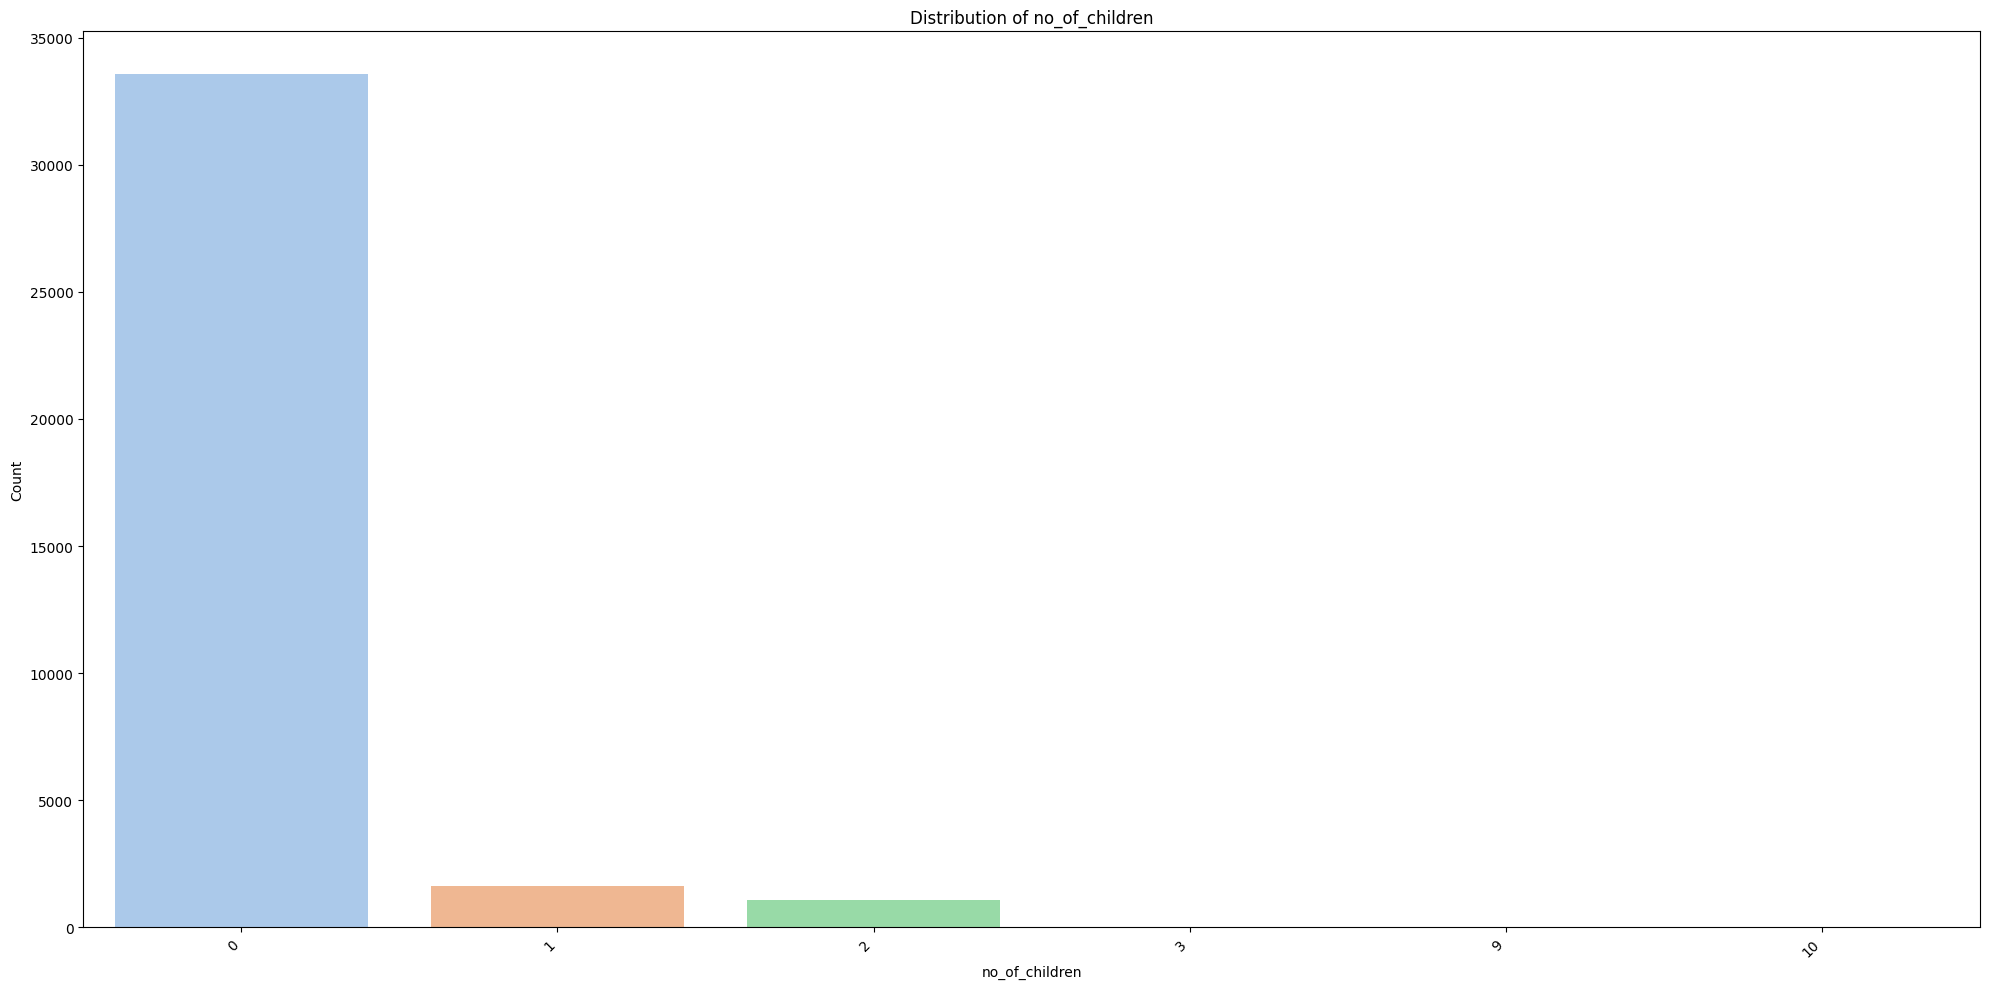


Descriptive statistics for no_of_weekend_nights:
count    36275.000000
mean         0.810724
std          0.870644
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: no_of_weekend_nights, dtype: float64


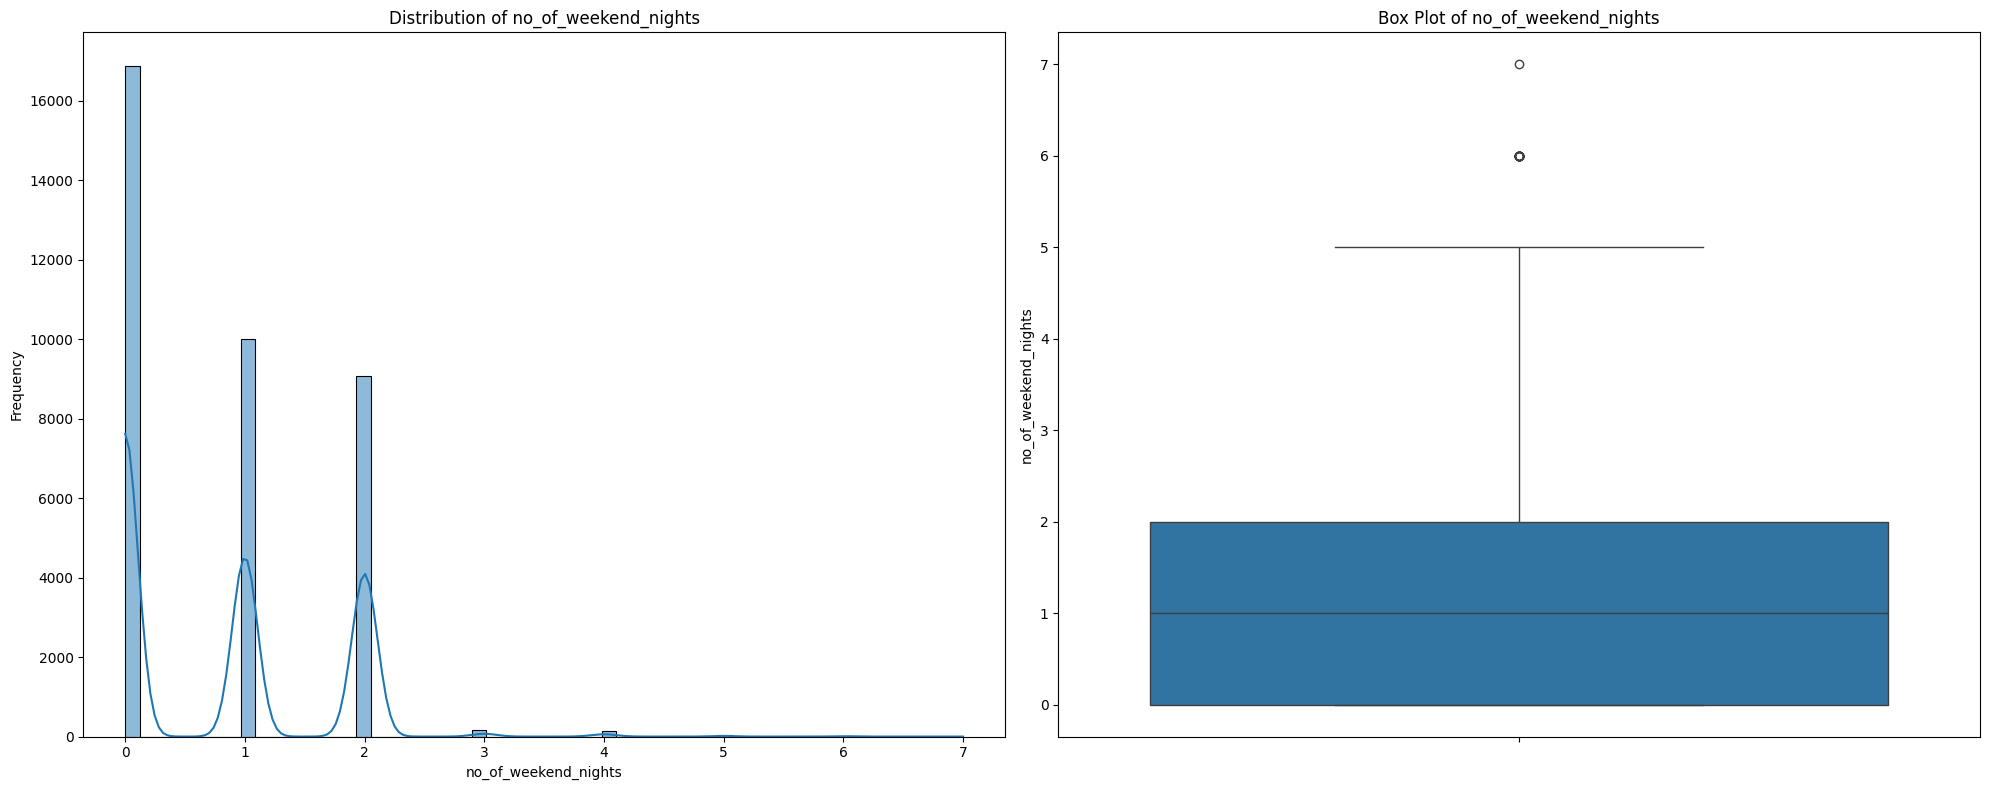

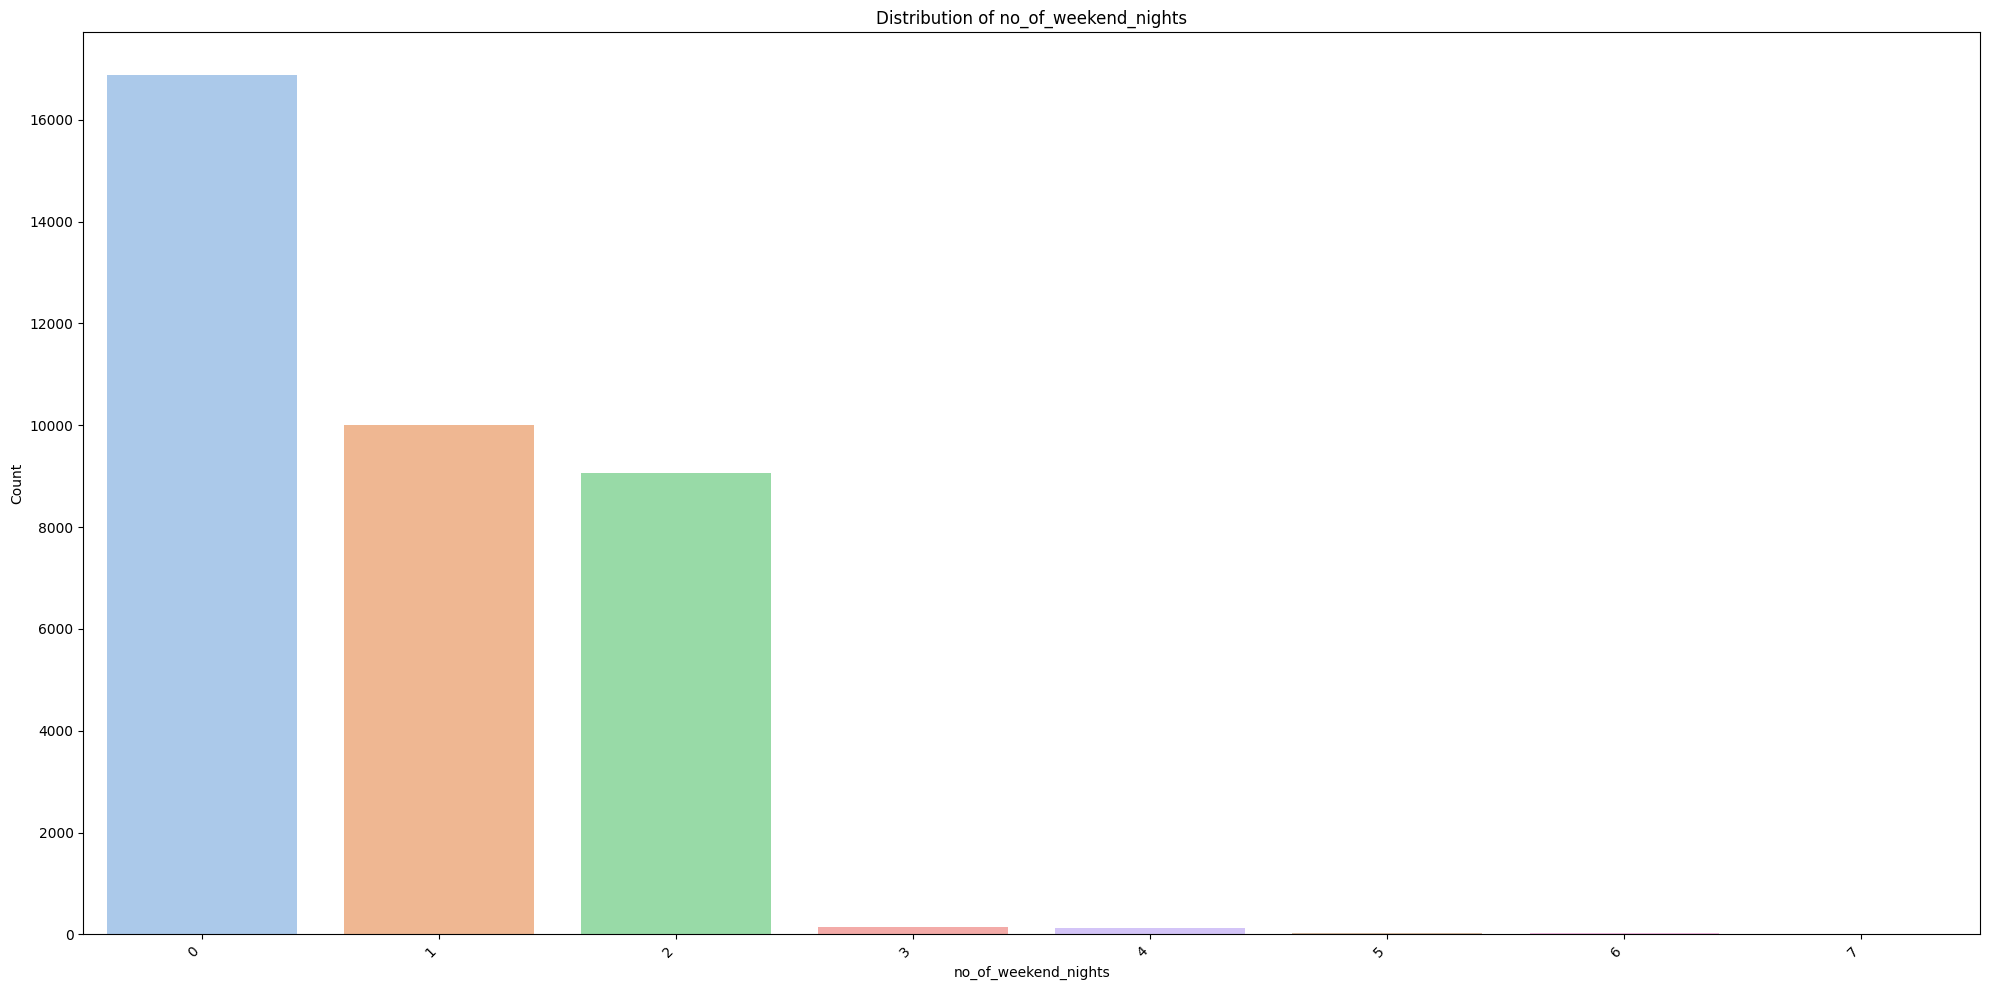


Descriptive statistics for no_of_week_nights:
count    36275.000000
mean         2.204300
std          1.410905
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         17.000000
Name: no_of_week_nights, dtype: float64


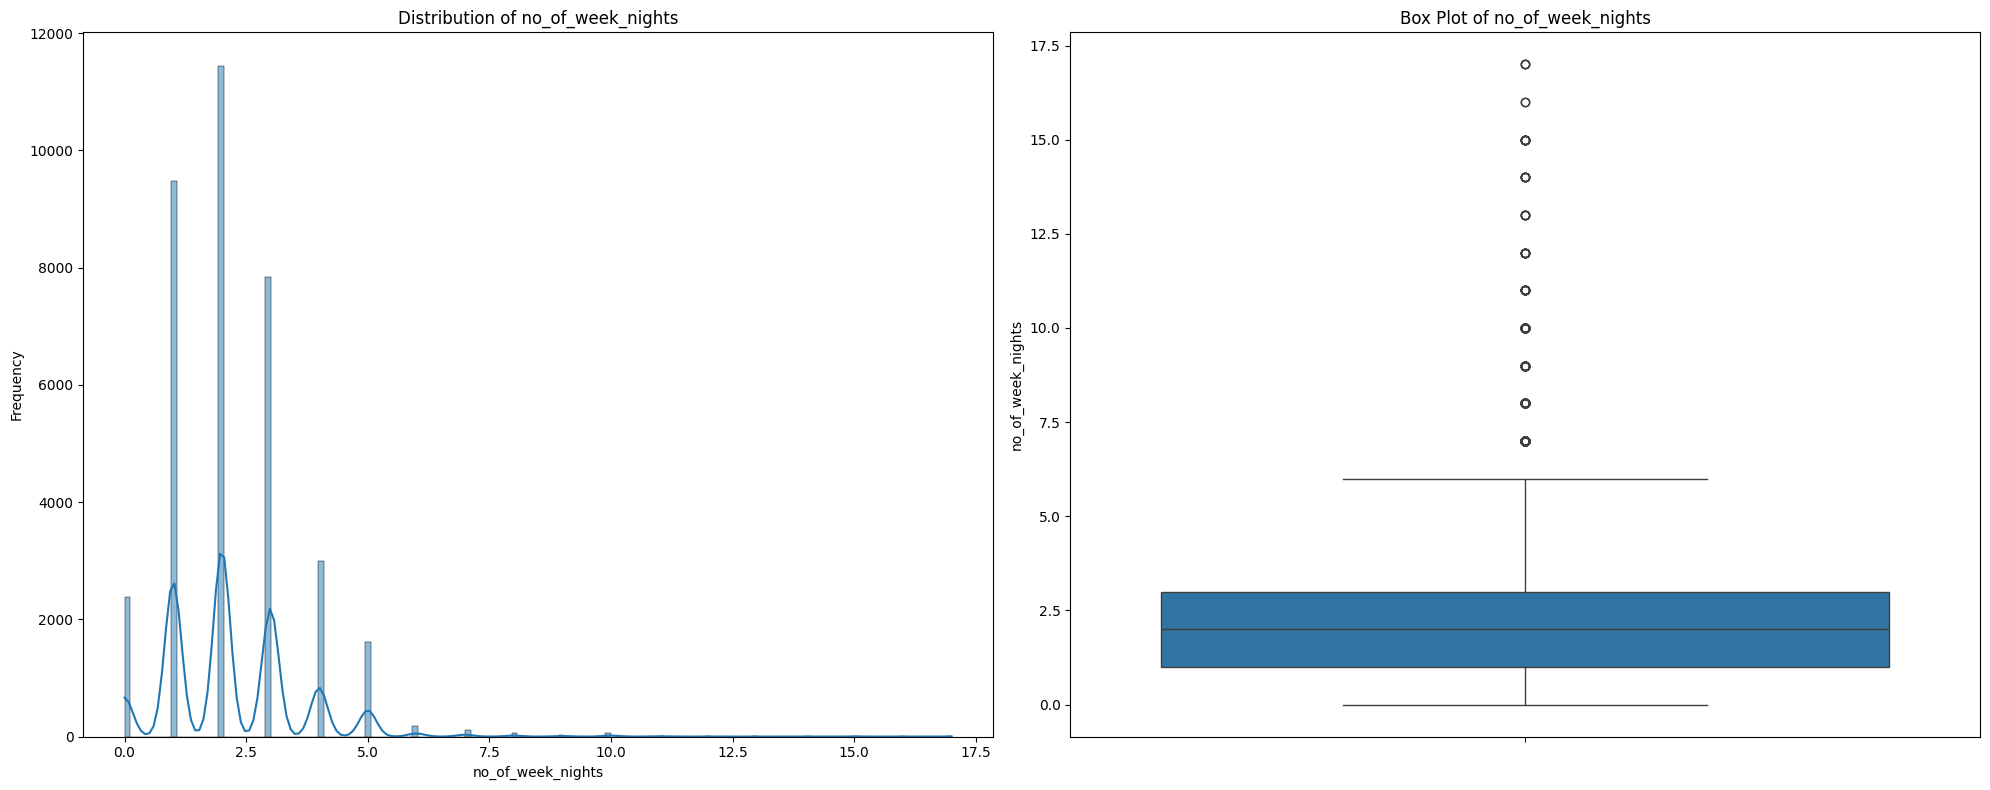

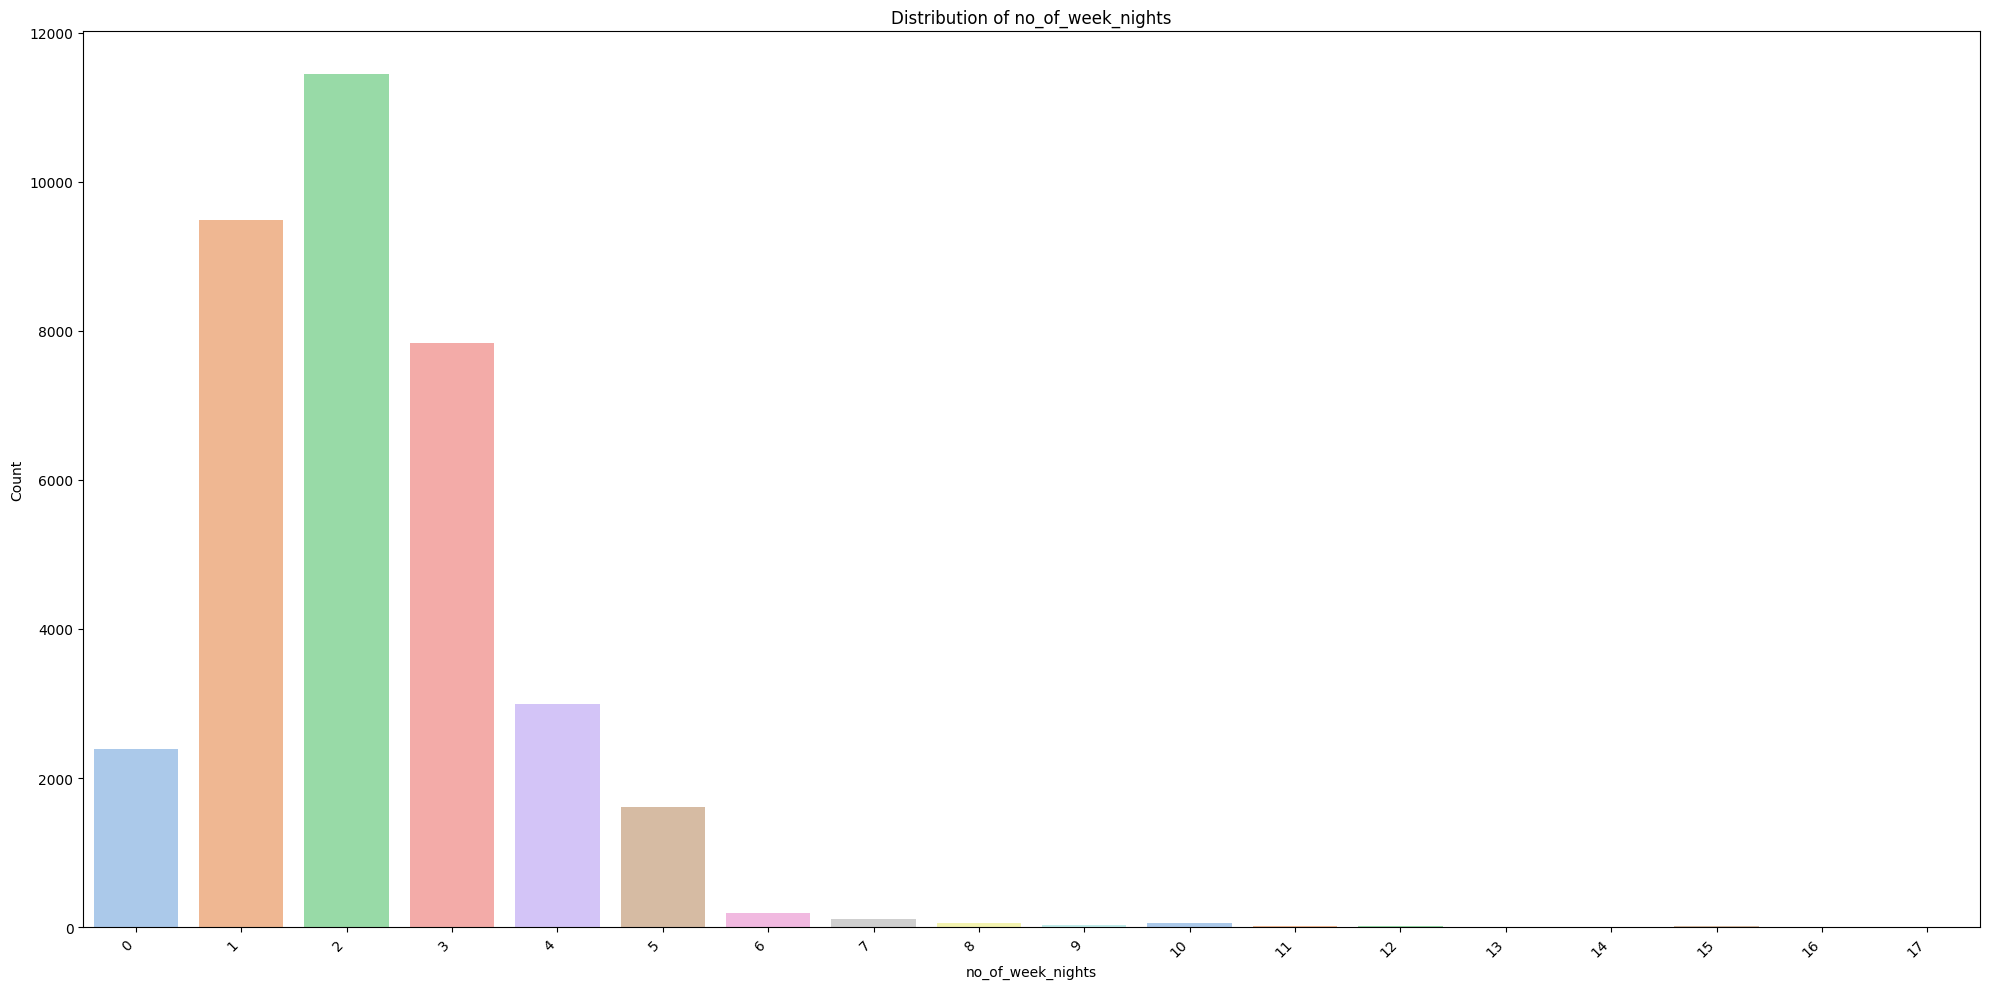


Descriptive statistics for required_car_parking_space:
count    36275.000000
mean         0.030986
std          0.173281
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: required_car_parking_space, dtype: float64


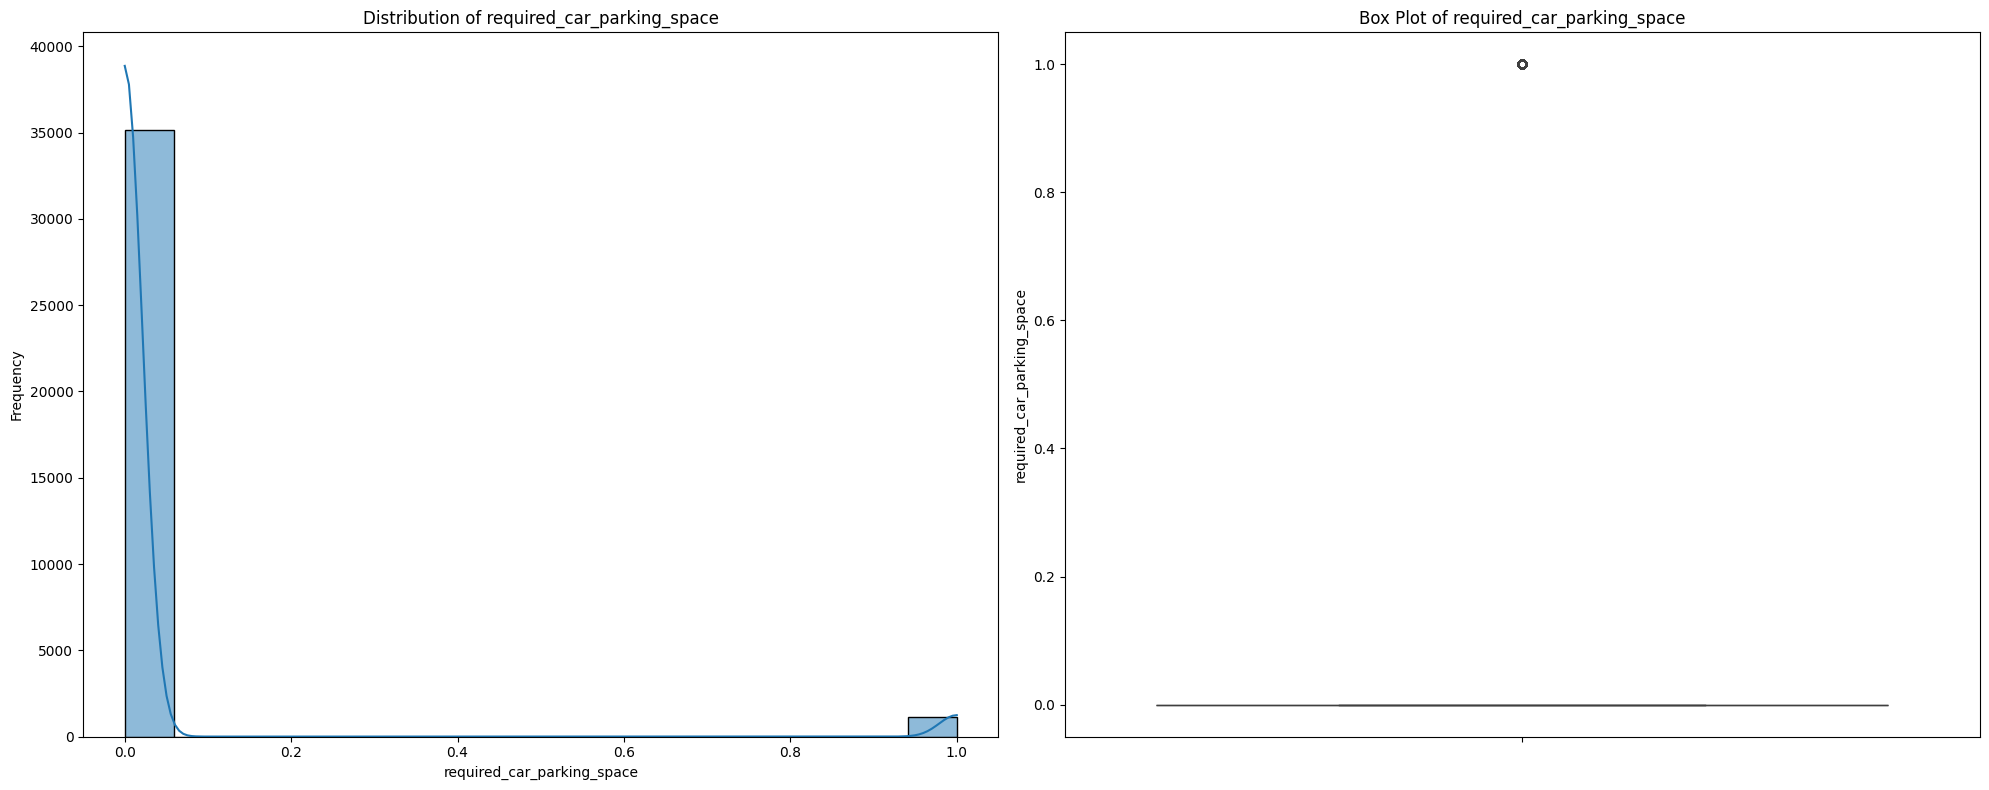

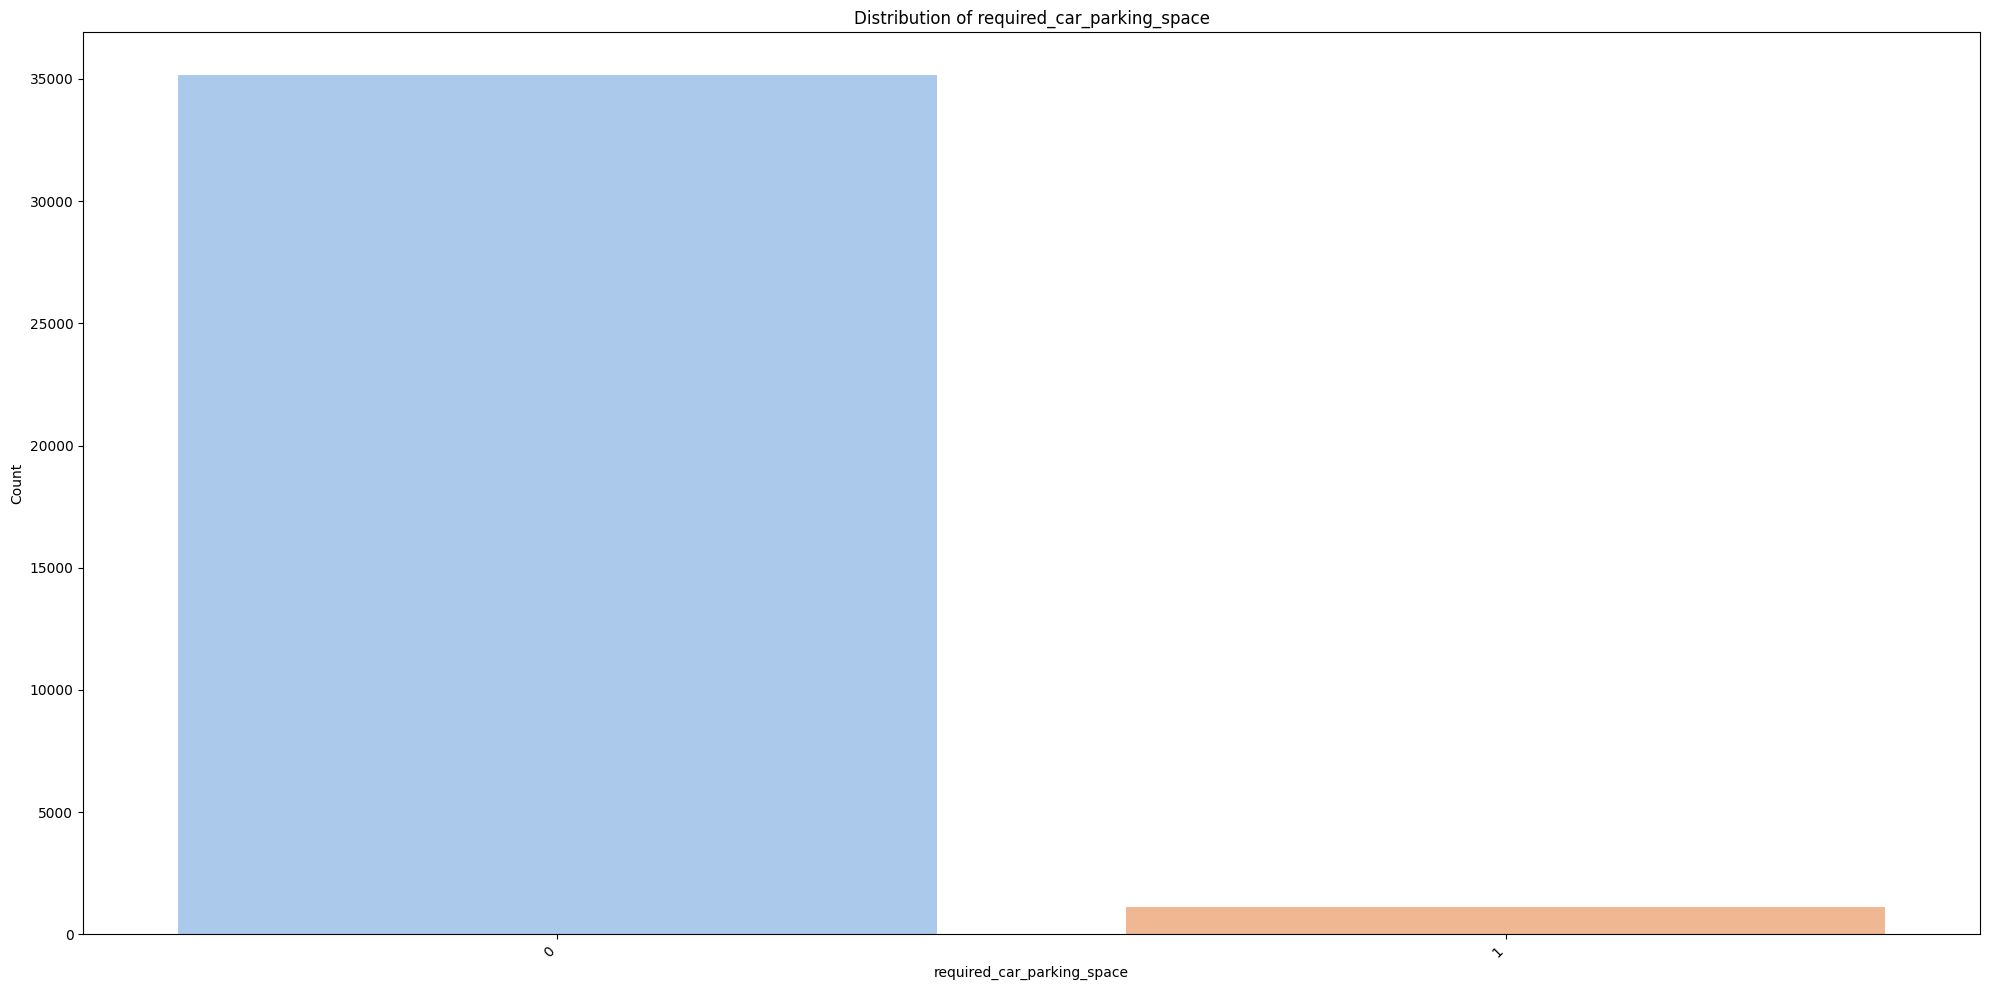


Descriptive statistics for lead_time:
count    36275.000000
mean        85.232557
std         85.930817
min          0.000000
25%         17.000000
50%         57.000000
75%        126.000000
max        443.000000
Name: lead_time, dtype: float64


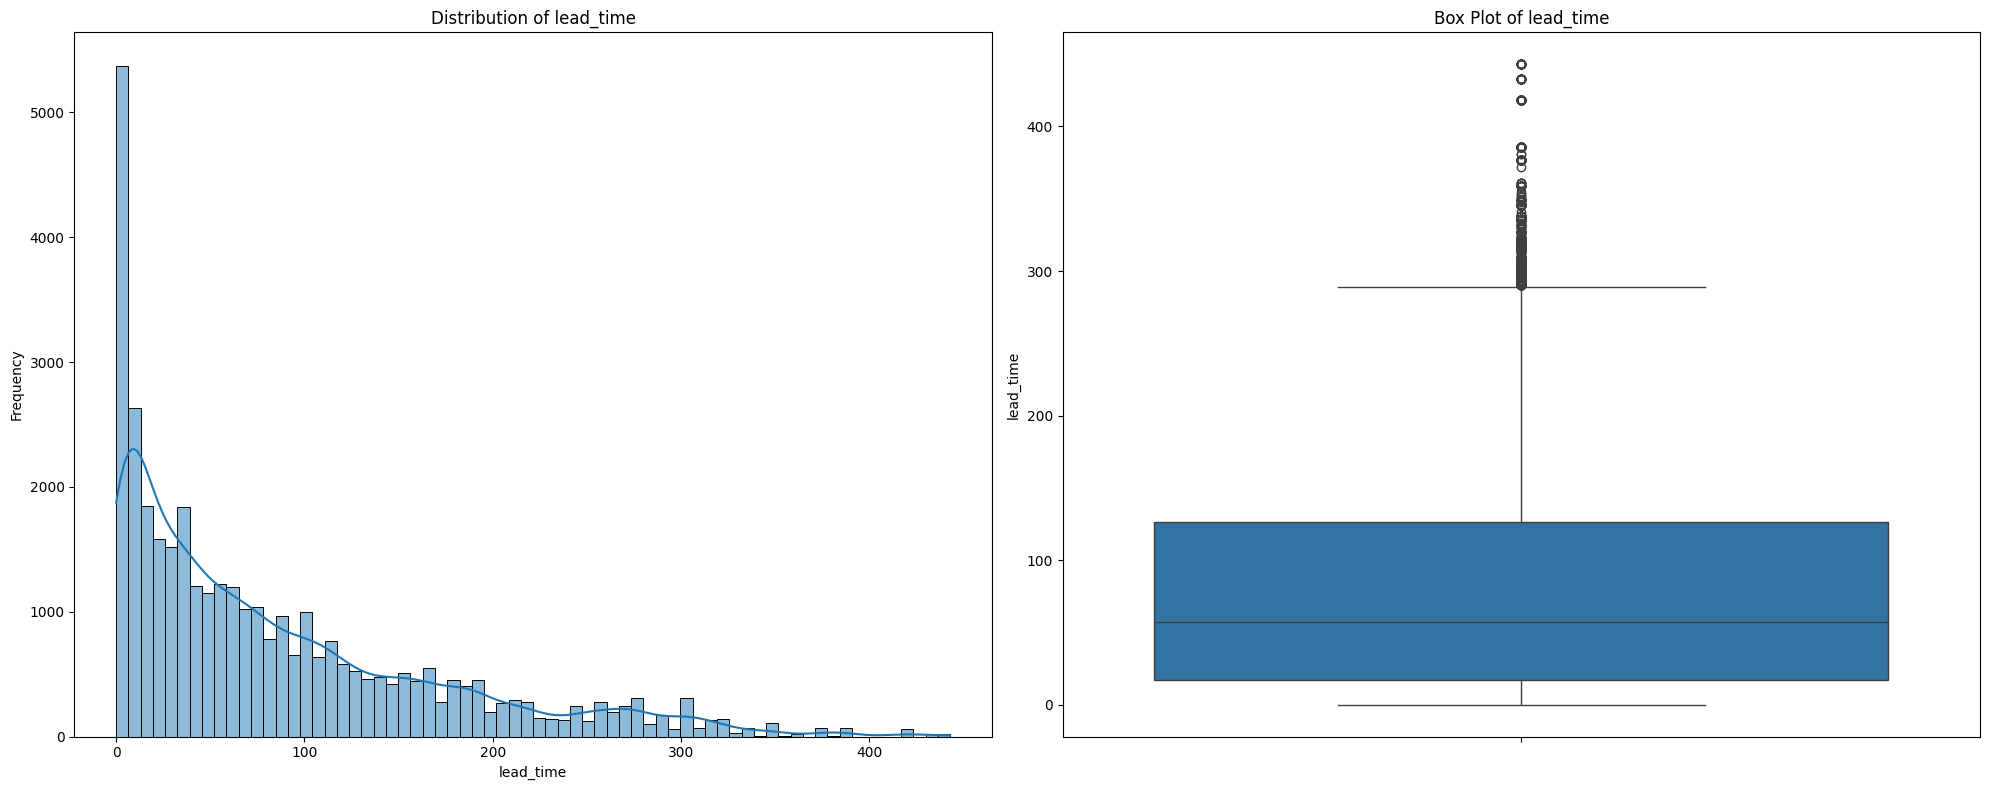

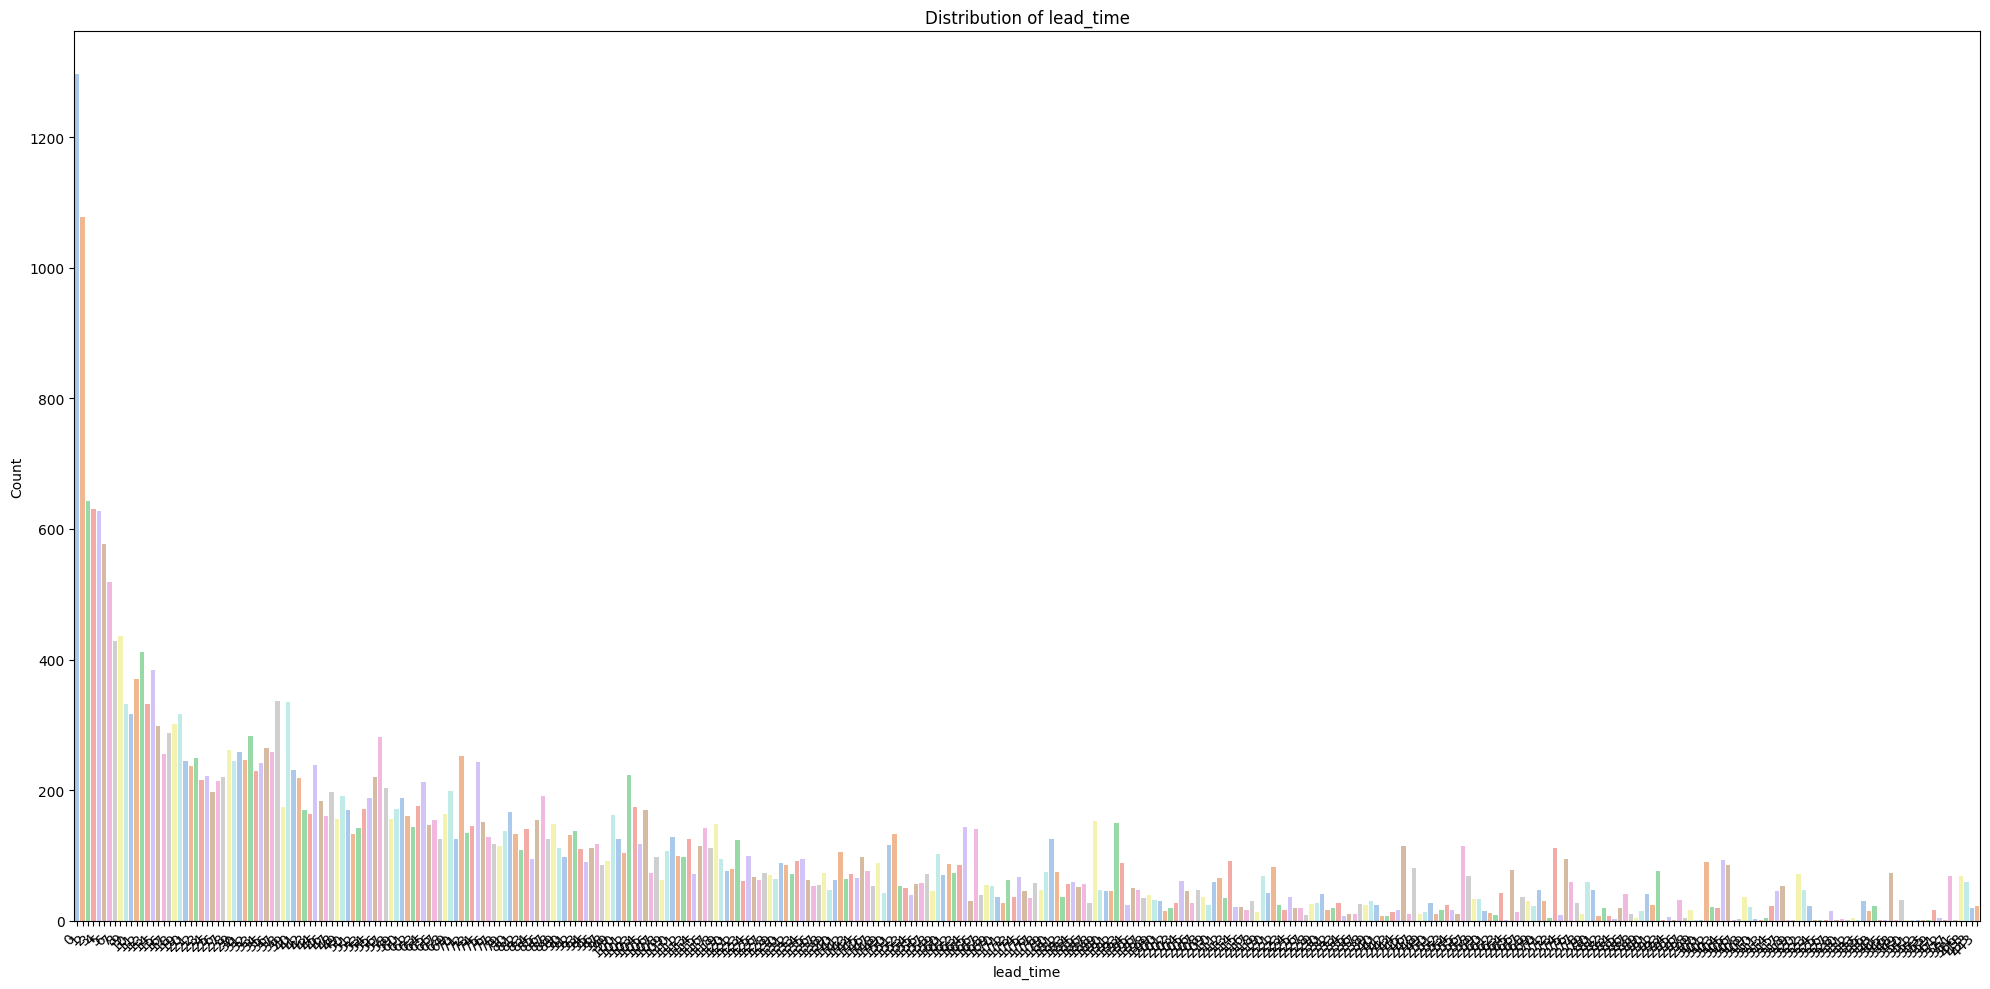


Descriptive statistics for arrival_year:
count    36275.000000
mean      2017.820427
std          0.383836
min       2017.000000
25%       2018.000000
50%       2018.000000
75%       2018.000000
max       2018.000000
Name: arrival_year, dtype: float64


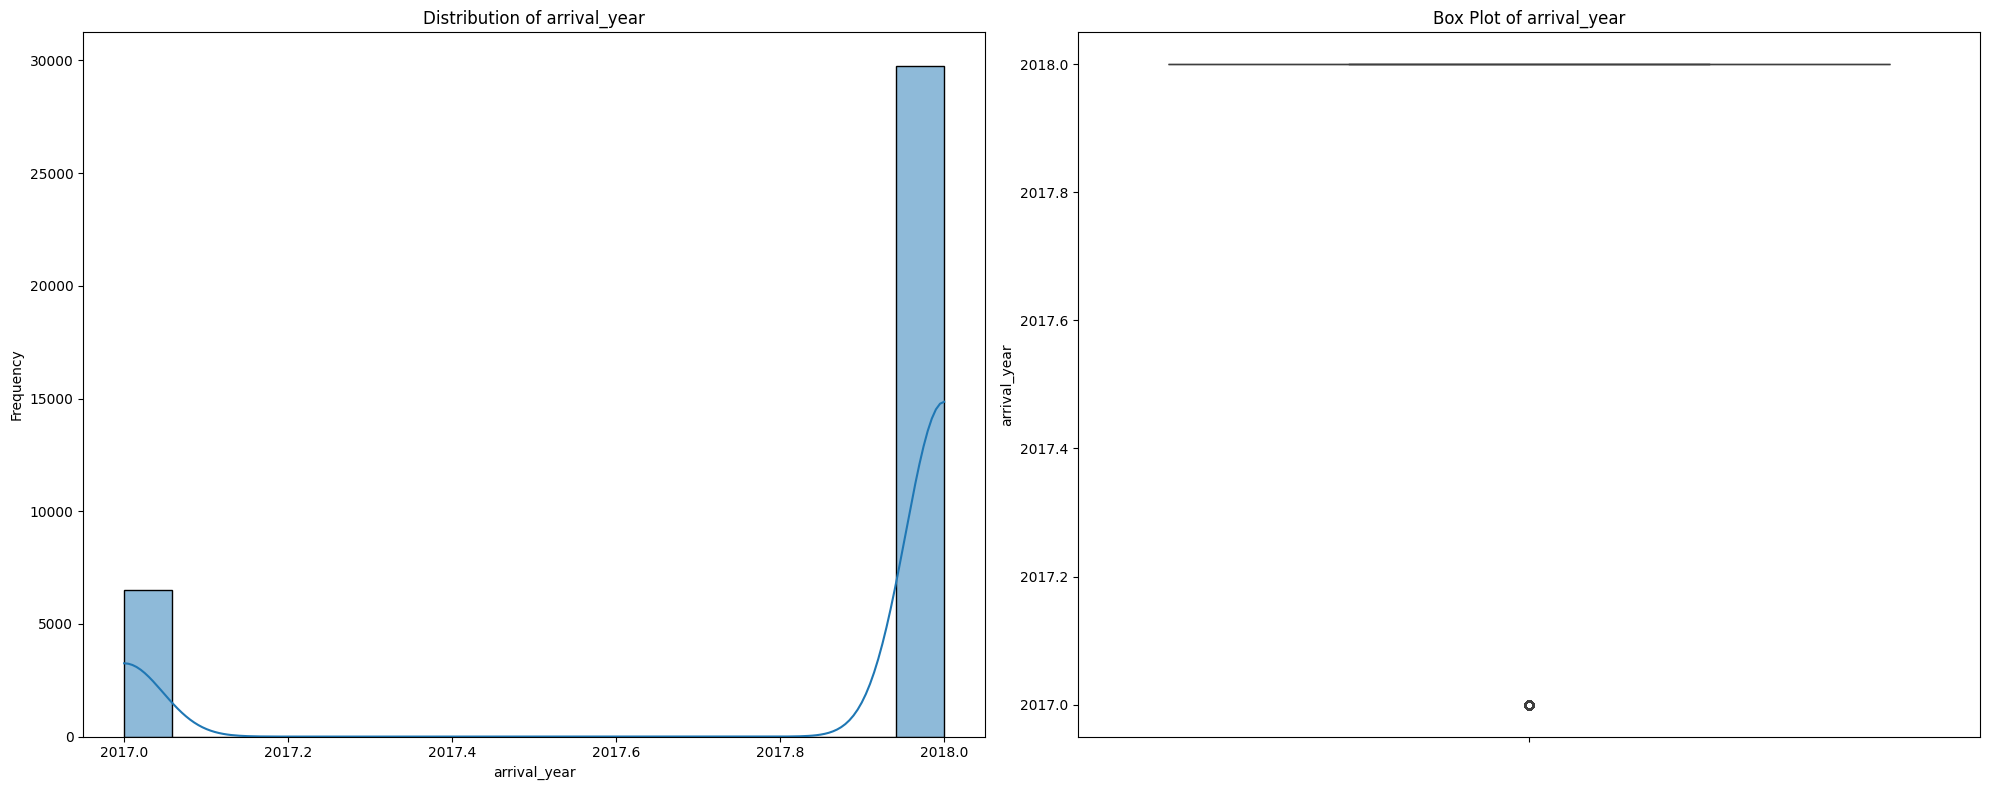

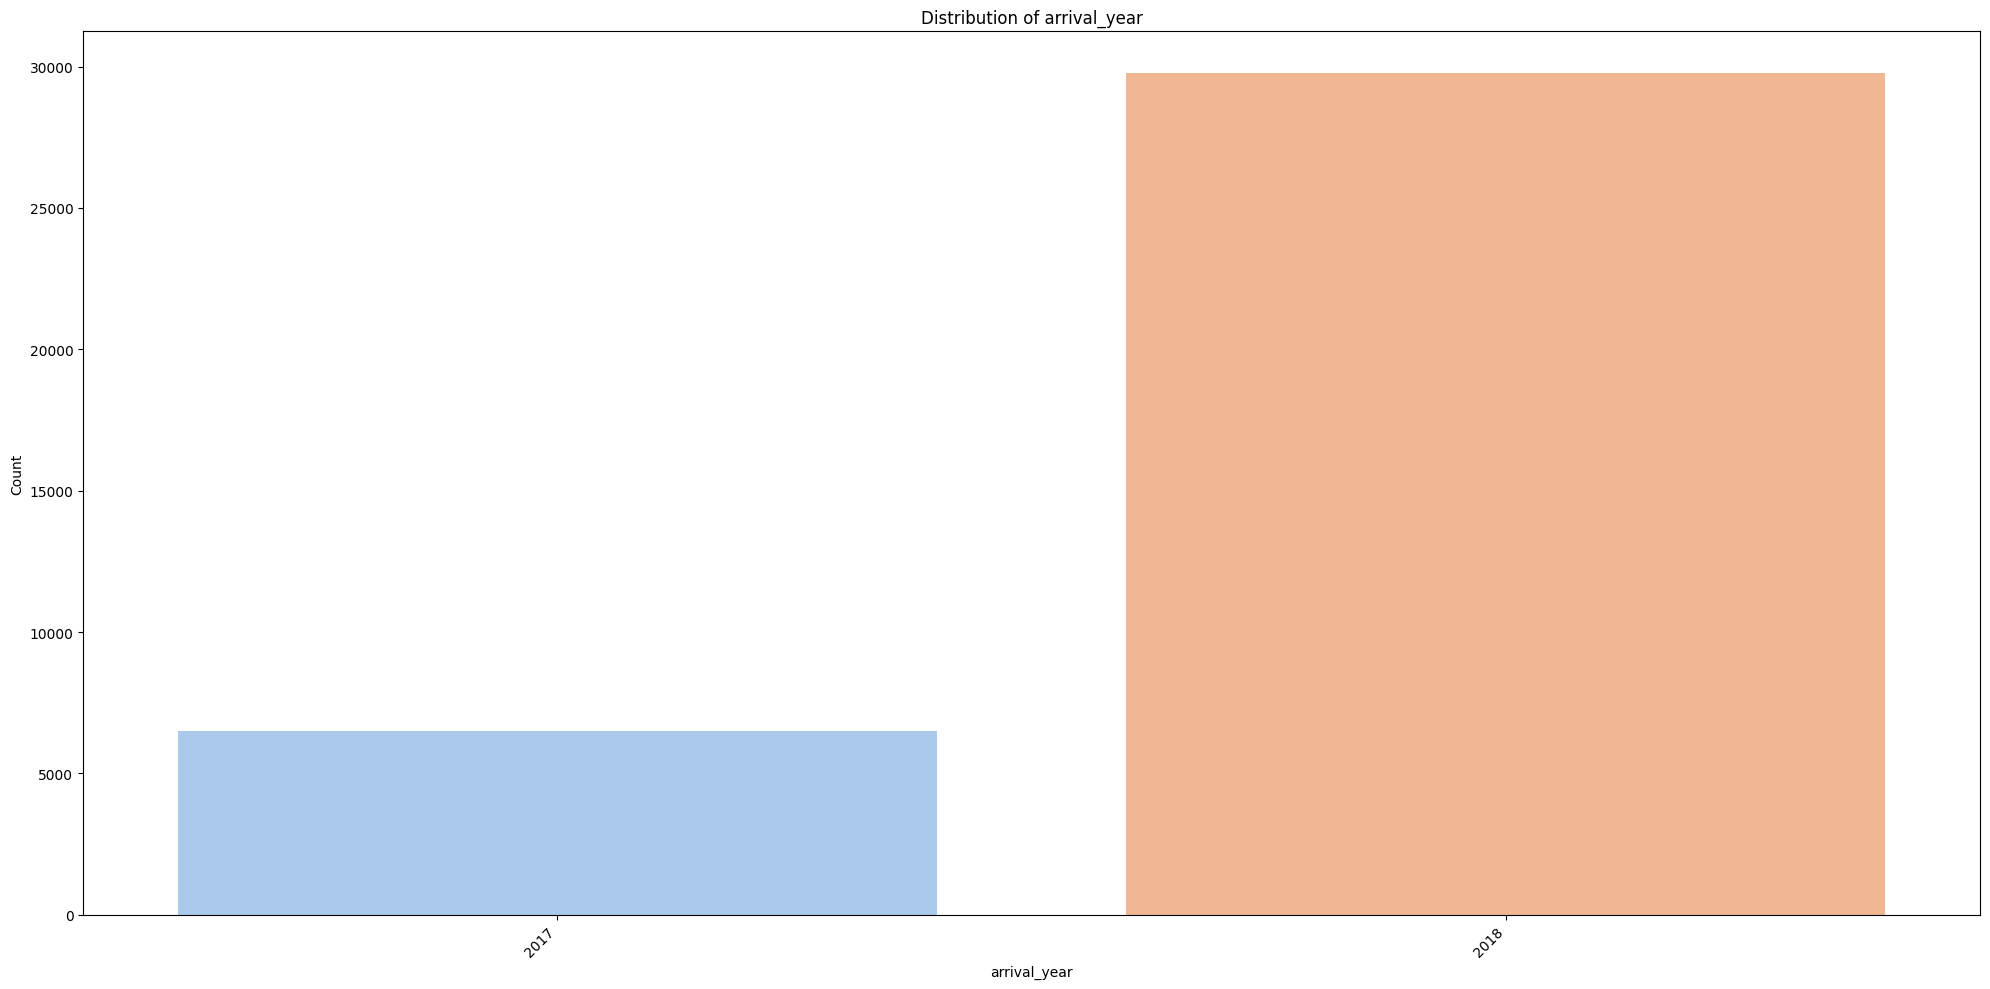


Descriptive statistics for arrival_month:
count    36275.000000
mean         7.423653
std          3.069894
min          1.000000
25%          5.000000
50%          8.000000
75%         10.000000
max         12.000000
Name: arrival_month, dtype: float64


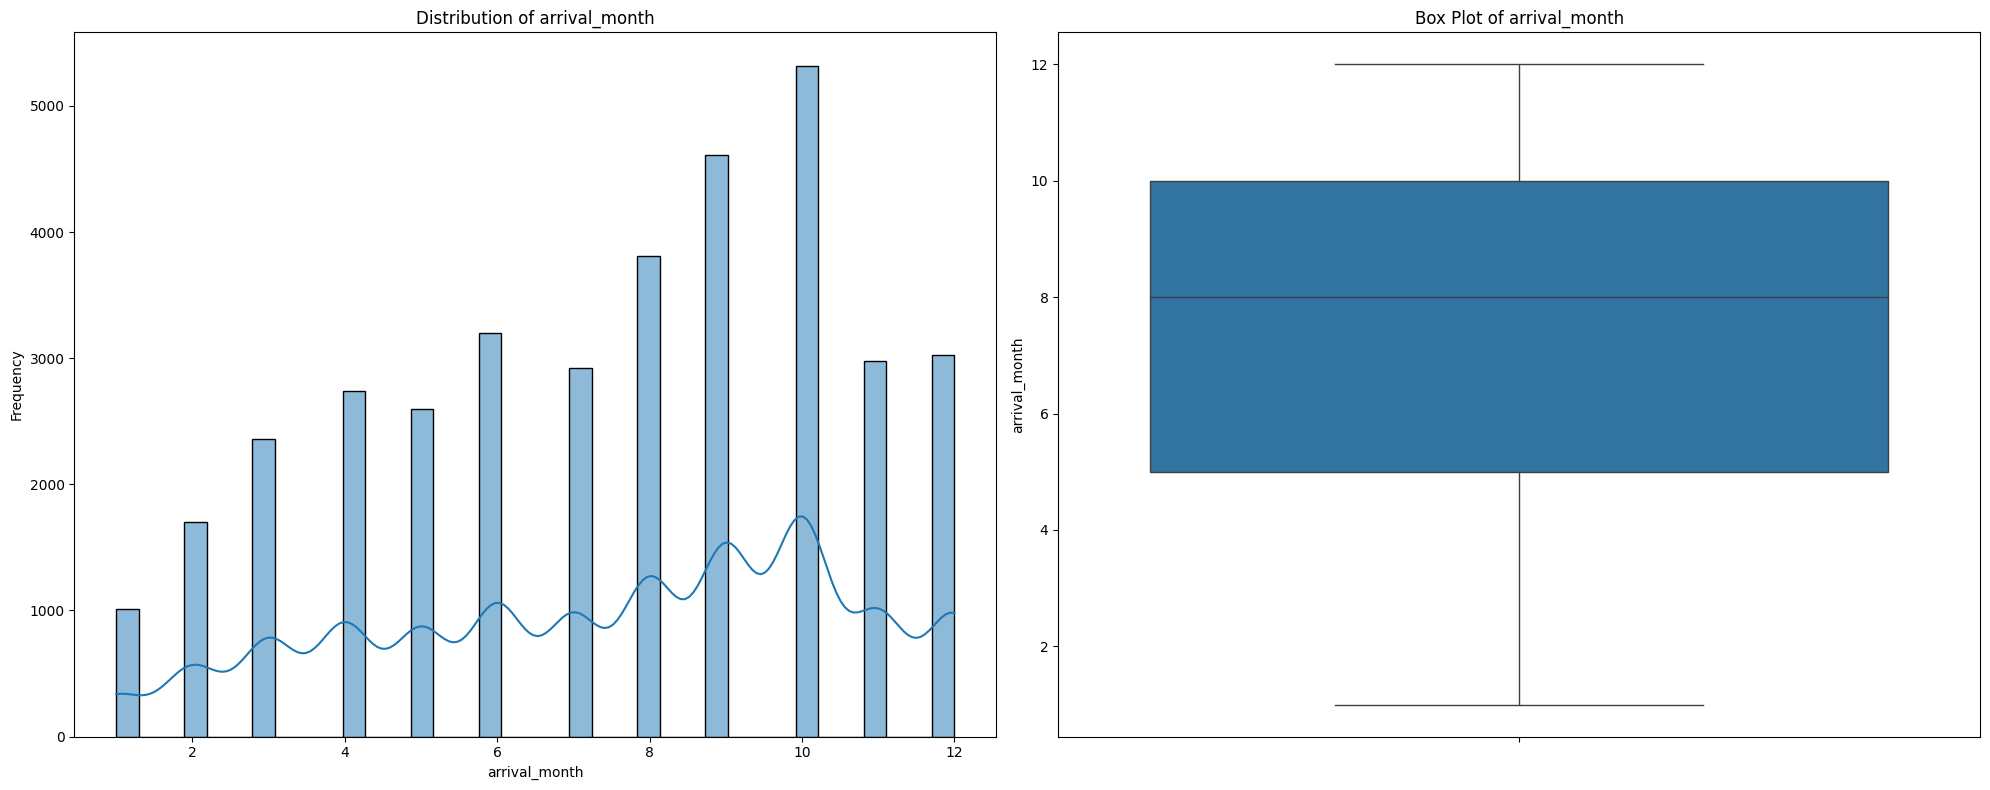

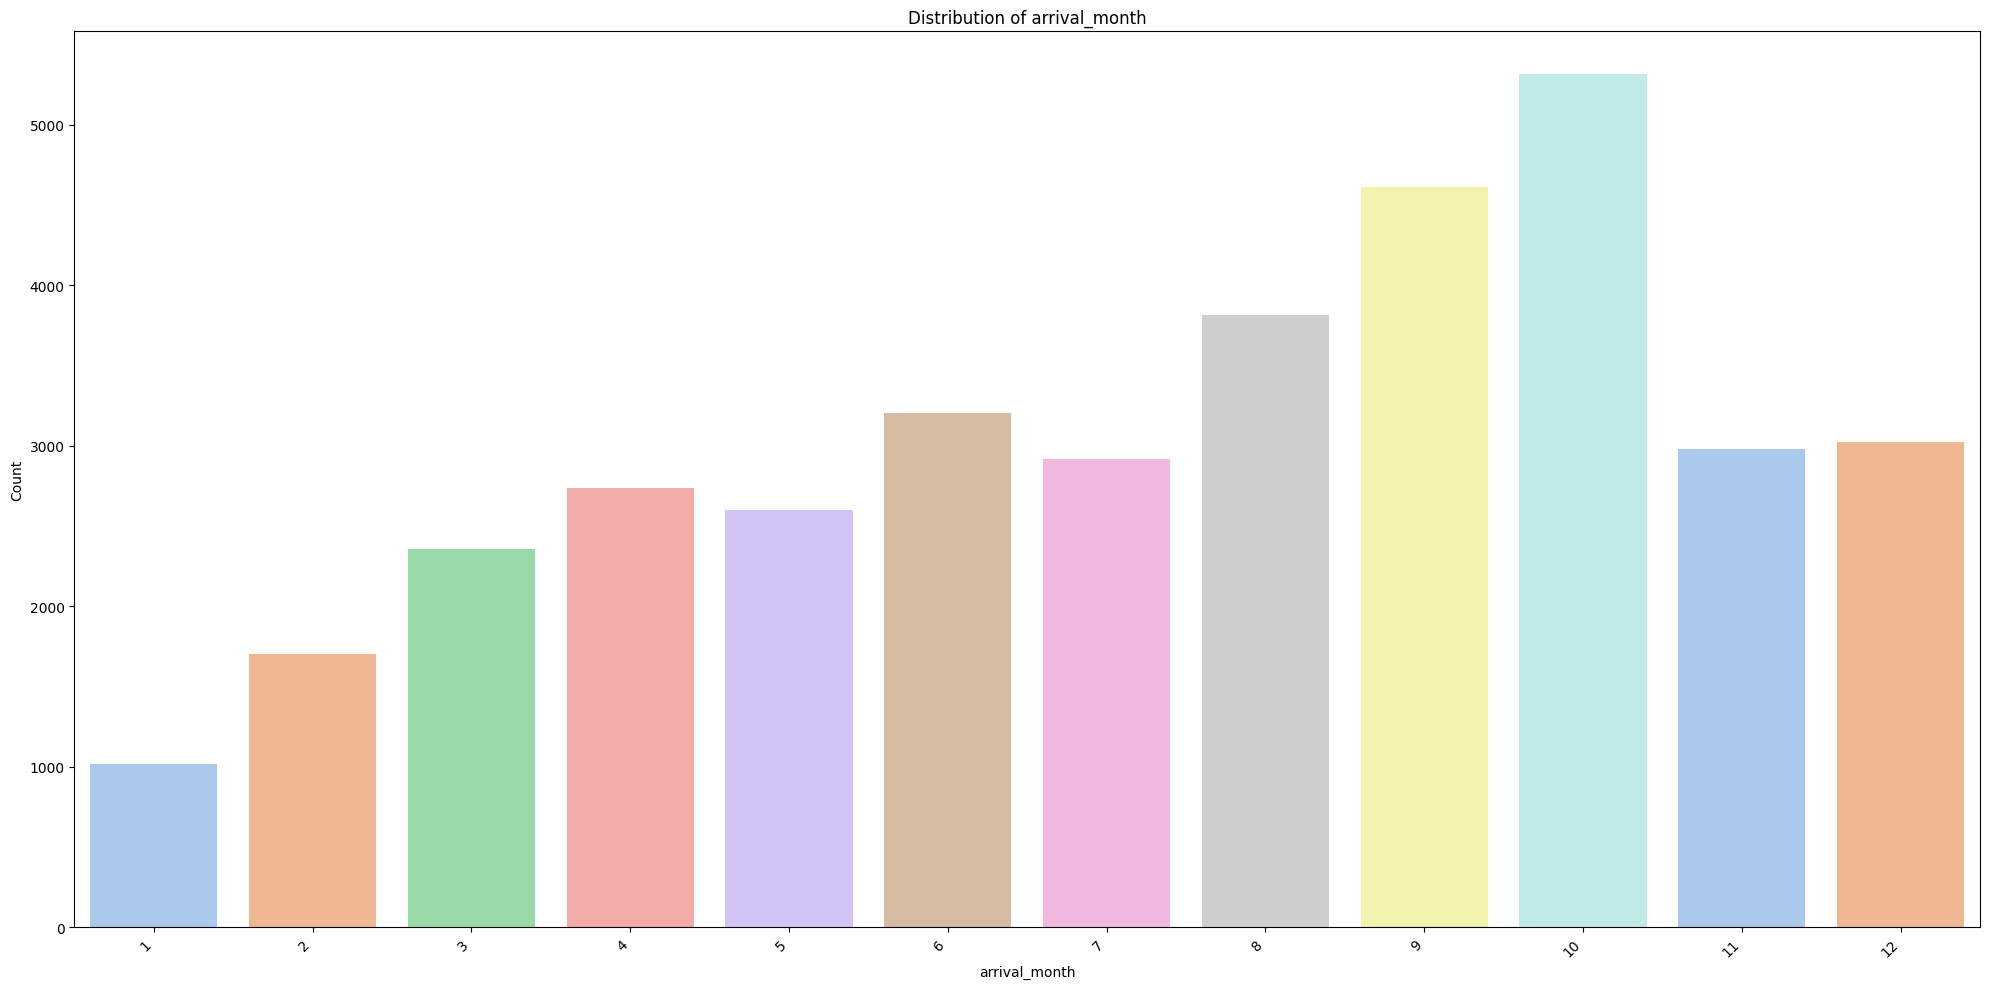


Descriptive statistics for arrival_date:
count    36275.000000
mean        15.596995
std          8.740447
min          1.000000
25%          8.000000
50%         16.000000
75%         23.000000
max         31.000000
Name: arrival_date, dtype: float64


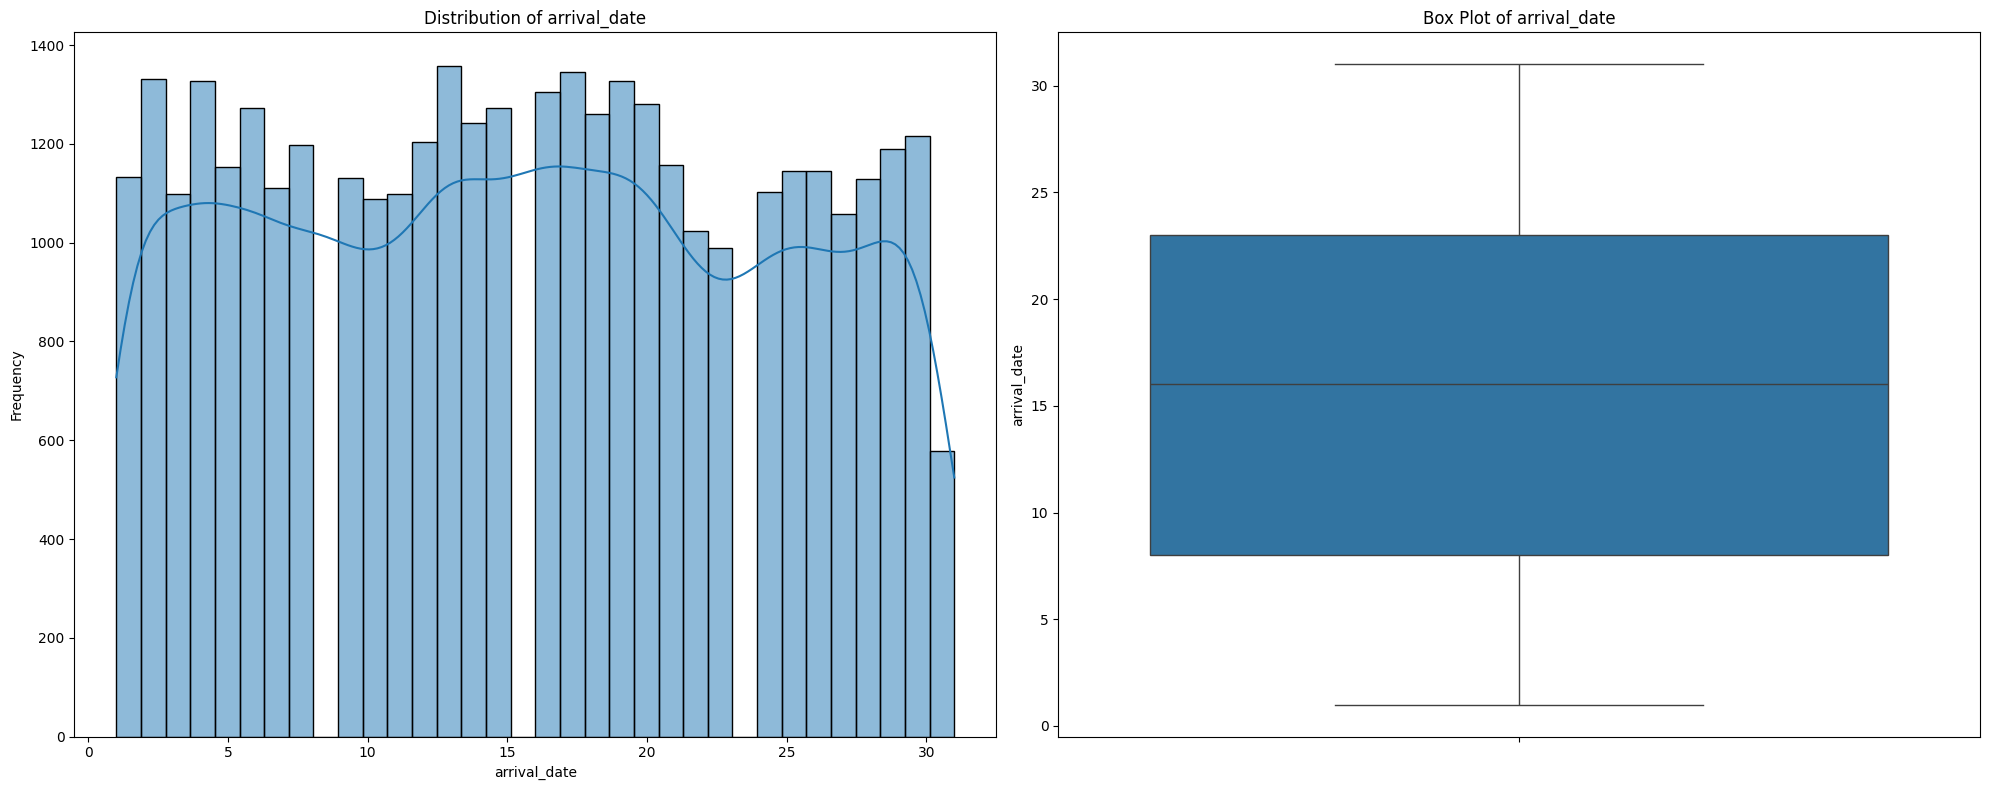

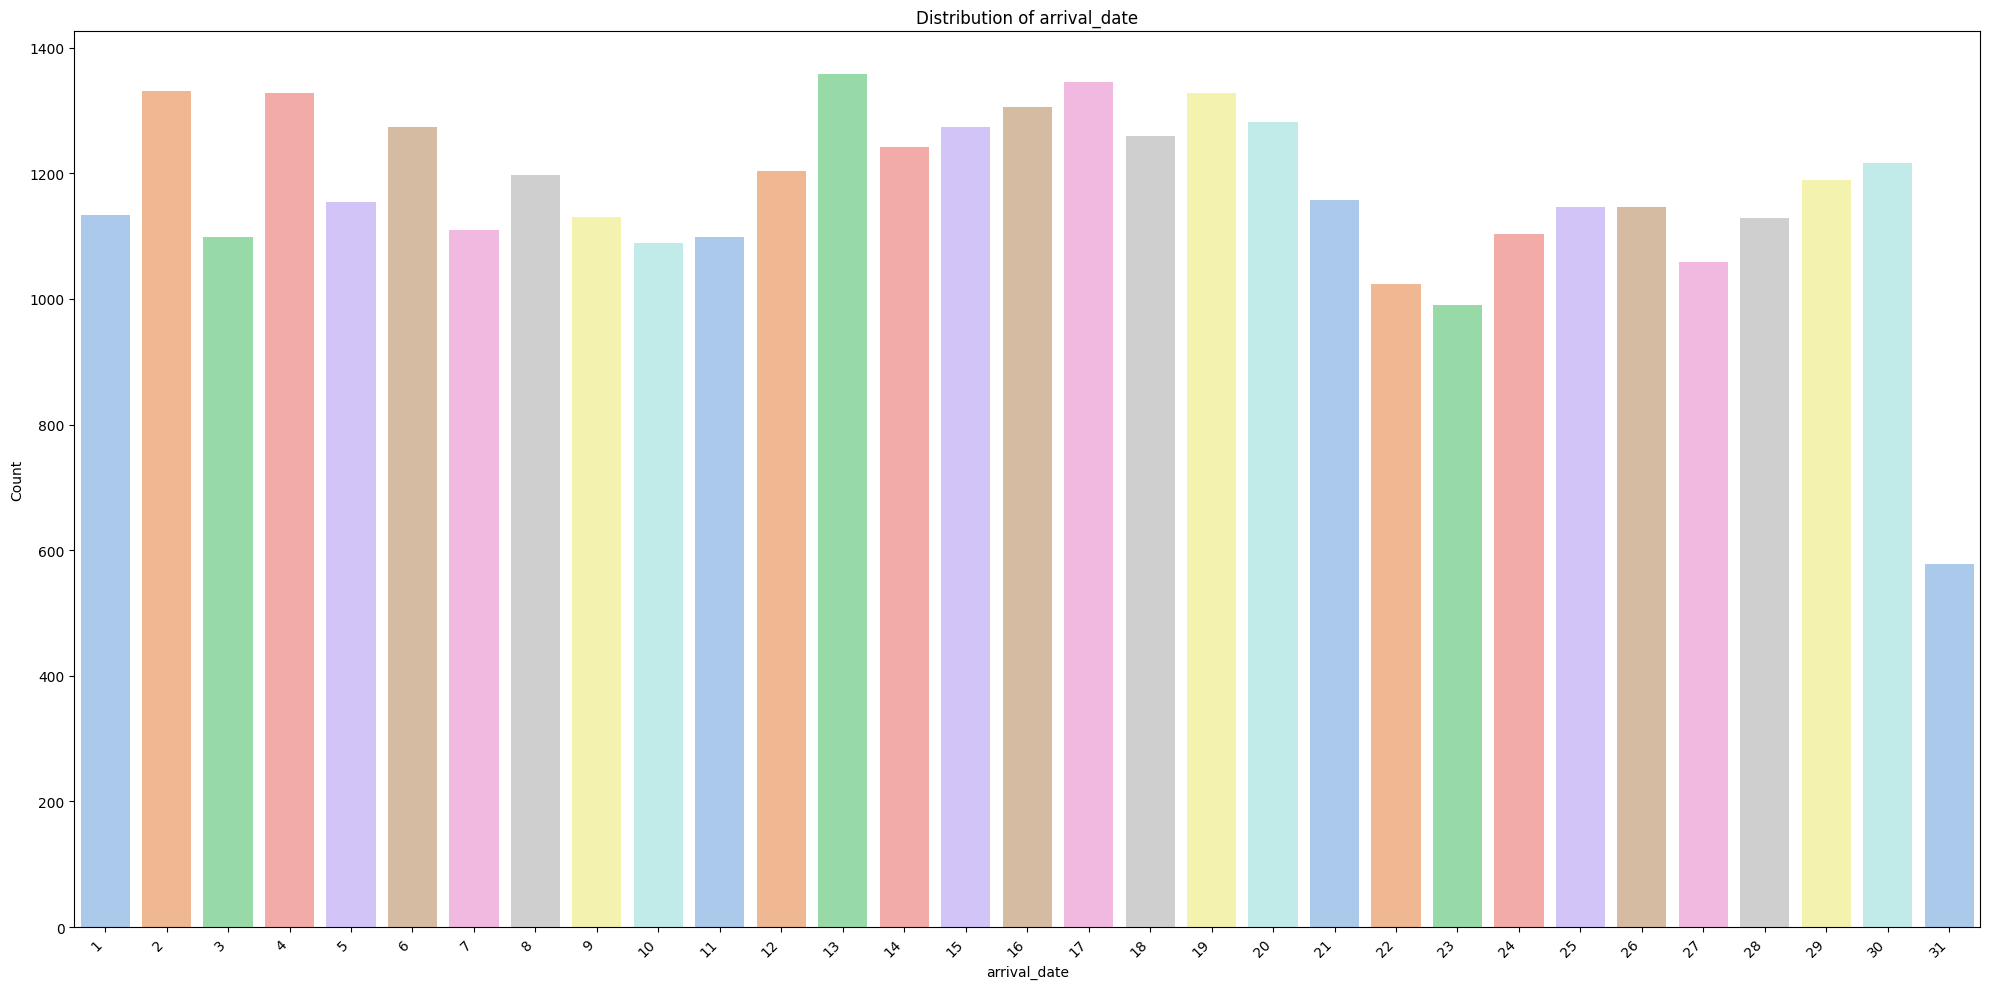


Descriptive statistics for repeated_guest:
count    36275.000000
mean         0.025637
std          0.158053
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: repeated_guest, dtype: float64


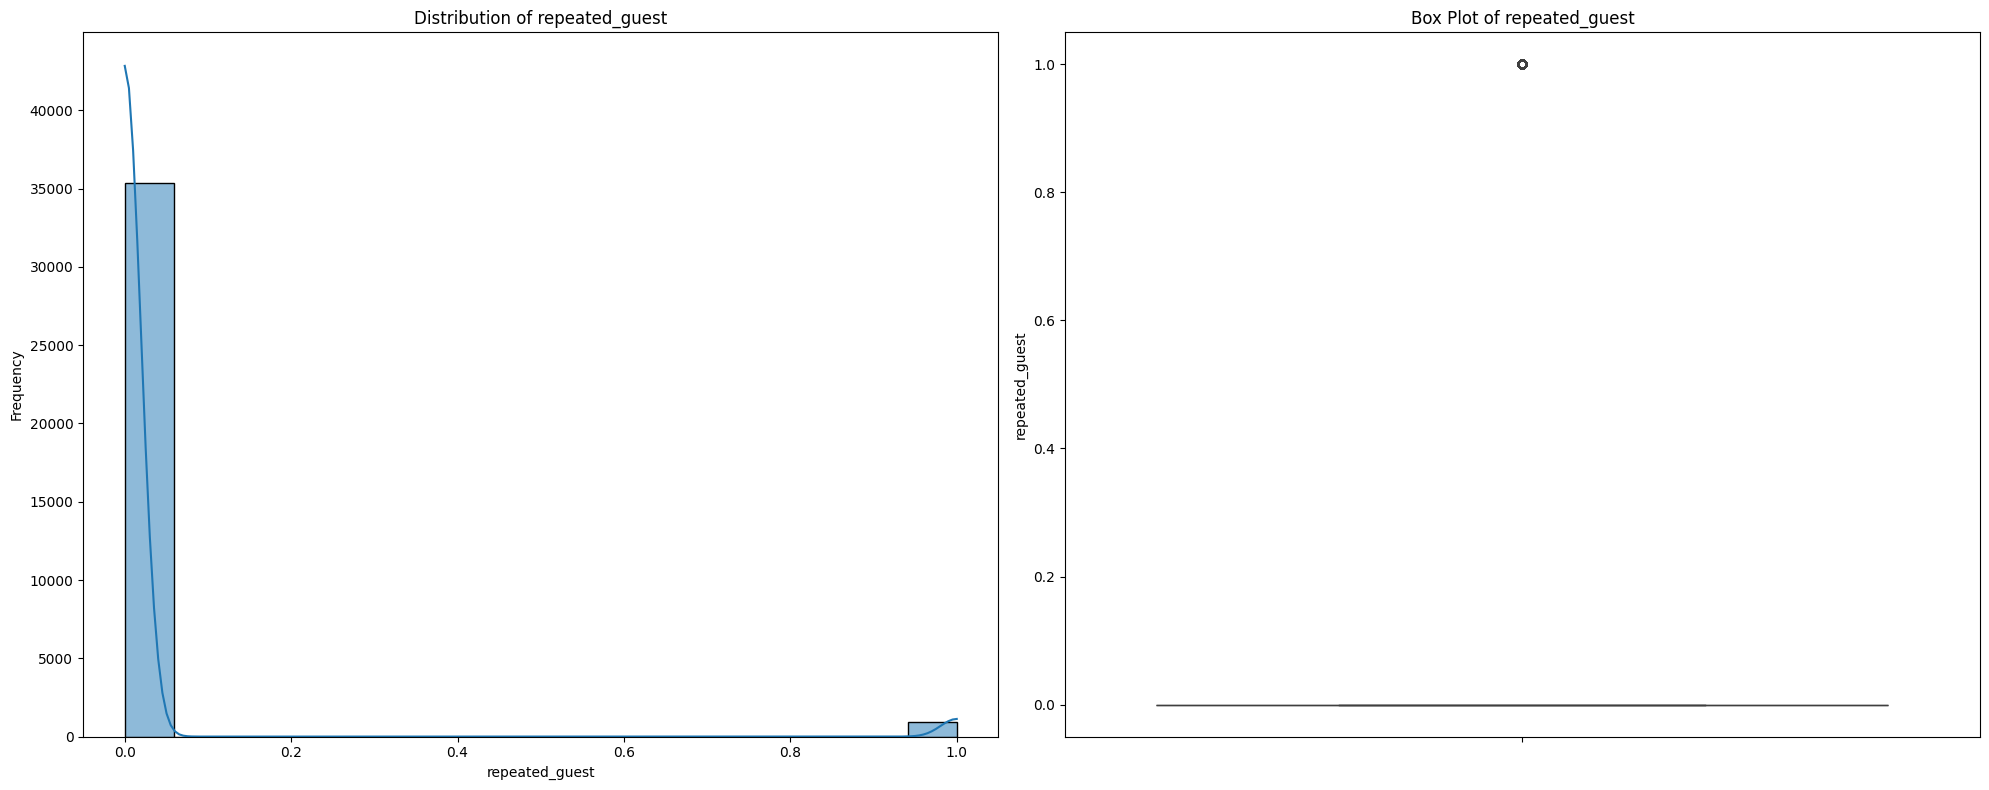

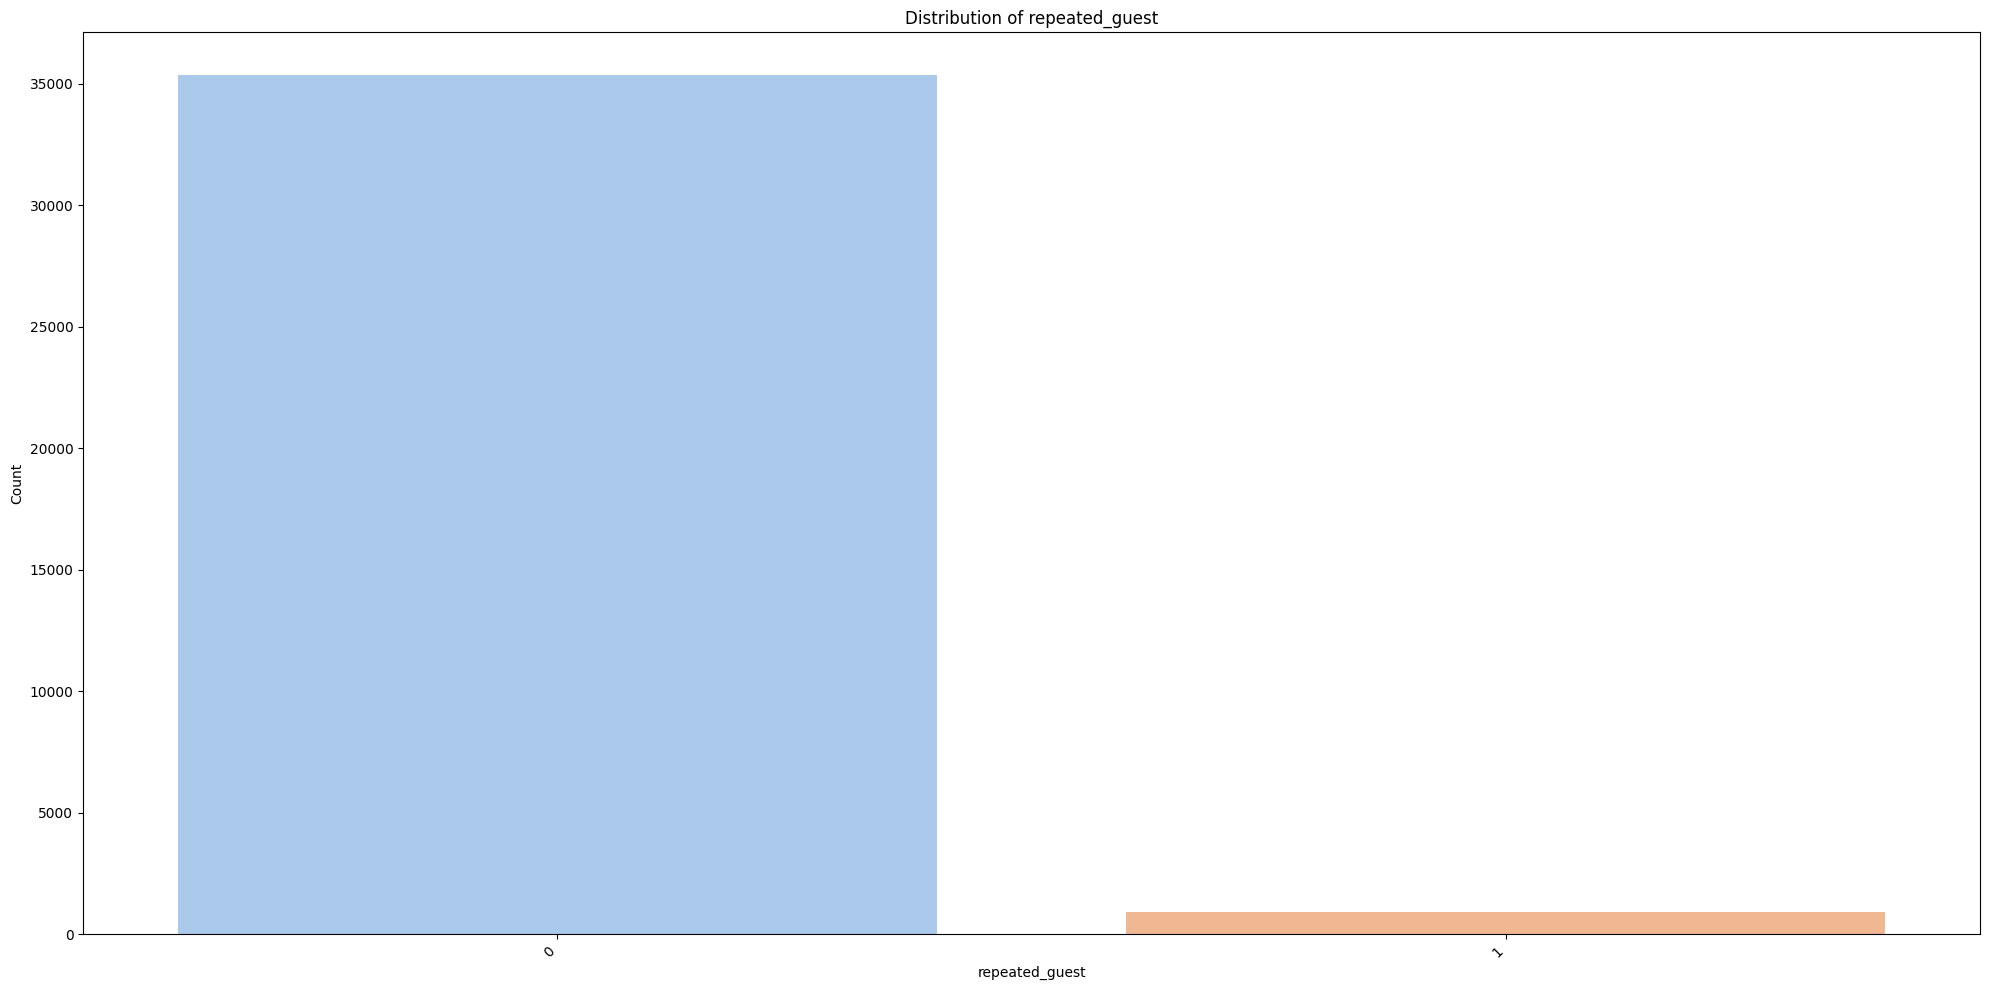


Descriptive statistics for no_of_previous_cancellations:
count    36275.000000
mean         0.023349
std          0.368331
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         13.000000
Name: no_of_previous_cancellations, dtype: float64


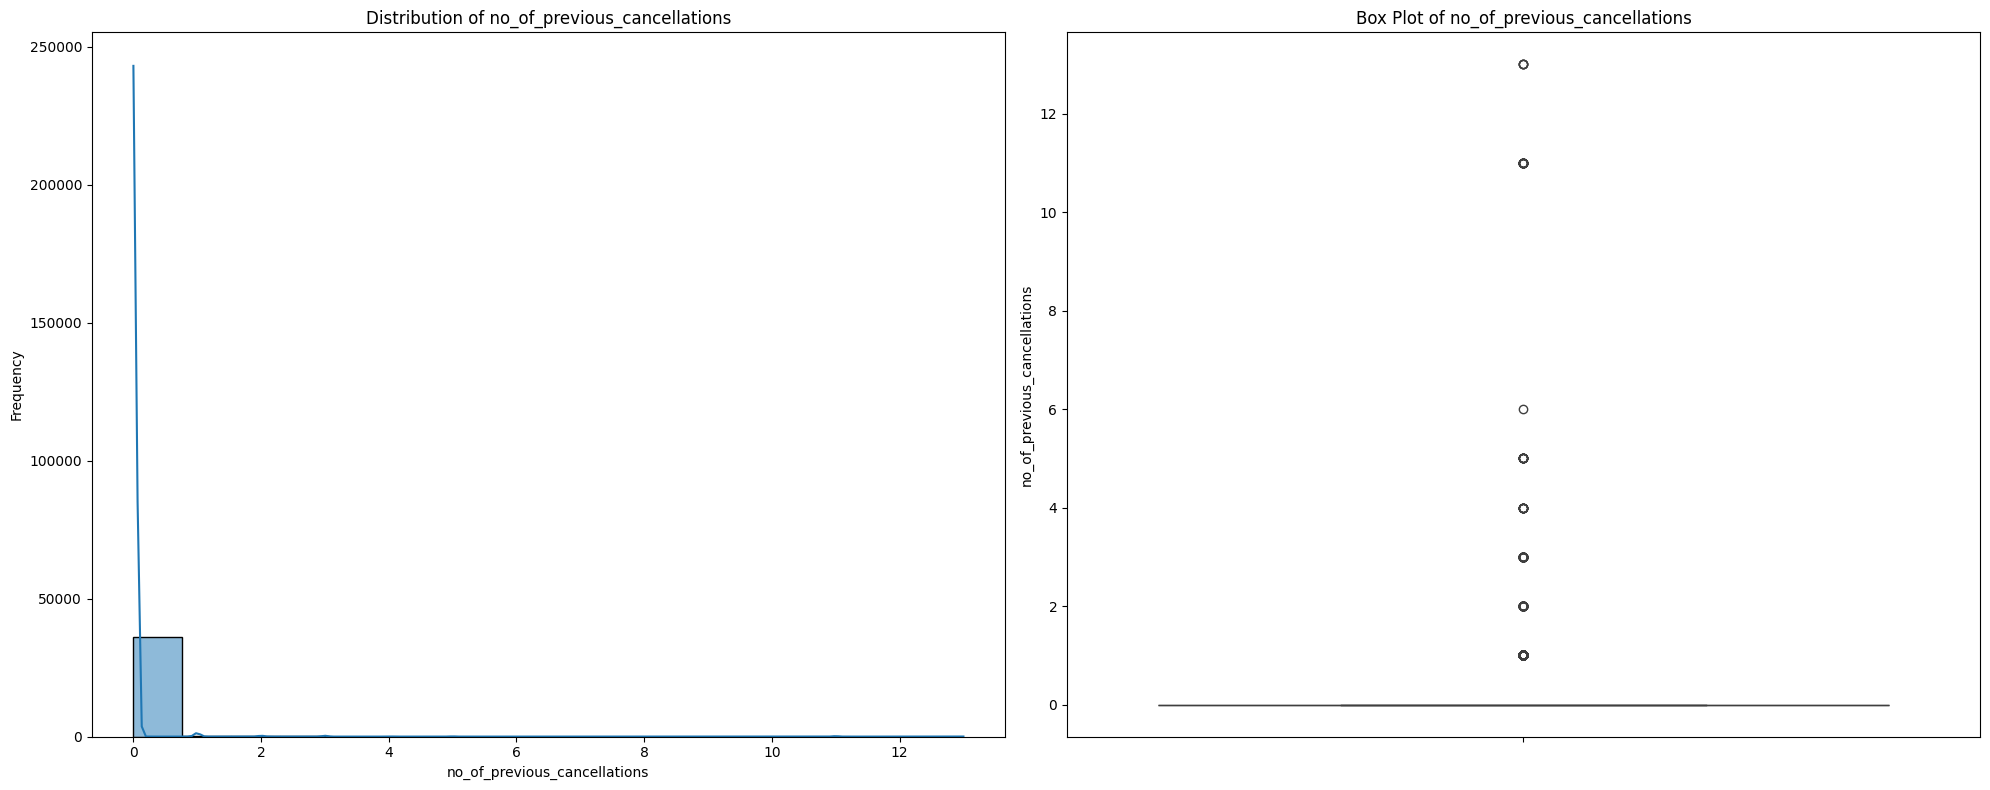

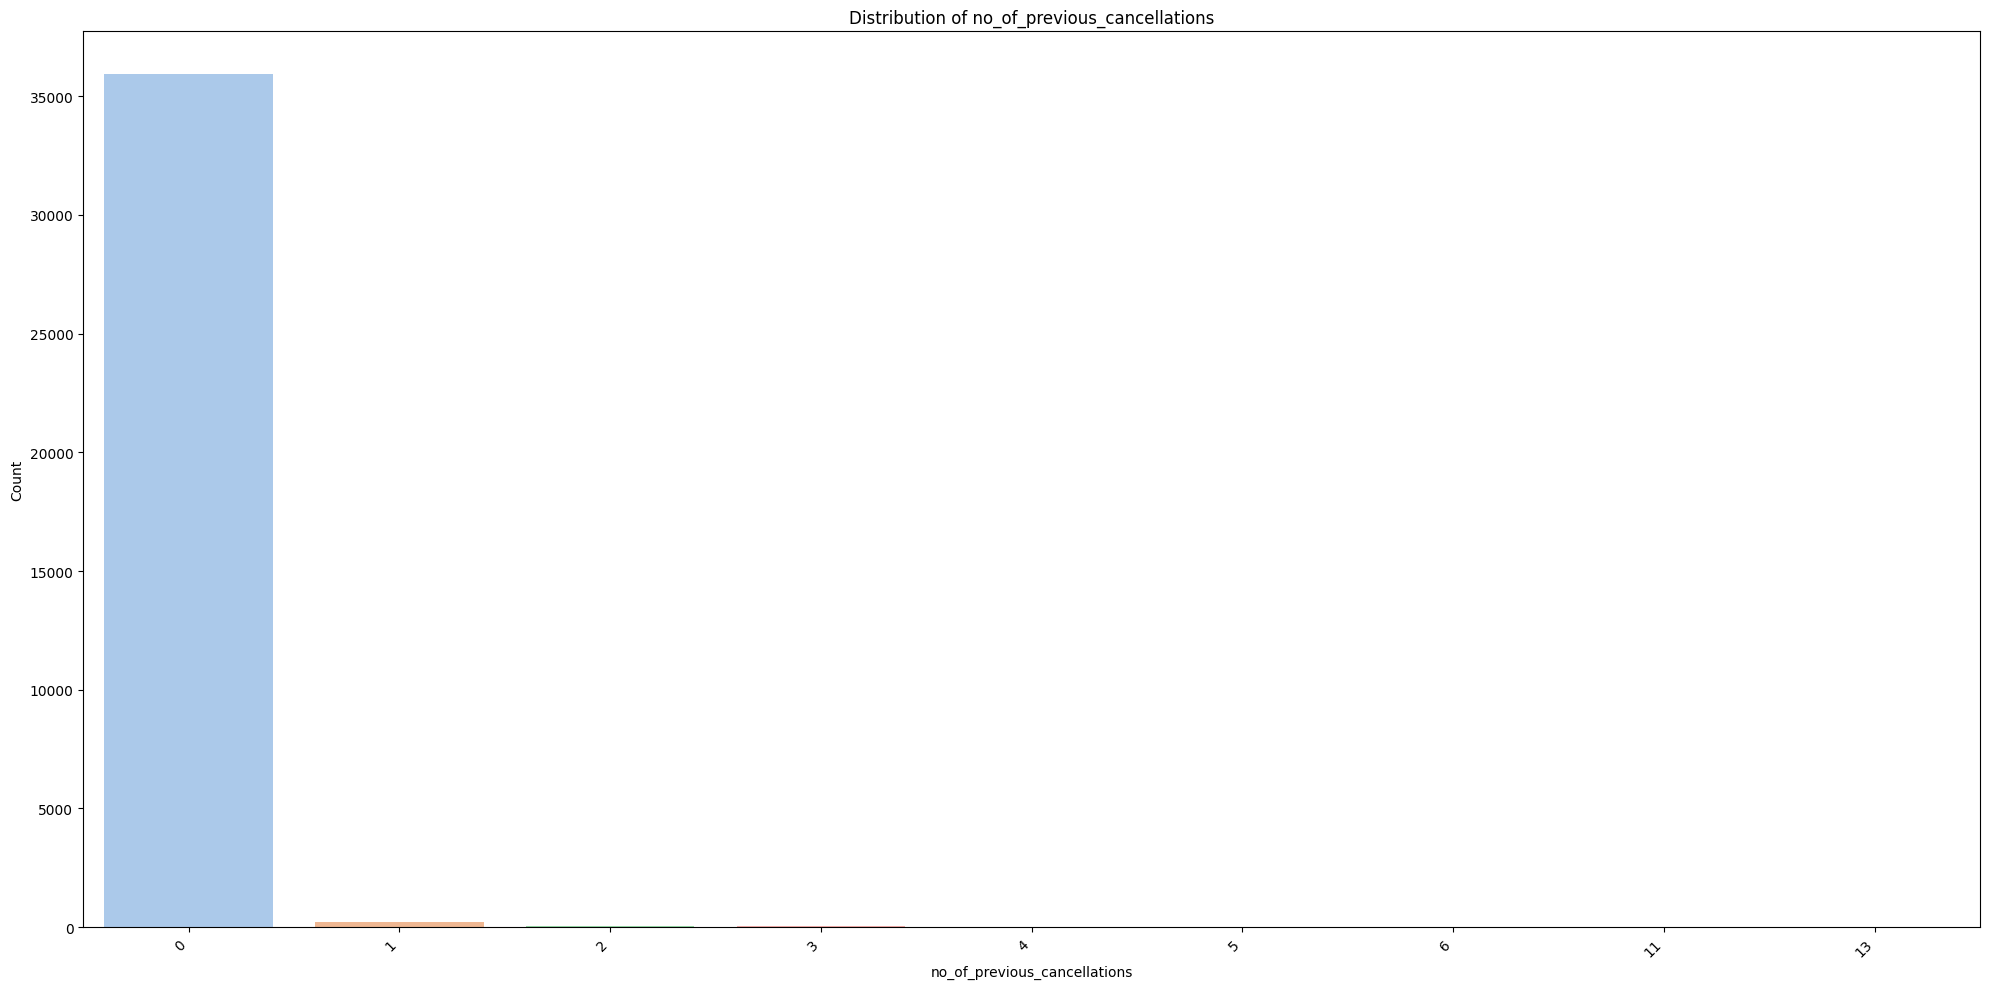


Descriptive statistics for no_of_previous_bookings_not_canceled:
count    36275.000000
mean         0.153411
std          1.754171
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         58.000000
Name: no_of_previous_bookings_not_canceled, dtype: float64


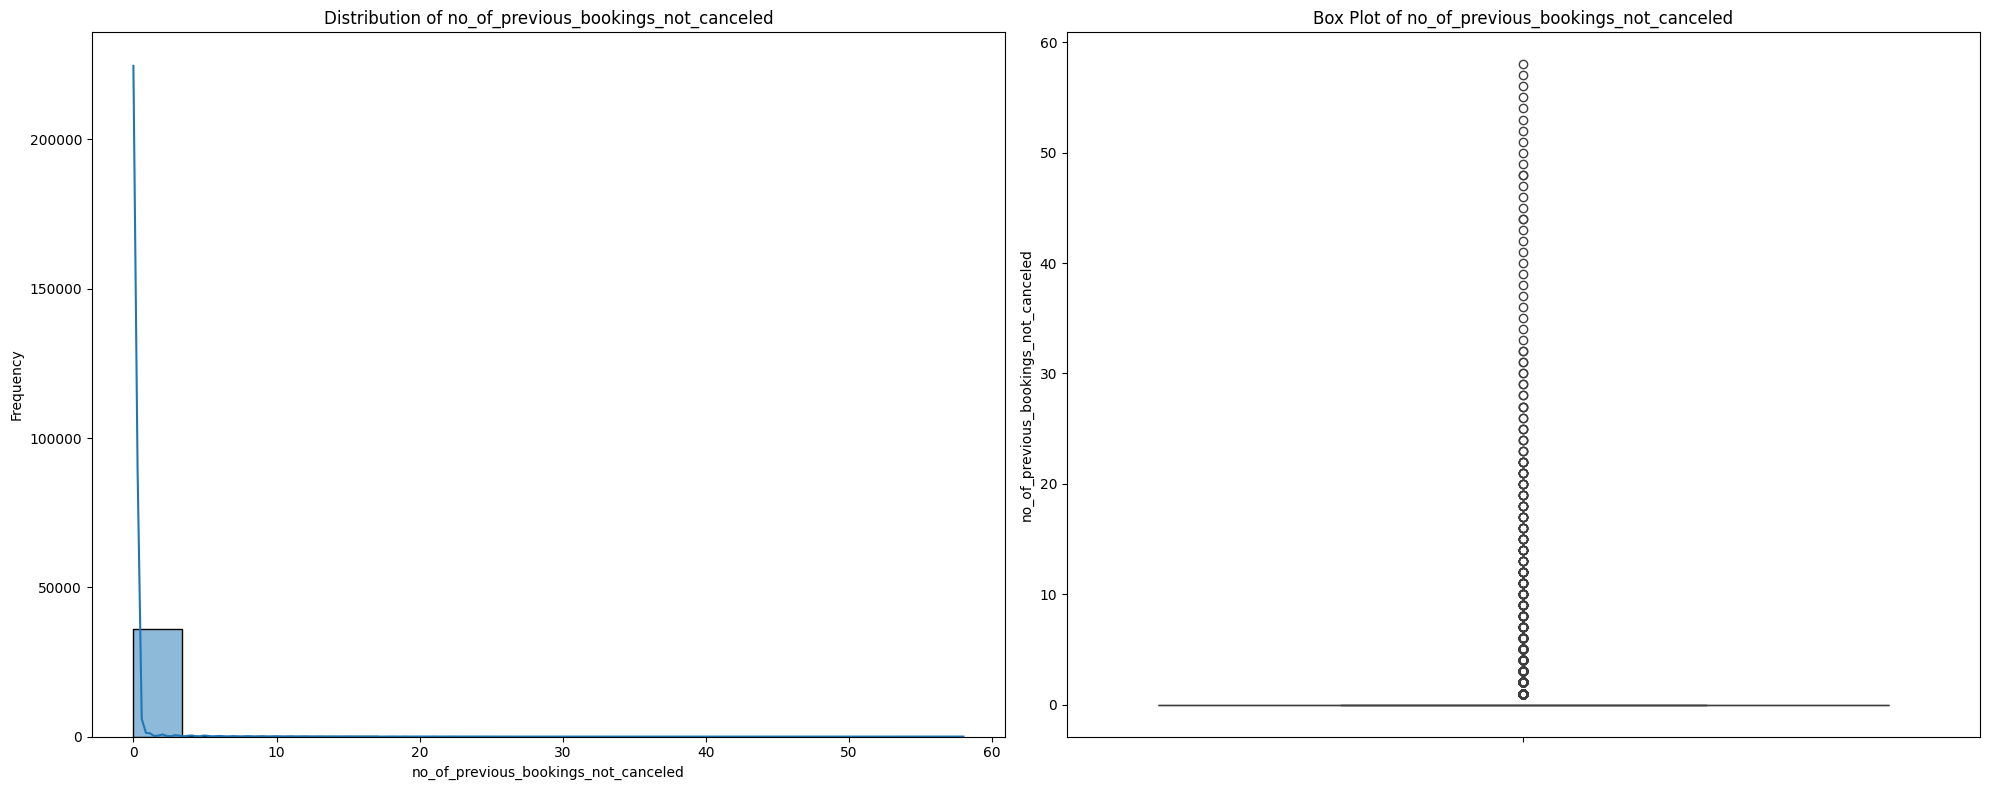

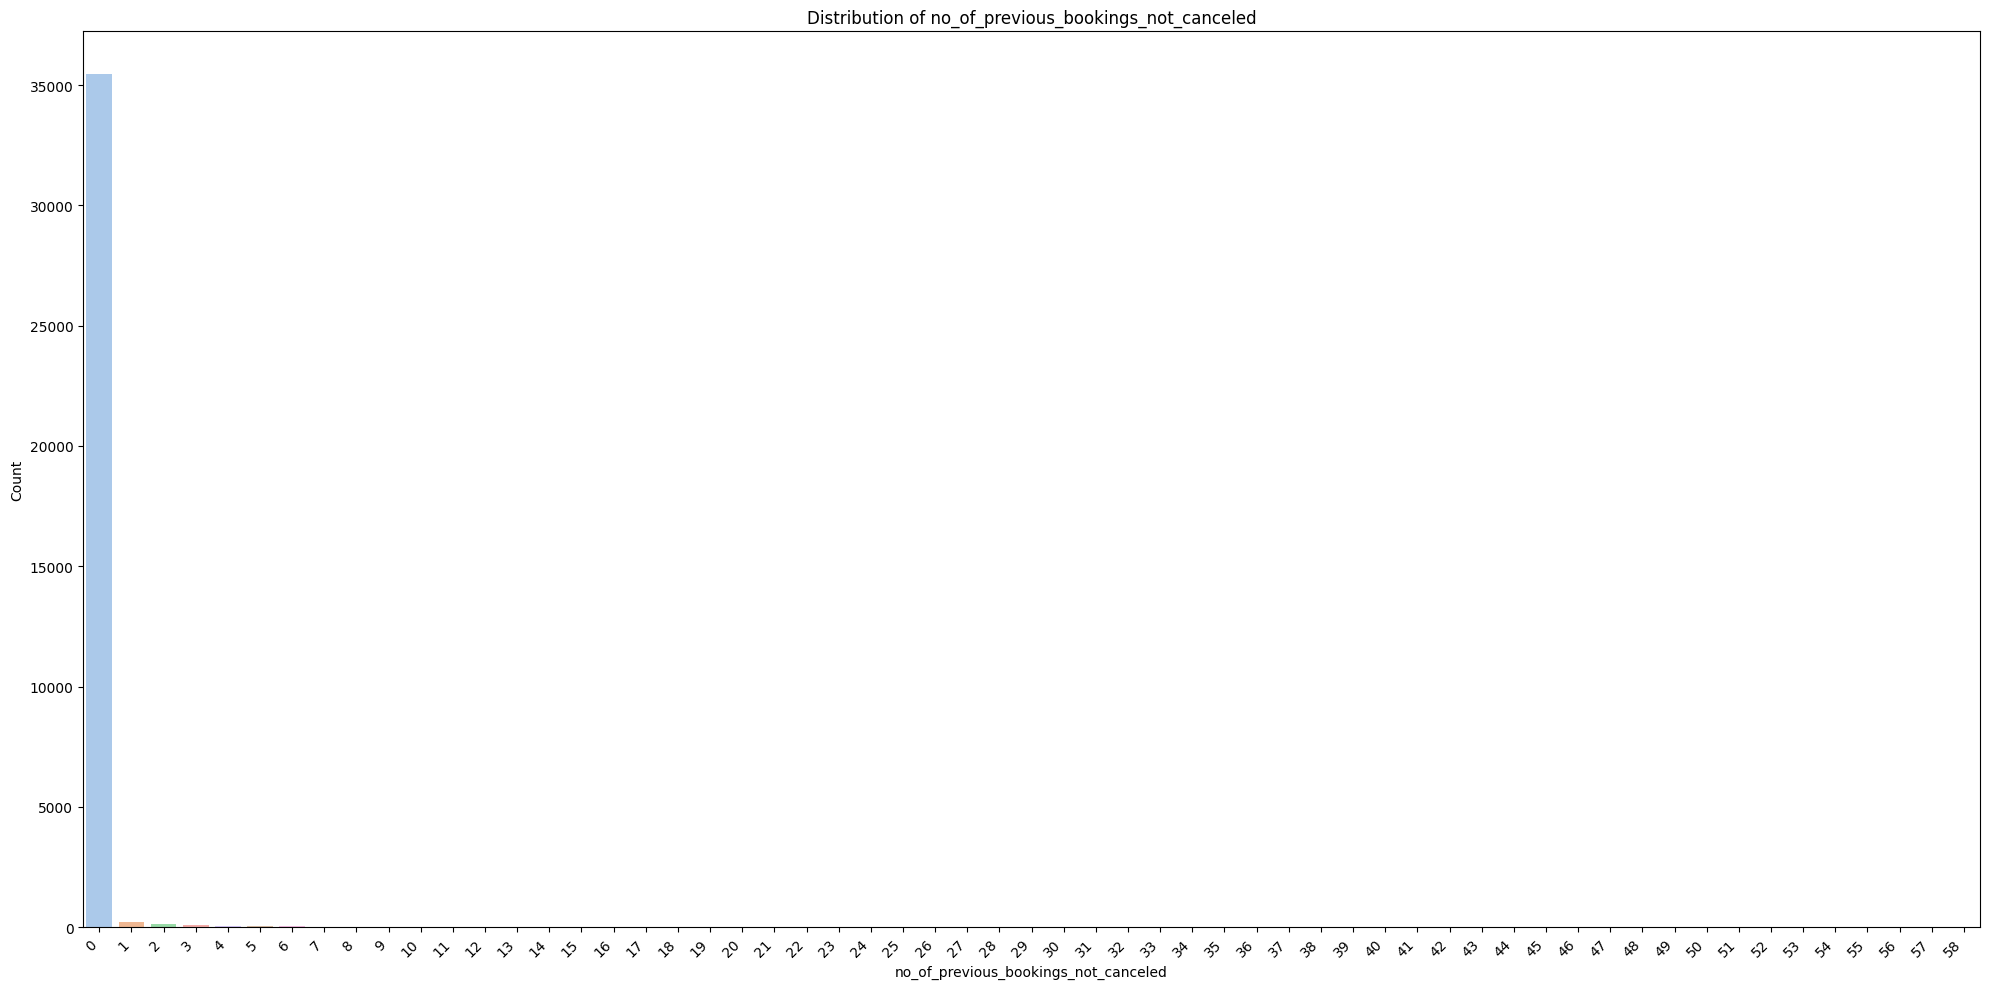


Descriptive statistics for avg_price_per_room:
count    36275.000000
mean       103.423539
std         35.089424
min          0.000000
25%         80.300000
50%         99.450000
75%        120.000000
max        540.000000
Name: avg_price_per_room, dtype: float64


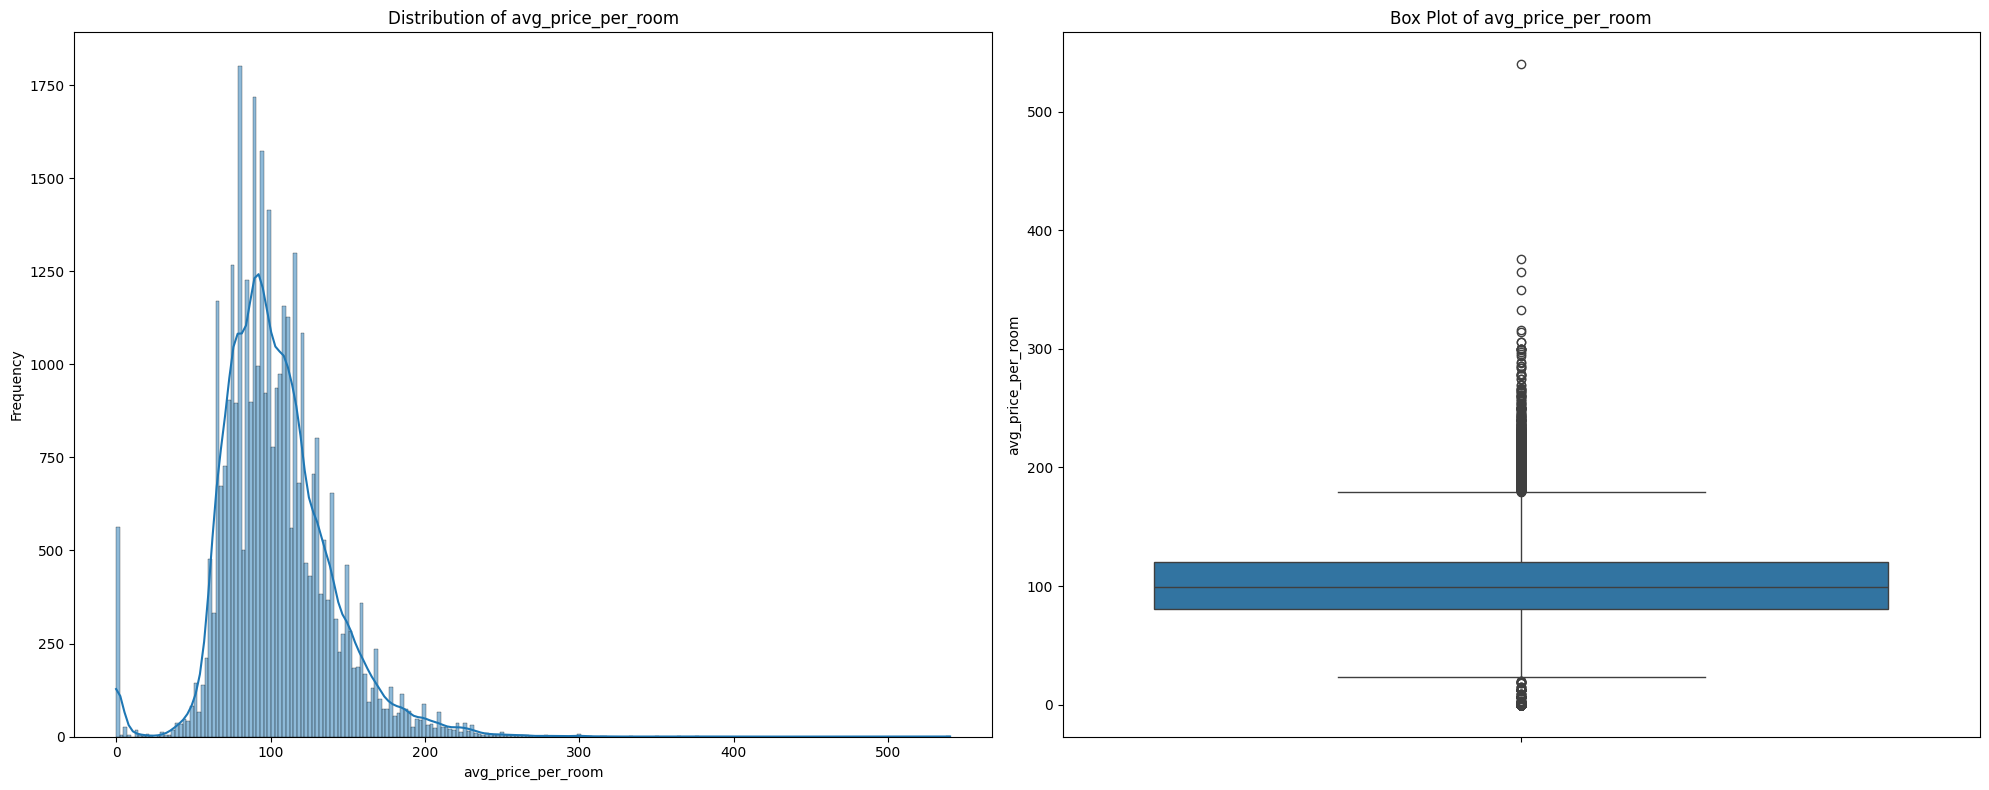

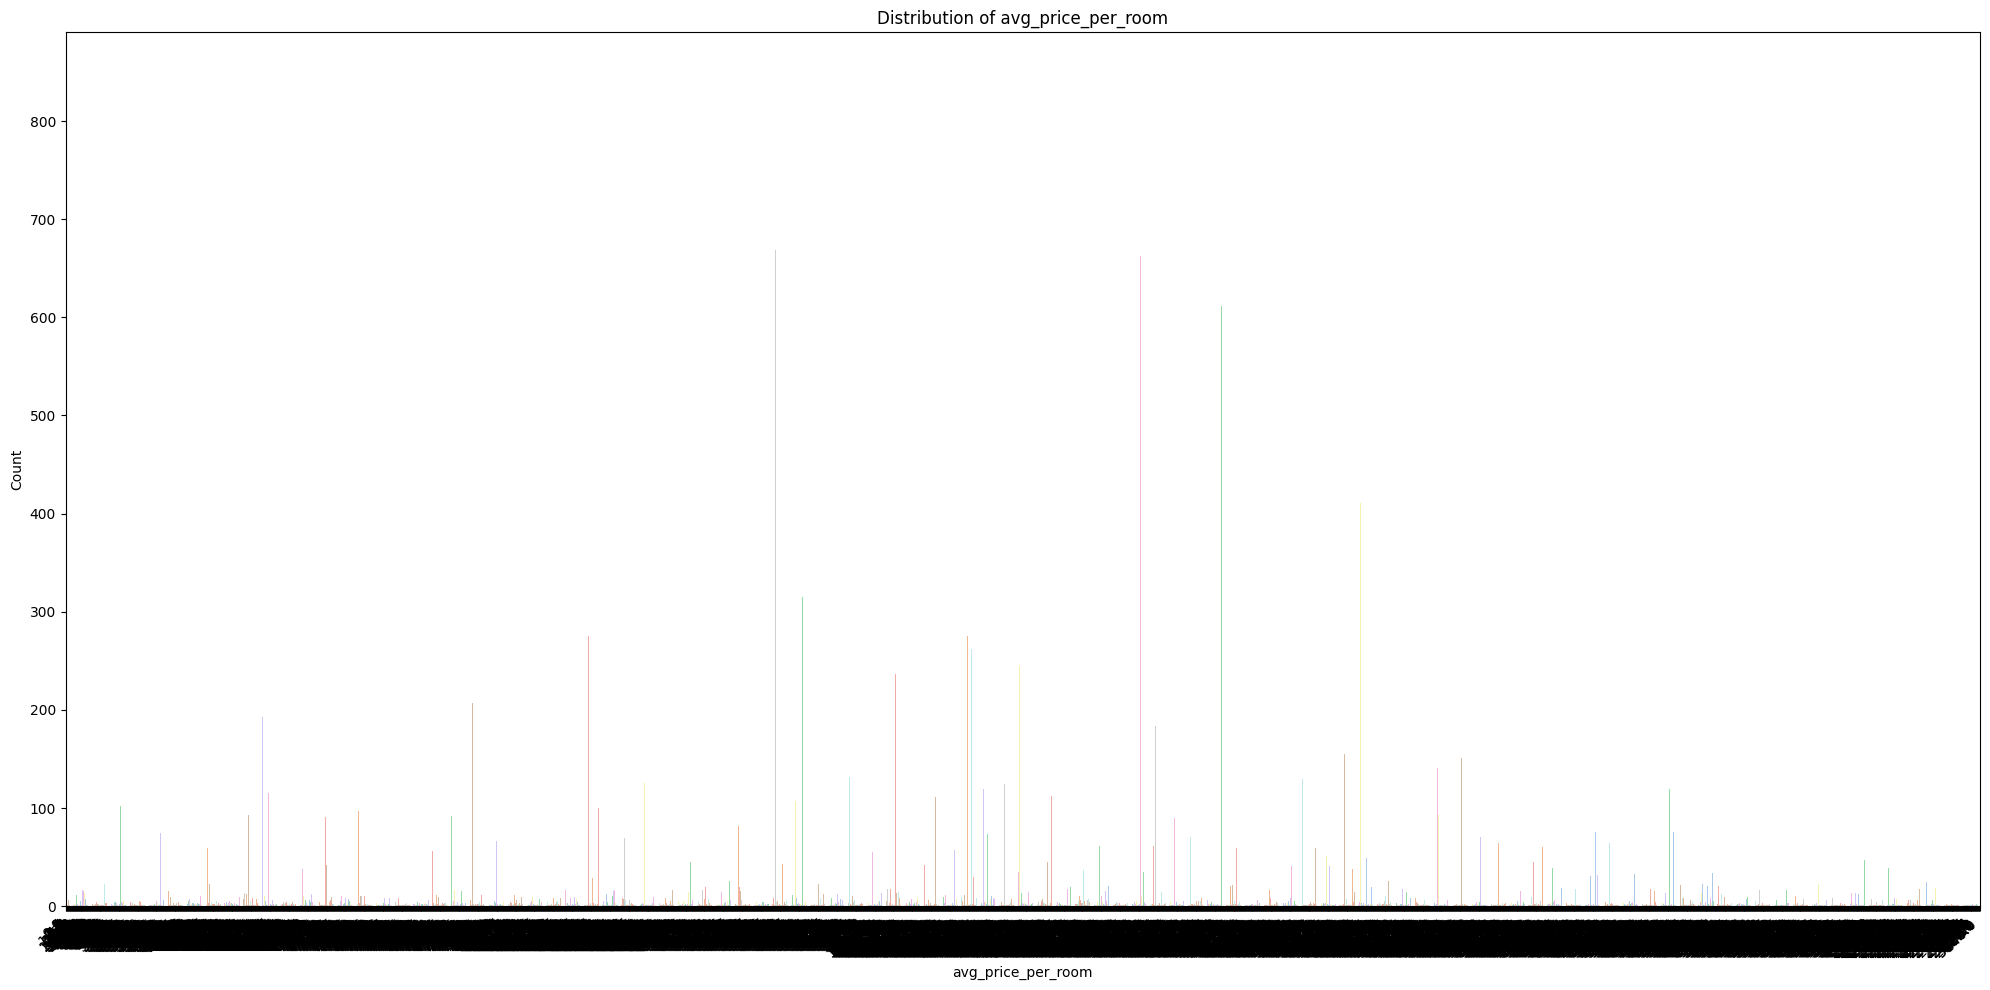


Descriptive statistics for no_of_special_requests:
count    36275.000000
mean         0.619655
std          0.786236
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: no_of_special_requests, dtype: float64


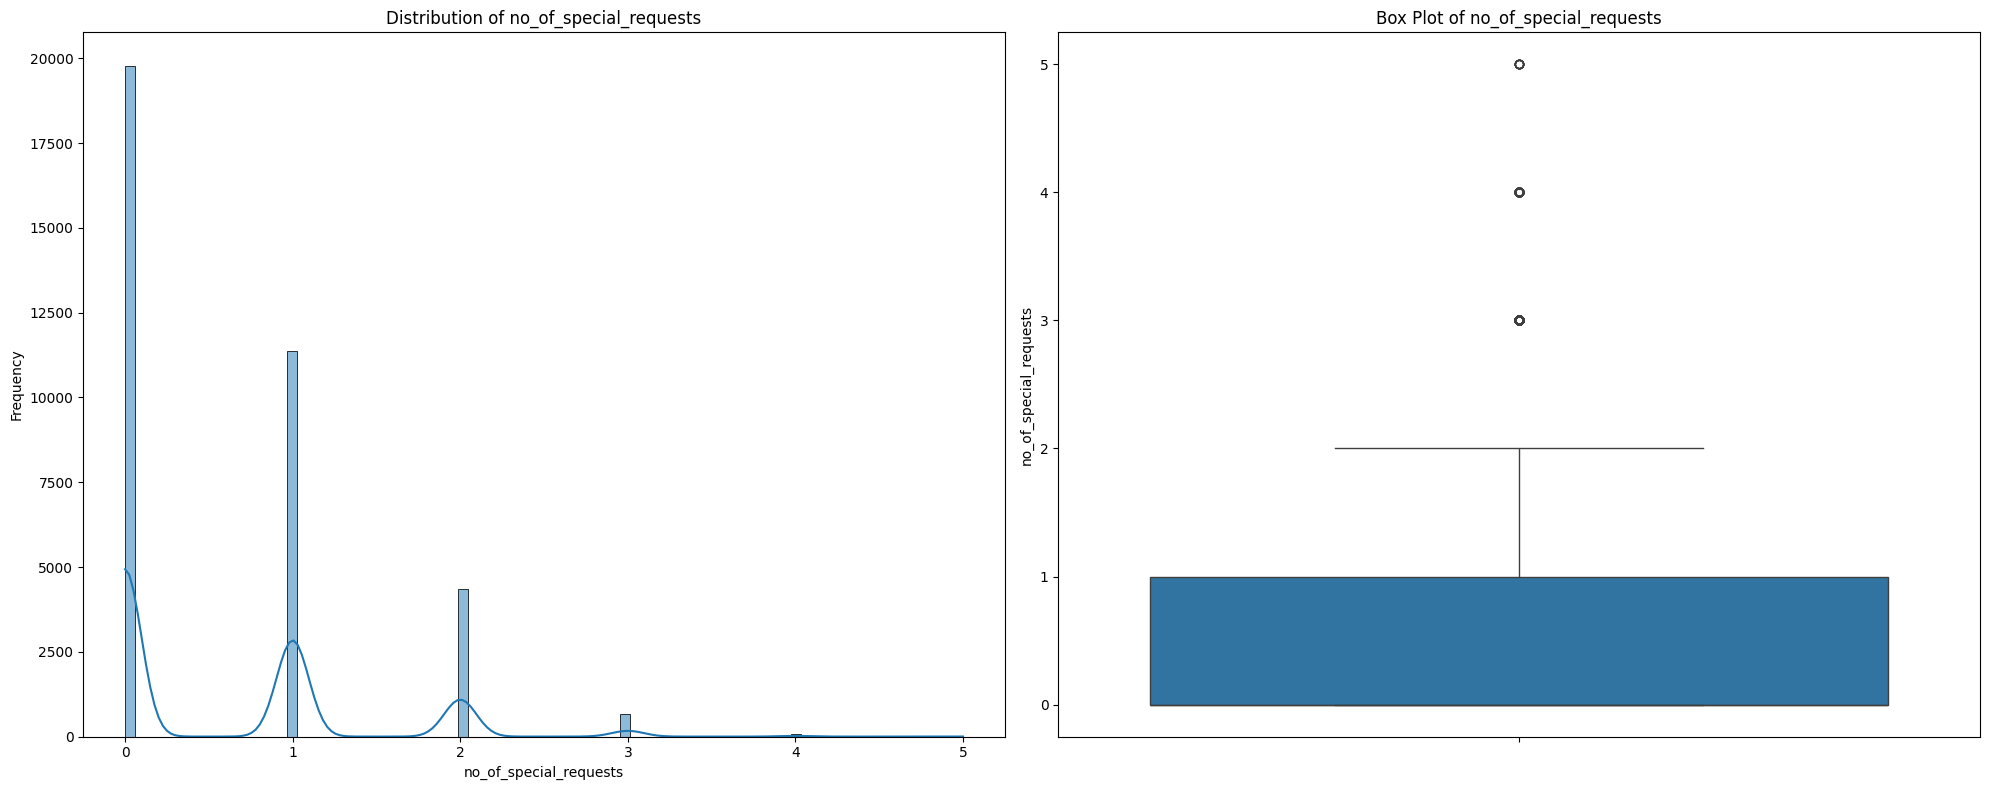

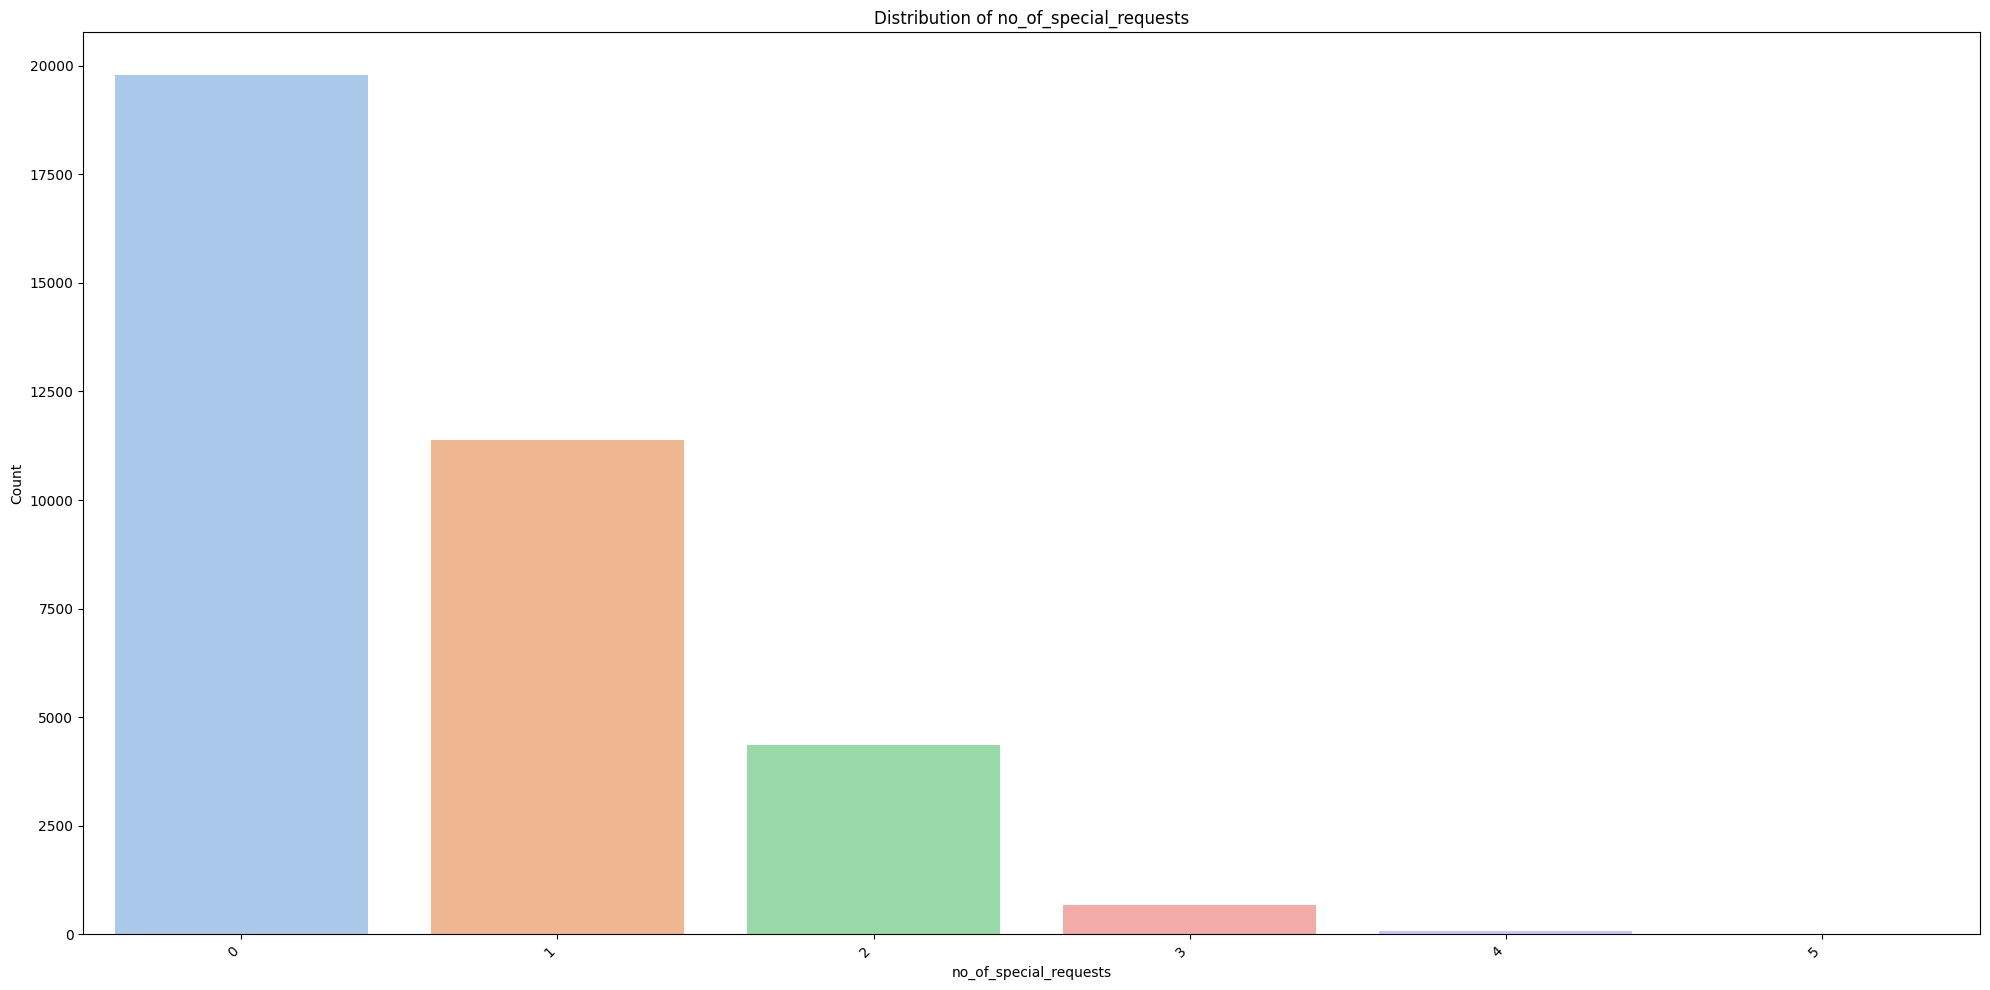

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Command to tell Python to actually display the graphs
%matplotlib inline

numerical_cols = ['no_of_adults',  'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                  'required_car_parking_space','lead_time','arrival_year','arrival_month','arrival_date',
                  'repeated_guest','no_of_previous_cancellations','no_of_previous_bookings_not_canceled','avg_price_per_room','no_of_special_requests']

def numerical_univariate_analysis(df, column):
    print(f"\nDescriptive statistics for {column}:")
    print(df[column].describe())

    plt.figure(figsize=(20, 8))

    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

     # Create a bar plot
    plt.figure(figsize=(20, 10))
    sns.countplot(data=df, x=column, hue=column, palette='pastel', legend=False)
    plt.title(f'Distribution of {column
                                 }')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for col in numerical_cols:
    numerical_univariate_analysis(df, col)


**Inference From Univariate Analysis For Numerical Columns**

### Inferences from Univariate Analysis for Numerical Columns

**no_of_adults:**
Most bookings are for 2 adults (median, 25th, and 75th percentile are all 2), indicating that couples or small groups are the primary customer segment for INN Hotels. Bookings for more than 2 adults are less frequent, with a maximum of 4 adults per booking.

**no_of_children:**
An overwhelming majority of bookings (75% of bookings have 0 children) do not include children, suggesting that the hotel's clientele is predominantly adults without accompanying children. While there are some bookings with children, they are a small percentage of the total.

**no_of_weekend_nights:**
Guests tend to book short stays over the weekend, with 75% of bookings including 2 or fewer weekend nights. A significant portion of bookings (25th percentile is 0) involve no weekend nights, indicating a mix of weekday business and leisure travel.

**no_of_week_nights:**
Most stays fall between 1 and 3 weeknights (25th to 75th percentile), pointing to short to medium-length weekday trips. The maximum of 17 weeknights indicates some extended stays, but these are outliers.

**required_car_parking_space:**
Only a very small percentage of guests (around 3%) require a car parking space. This suggests that the majority of guests might be using public transport, ride-sharing, or the hotel's location makes a personal vehicle unnecessary for their stay.

**lead_time:**
Bookings are often made relatively close to the arrival date, with a median lead time of 57 days and 75% of bookings within 126 days. However, there's a wide range, from same-day bookings (0 days) to reservations made over a year in advance (up to 443 days).

**arrival_year:**
All recorded bookings are concentrated within 2017 and 2018, providing a specific two-year window for this dataset. This indicates the scope of the data for analyzing booking trends.

**arrival_month:**
Bookings are distributed throughout the year, with a higher frequency observed in the later months, as indicated by the median arrival month of 8 (August) and the 75th percentile being 10 (October). This suggests potential seasonal peaks during autumn.

**arrival_date:**
Arrival dates are fairly spread out across the month, with the median date being the 16th. There isn't a strong pattern of arrivals concentrated on the beginning or end of the month, indicating a continuous flow of guests.

**repeated_guest:**
The proportion of repeated guests is very low (around 2.5%), highlighting a potential area for INN Hotels to focus on customer loyalty and retention strategies. Most guests are new or infrequent visitors.

**no_of_previous_cancellations:**
Almost all guests (75th percentile is 0) have no prior cancellations, which is a positive sign for booking reliability. The few instances of previous cancellations are outliers and could be associated with specific customer segments.

**no_of_previous_bookings_not_canceled:**
Similar to previous cancellations, the vast majority of guests (75th percentile is 0) have no prior non-canceled bookings, reinforcing the observation of a low repeated guest rate. This further suggests that most bookings come from new customers.

**avg_price_per_room:**
The average price per room is dynamic, with a median of 99.45 euros, ranging from very low prices (0 euros, possibly promotional or special cases) to high values (up to 540 euros). This indicates flexible pricing strategies and diverse customer segments.

**no_of_special_requests:**
Most bookings involve few or no special requests (median is 0, 75th percentile is 1), simplifying operations for the majority of reservations. Some guests do have specific needs, but they are generally limited to one request.

**Univariate Analysis of Categorical Columns**

 1.Define a list of these columns.

2.Iterate through this list, displaying value counts

3.Generate a bar plot for each column to visualize its frequency distribution.





--- Analyzing Categorical Column: type_of_meal_plan ---
Value Counts for type_of_meal_plan:
type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64


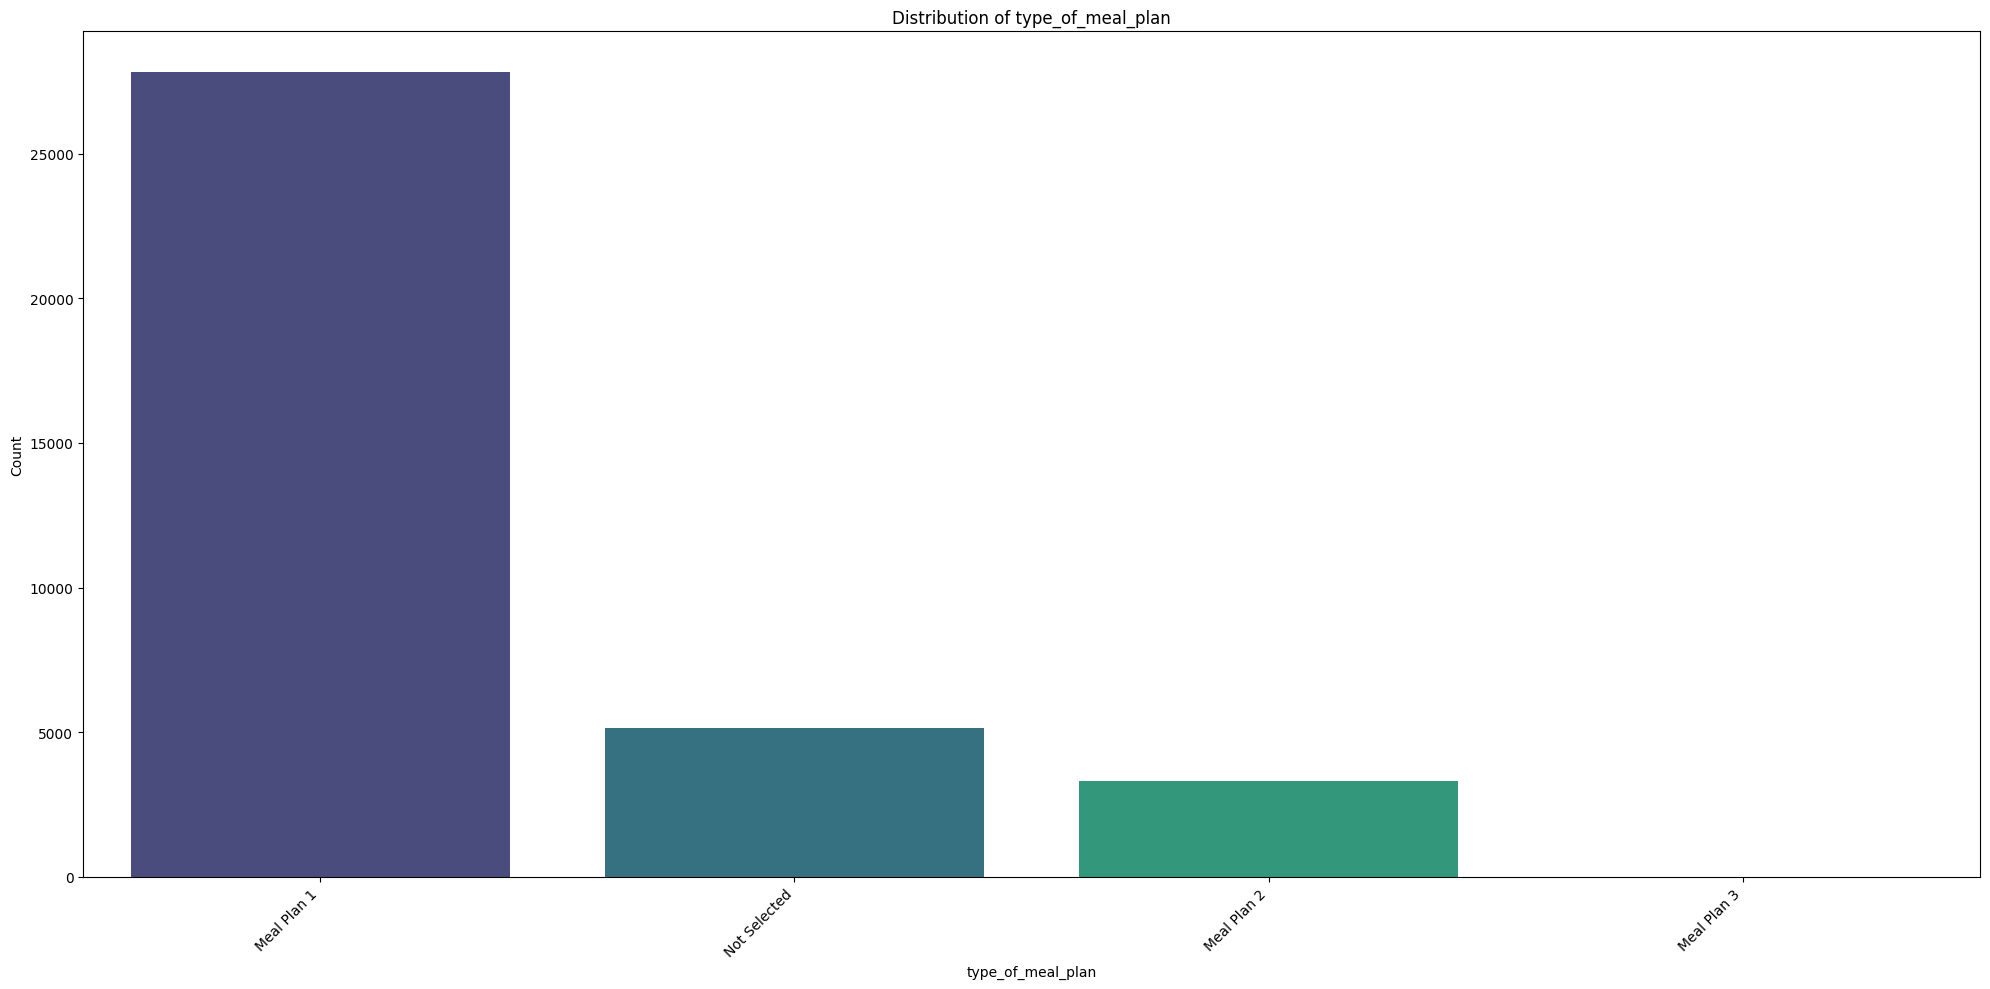


--- Analyzing Categorical Column: room_type_reserved ---
Value Counts for room_type_reserved:
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64


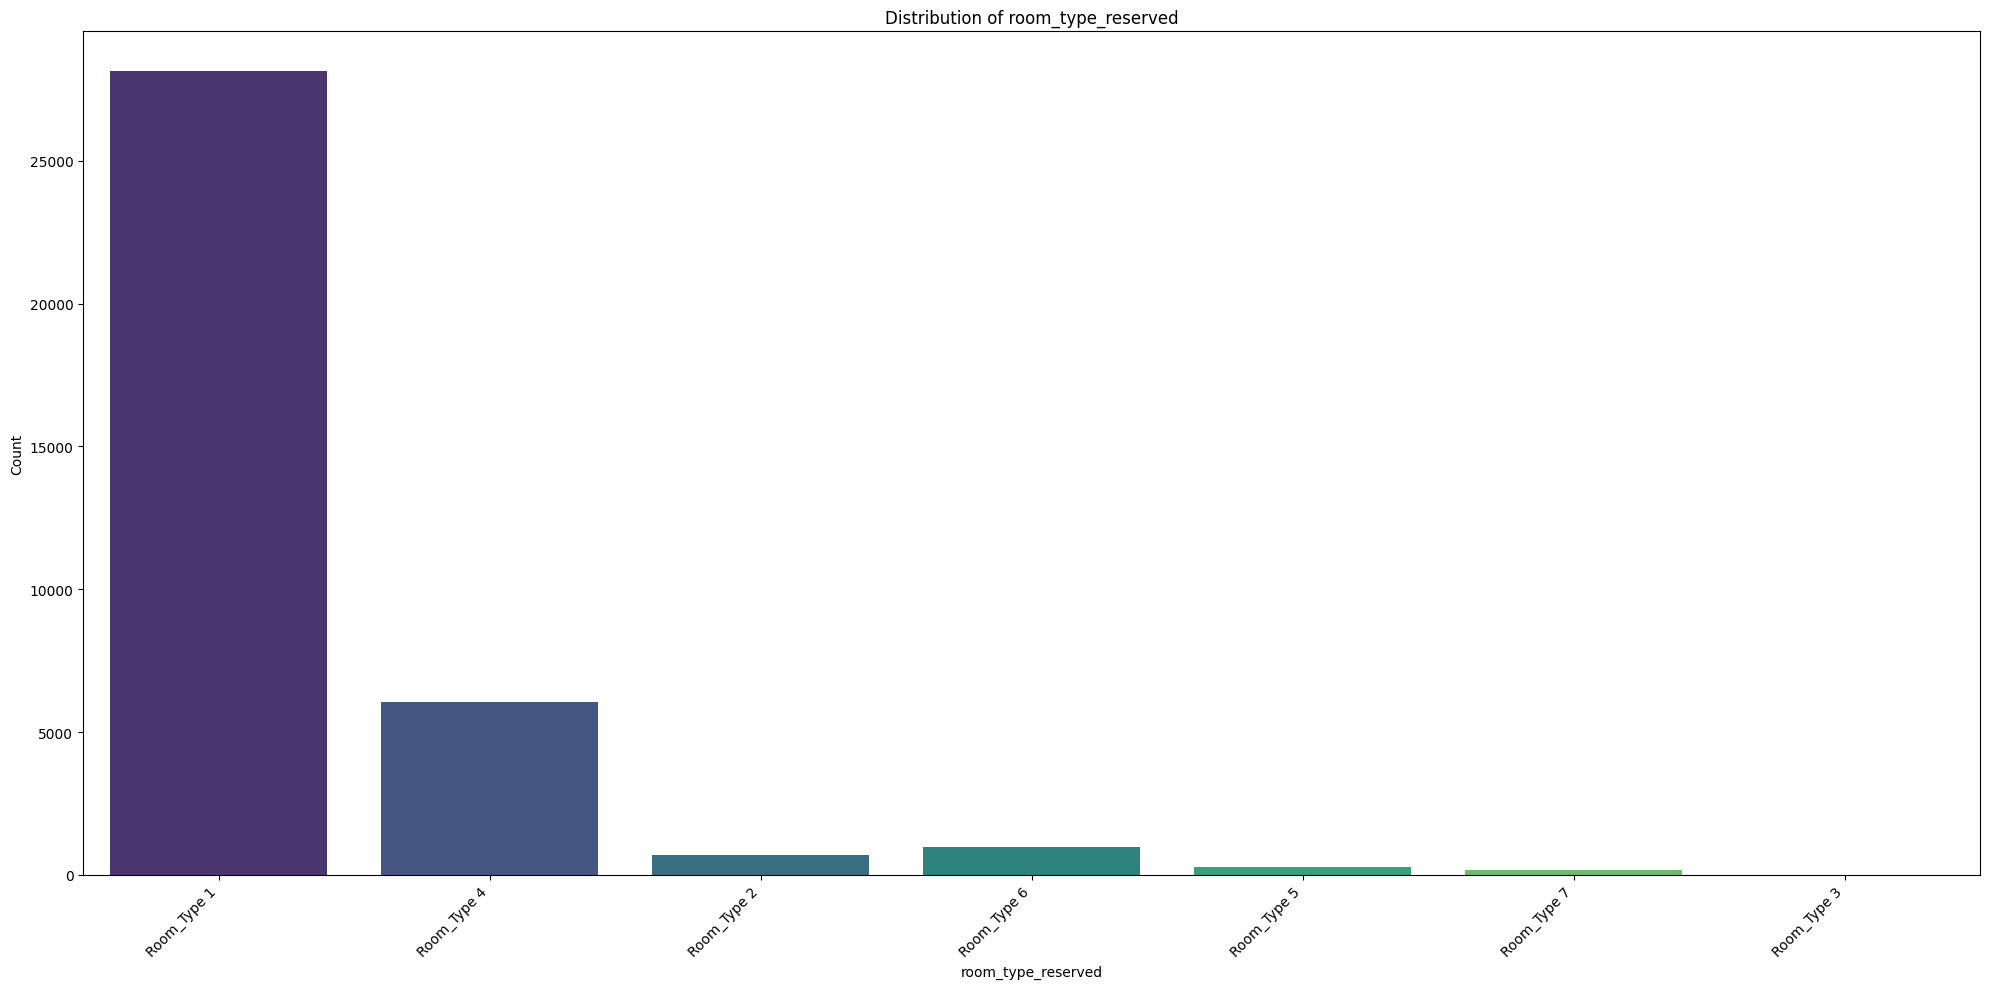


--- Analyzing Categorical Column: market_segment_type ---
Value Counts for market_segment_type:
market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64


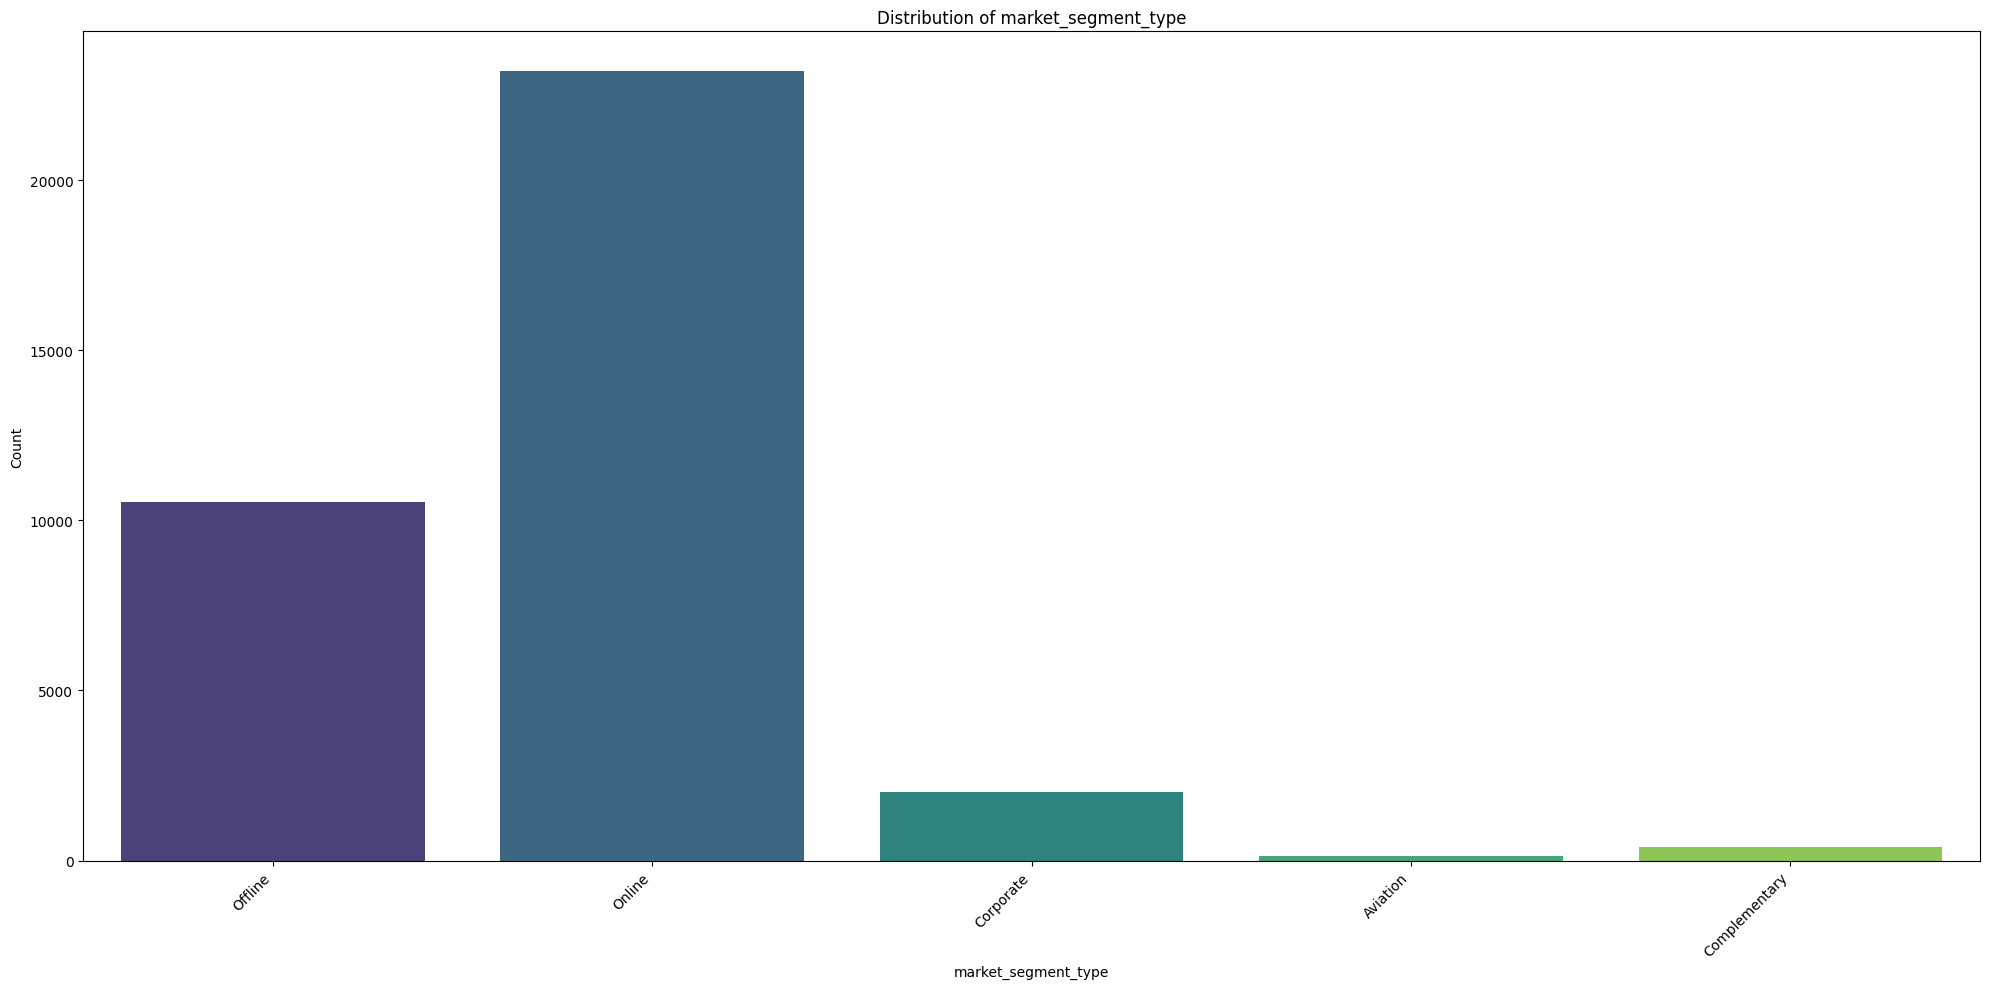


--- Analyzing Categorical Column: booking_status ---
Value Counts for booking_status:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


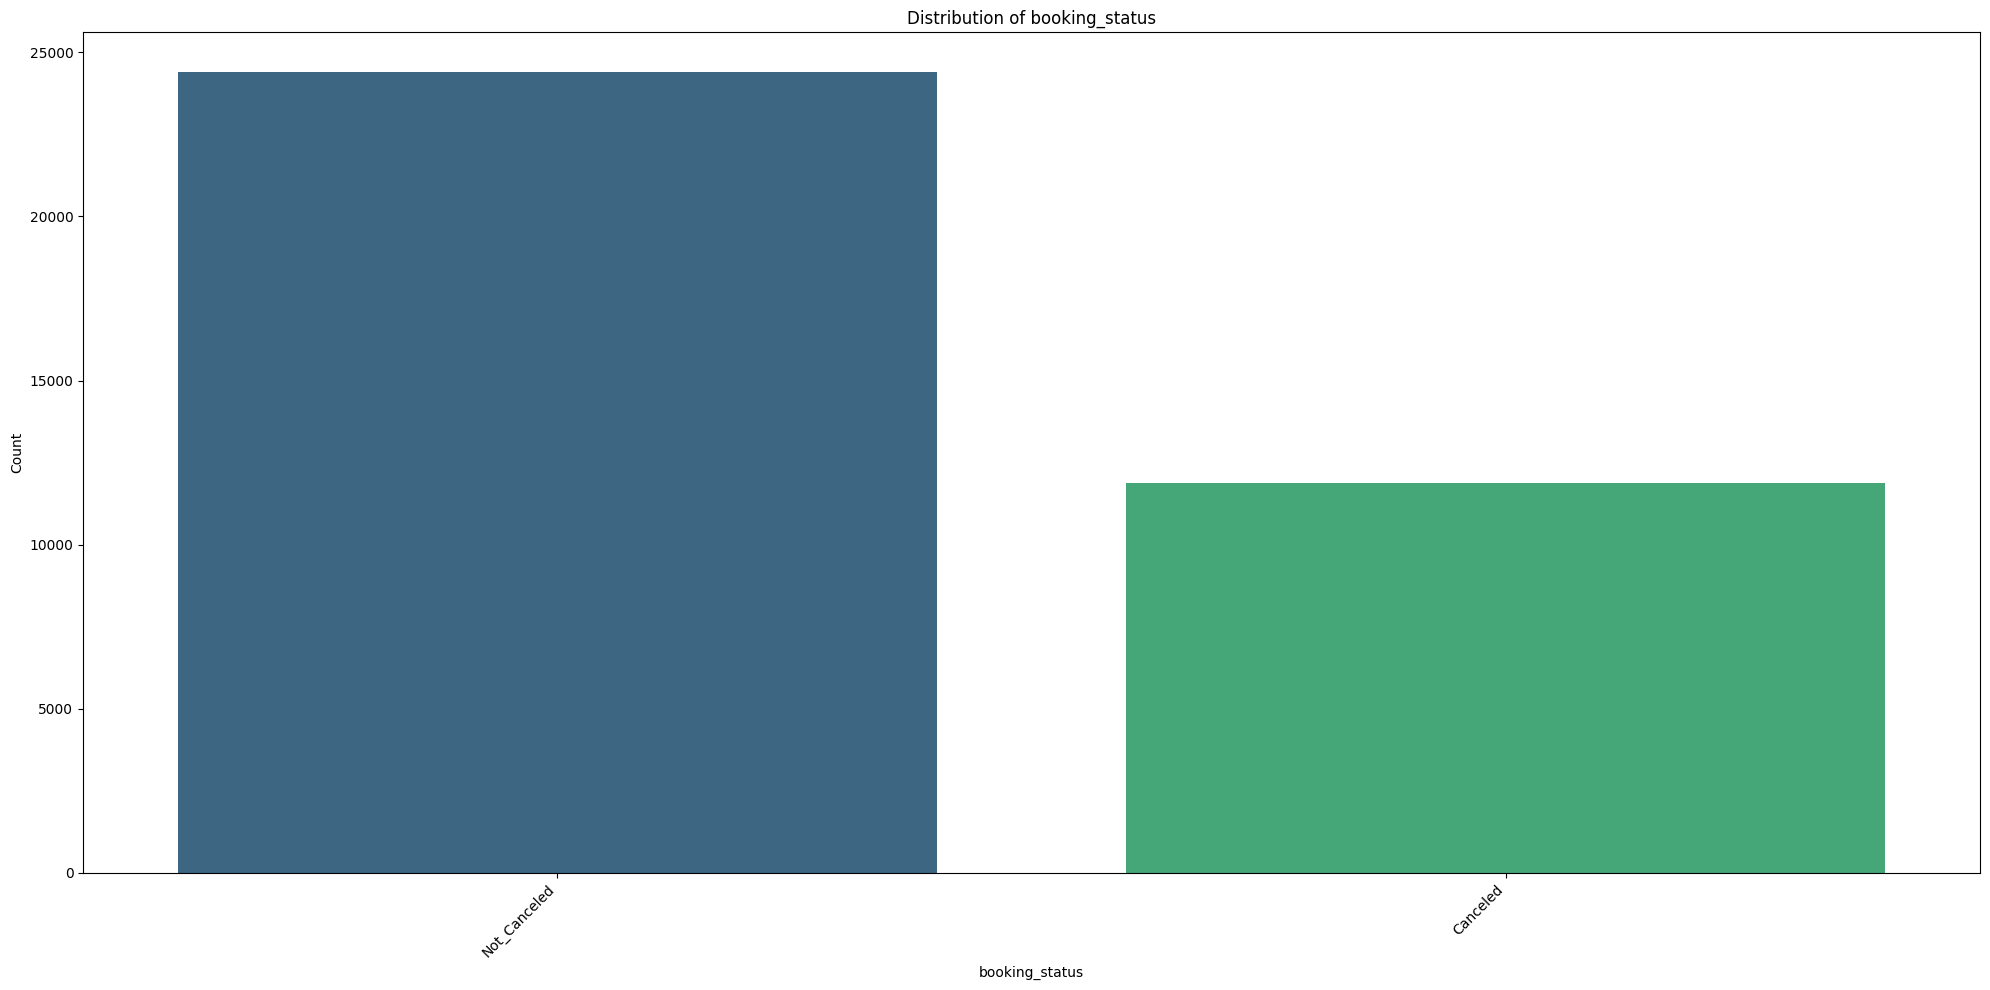

In [62]:
categorical_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']
for col in categorical_cols:
    print(f"\n--- Analyzing Categorical Column: {col} ---")

    # Display value counts
    print(f"Value Counts for {col}:")
    print(df[col].value_counts())

    # Create a bar plot
    plt.figure(figsize=(20, 10))
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Inference From Univariate Analysis For Categorical Columns**

### Inferences from Univariate Analysis For Categorical Columns

**type_of_meal_plan:**
The vast majority of guests opt for 'Meal Plan 1' (Breakfast), indicating a strong preference for a basic meal offering. 'Not Selected' is the second most common, suggesting some guests prefer flexibility or external dining, while 'Meal Plan 3' (Full Board) is rarely chosen.

**room_type_reserved:**
'Room_Type 1' is overwhelmingly the most frequently booked room type, followed by 'Room_Type 4'. This indicates that these two room types are either the most available, most affordable, or most desired by guests, potentially warranting closer examination of their features and pricing strategies.

**market_segment_type:**
Online channels are the dominant source of bookings, highlighting the critical importance of the hotel's digital presence and online travel agency partnerships. Offline and Corporate segments also contribute significantly, while Aviation and Complementary bookings are minimal niche markets.

**booking_status:**
The data shows that a larger proportion of bookings are 'Not_Canceled' compared to 'Canceled'. While this indicates a generally stable booking trend, the percentage of 'Canceled' bookings is still significant enough to warrant further investigation into the reasons behind these cancellations to mitigate potential revenue loss.

**Bivariate Analysis**

**Bivariate Analysis - Correlation Analysis for Numerical Columns**

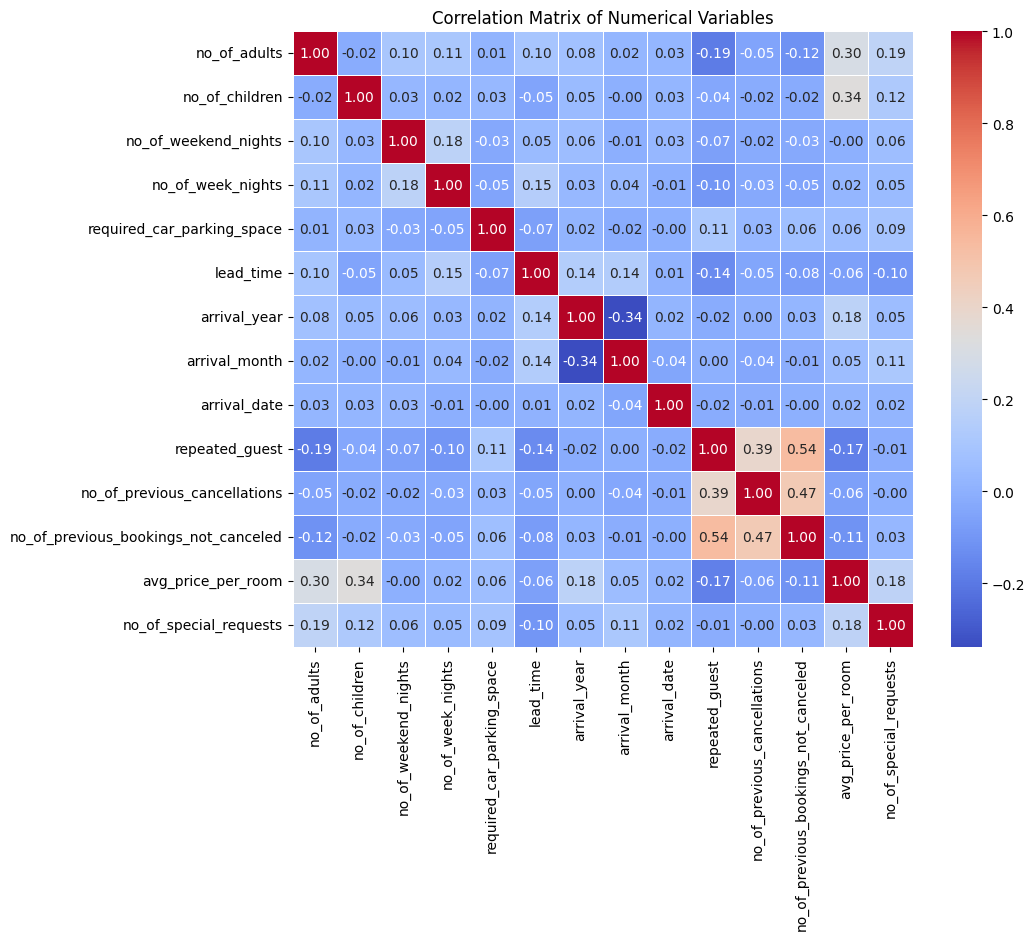

In [63]:
numerical_cols_for_corr = ['no_of_adults',  'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                  'required_car_parking_space','lead_time','arrival_year','arrival_month','arrival_date',
                  'repeated_guest','no_of_previous_cancellations','no_of_previous_bookings_not_canceled','avg_price_per_room','no_of_special_requests']


# Calculate the correlation matrix
correlation_matrix = df[numerical_cols_for_corr].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [64]:
correlation_matrix


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
no_of_adults,1.000000,-0.019787,0.103316,0.105622,0.011429,0.097287,0.076719,0.021841,0.026338,-0.192277,-0.047426,-0.119166,0.296886,0.189401
no_of_children,-0.019787,1.000000,0.029478,0.024398,0.034244,-0.047091,0.045983,-0.003076,0.025482,-0.036348,-0.016390,-0.021189,0.337728,0.124486
no_of_weekend_nights,0.103316,0.029478,1.000000,0.179577,-0.031111,0.046595,0.055357,-0.009894,0.027304,-0.067107,-0.020690,-0.026312,-0.004525,0.060593
no_of_week_nights,0.105622,0.024398,0.179577,1.000000,-0.048784,0.149650,0.032672,0.037376,-0.009305,-0.099764,-0.030080,-0.049344,0.022753,0.045994
required_car_parking_space,0.011429,0.034244,-0.031111,-0.048784,1.000000,-0.066445,0.015684,-0.015505,-0.000037,0.110909,0.027106,0.063810,0.061304,0.087922
lead_time,0.097287,-0.047091,0.046595,0.149650,-0.066445,1.000000,0.143439,0.136814,0.006479,-0.135984,-0.045723,-0.078137,-0.062596,-0.101645
arrival_year,0.076719,0.045983,0.055357,0.032672,0.015684,0.143439,1.000000,-0.339689,0.018849,-0.018175,0.003919,0.026422,0.178605,0.053205
arrival_month,0.021841,-0.003076,-0.009894,0.037376,-0.015505,0.136814,-0.339689,1.000000,-0.042780,0.000341,-0.038615,-0.010718,0.054423,0.110552
arrival_date,0.026338,0.025482,0.027304,-0.009305,-0.000037,0.006479,0.018849,-0.042780,1.000000,-0.015949,-0.012542,-0.001498,0.017898,0.018352
repeated_guest,-0.192277,-0.036348,-0.067107,-0.099764,0.110909,-0.135984,-0.018175,0.000341,-0.015949,1.000000,0.390810,0.539156,-0.174900,-0.011820


### Bivariate Analysis from Correlation Matrix

Analyzing the `correlation_matrix` reveals the following relationships between numerical variables:

*   **Positive Correlation:**
    *   `repeated_guest` and `no_of_previous_bookings_not_canceled` show a positive correlation of approximately **0.54**. This is highly expected, as guests who have booked and not canceled previously are very likely to be categorized as repeated guests.

*   **Moderate Positive Correlations:**
    *   `no_of_children` and `avg_price_per_room` exhibit a moderate positive correlation of approximately **0.34**. This suggests that bookings involving children tend to have a higher average room price, possibly indicating family-friendly room types or larger accommodations.
    *   `no_of_adults` and `avg_price_per_room` also show a moderate positive correlation of about **0.30**. This implies that bookings with more adults are associated with a slightly higher average room price, which could be due to room size or occupancy-based pricing.

*   **Weak Positive Correlations:**
    *   `no_of_weekend_nights` and `no_of_week_nights` have a weak positive correlation of approximately **0.18**. This indicates that longer weekend stays are somewhat associated with longer weekday stays.
    *   `no_of_adults` and `no_of_special_requests` show a weak positive correlation of about **0.19**, suggesting that more adults in a booking might lead to a slightly higher number of special requests.
    *   `no_of_children` and `no_of_special_requests` (0.12), `arrival_month` and `no_of_special_requests` (0.11), and `arrival_year` and `avg_price_per_room` (0.18) also present weak positive correlations, indicating minor associations.

*   **Weak Negative Correlations:**
    *   `no_of_adults` and `repeated_guest` exhibit a weak negative correlation of approximately **-0.19**. This implies that repeated guests are slightly less likely to book with a higher number of adults.
    *   `lead_time` and `no_of_special_requests` show a weak negative correlation of about **-0.10**, suggesting that bookings made with shorter lead times might have a slightly higher tendency for special requests.

Most other correlations between variable pairs are very close to zero, indicating little to no linear relationship between them.

**BiVaraite Analysis:**

**Numerical Vs booking_status**

Target Variable : booking_status

Count Plot Analysis

Numerical Vs Categorical Target Variable

Box Plot Analysis

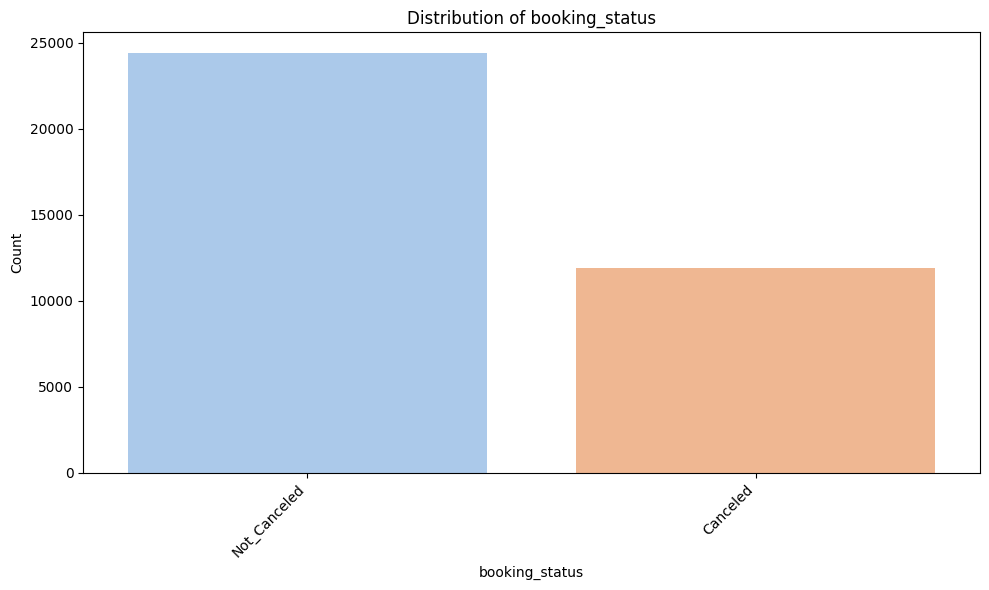

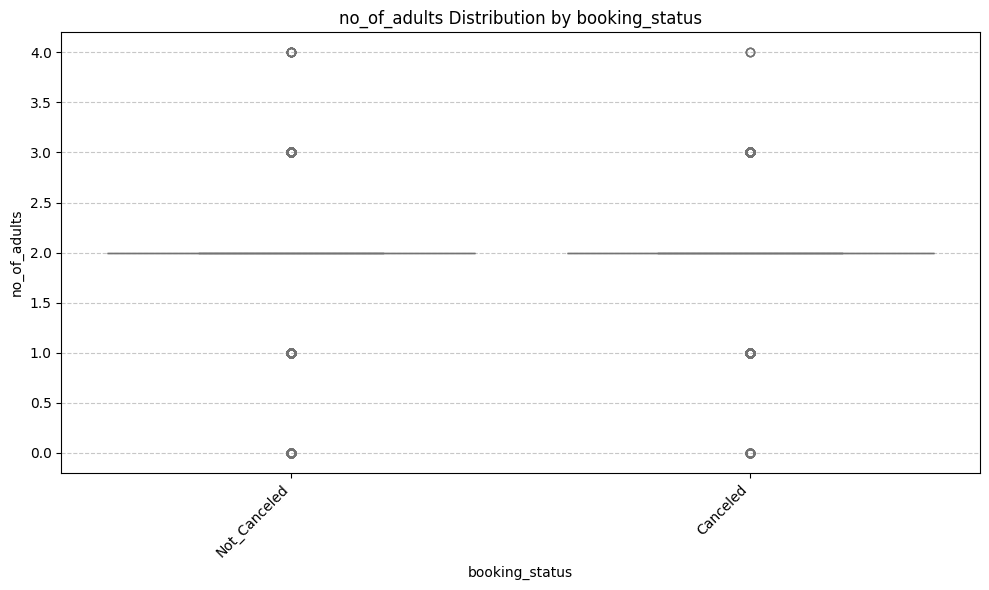

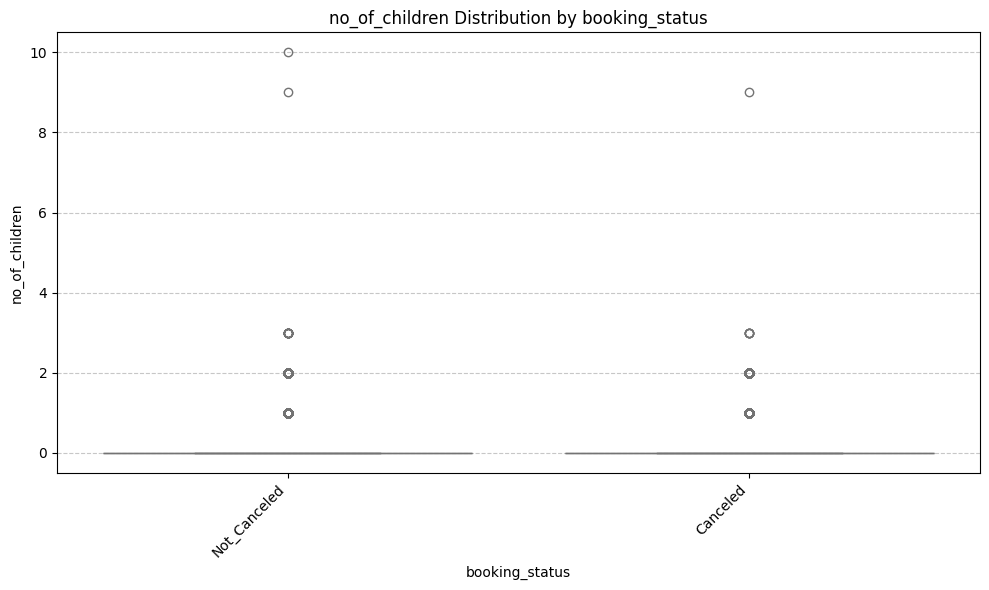

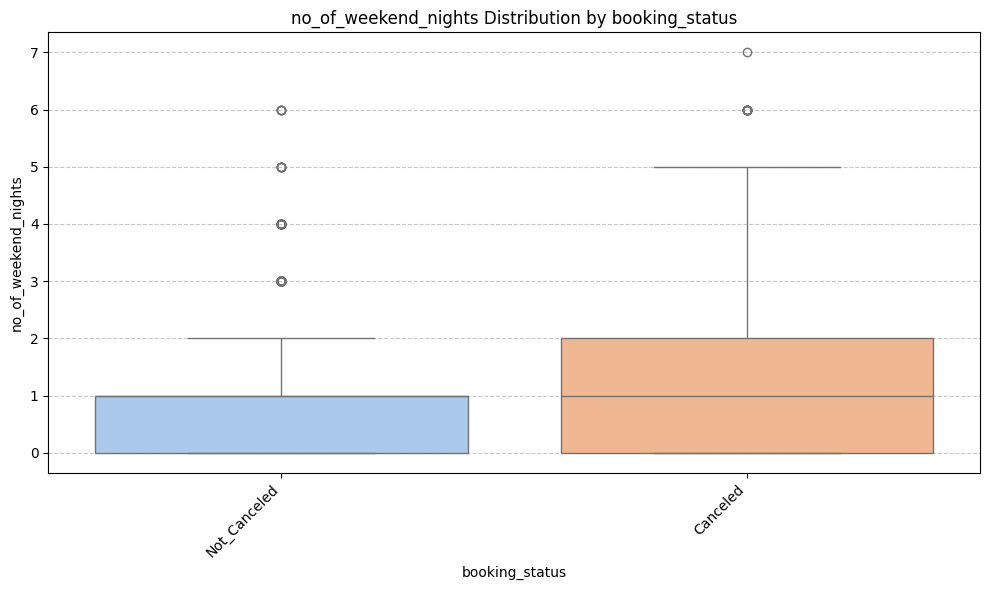

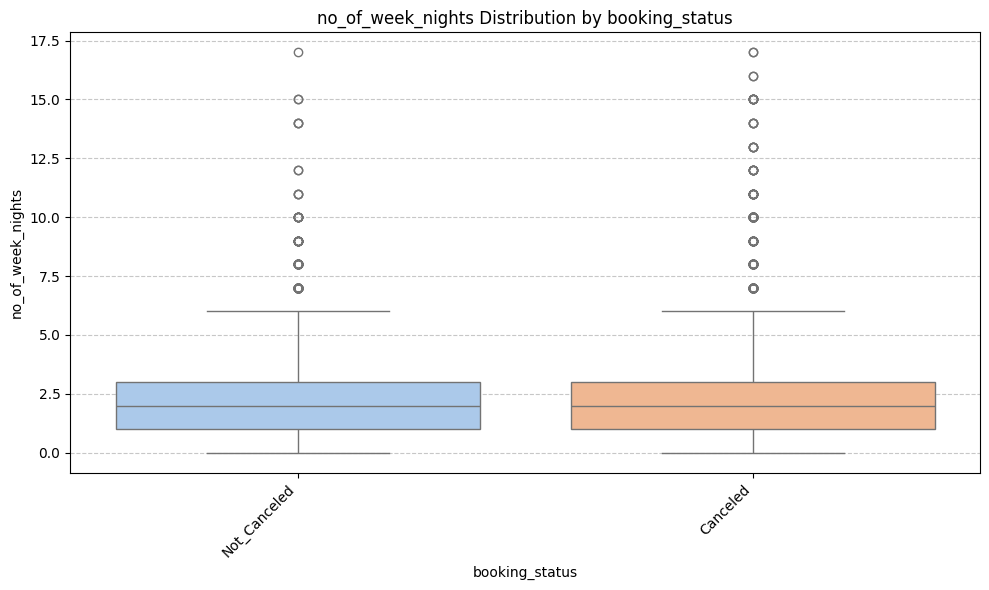

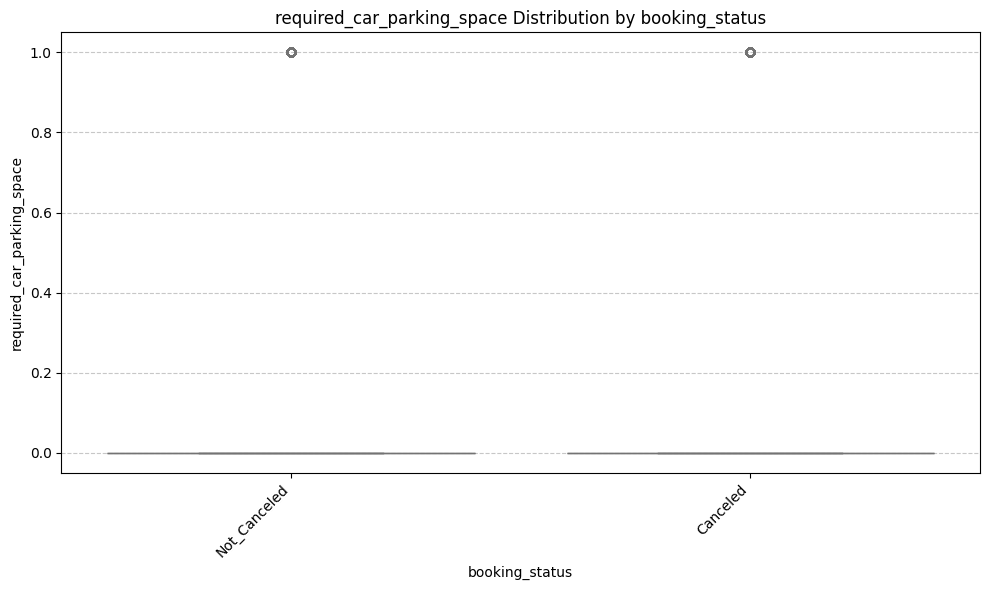

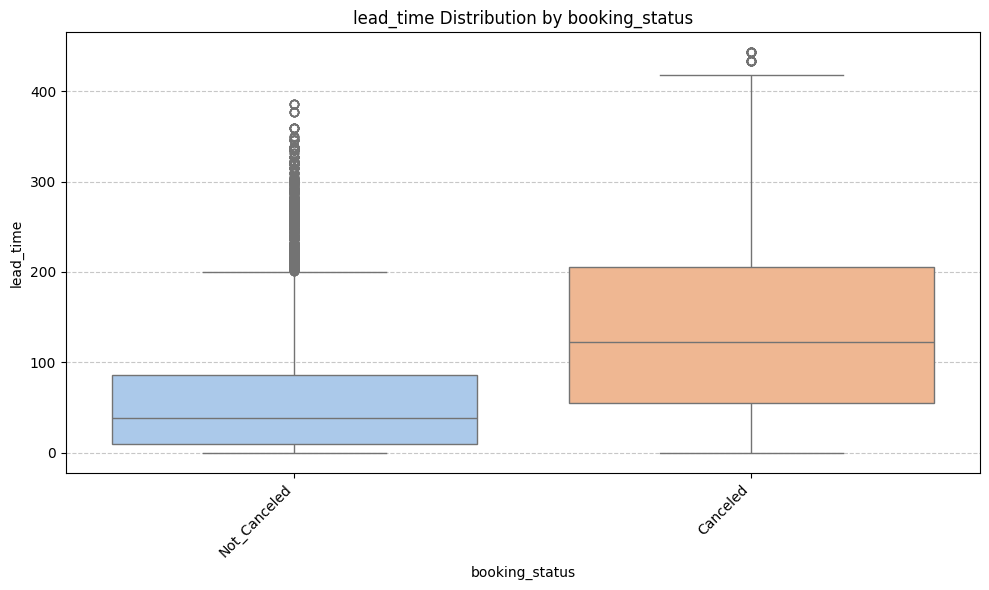

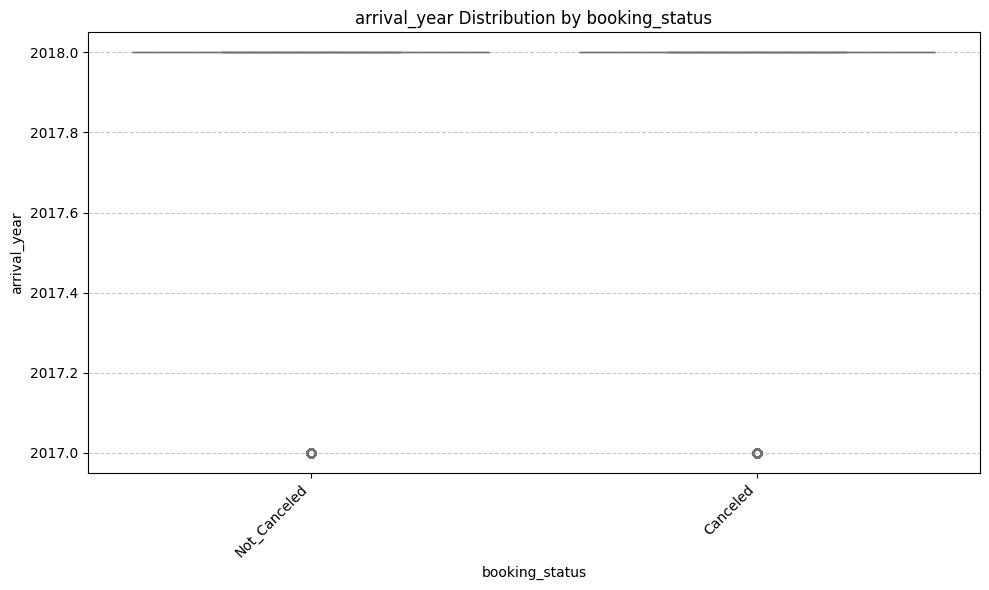

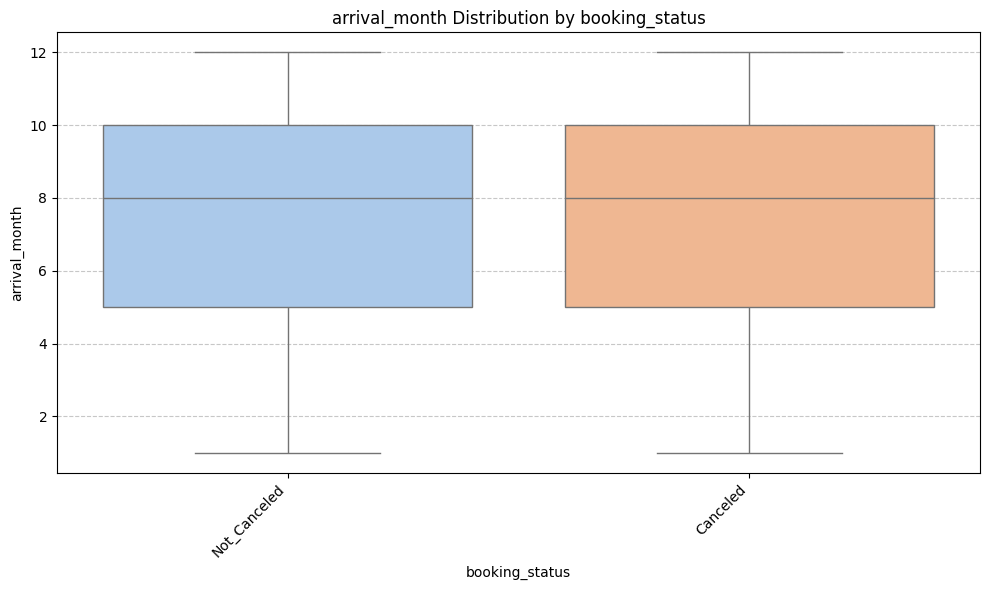

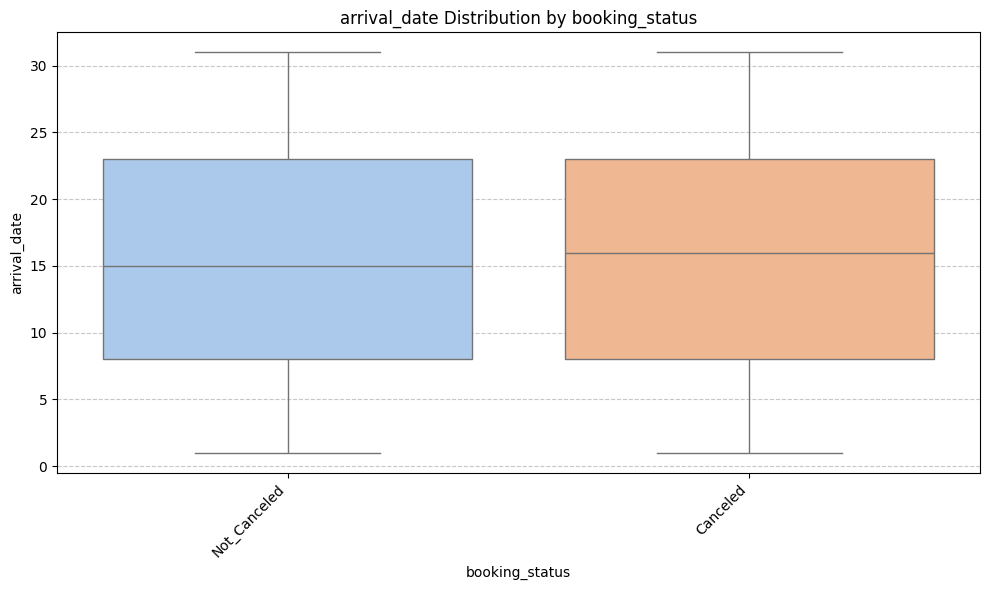

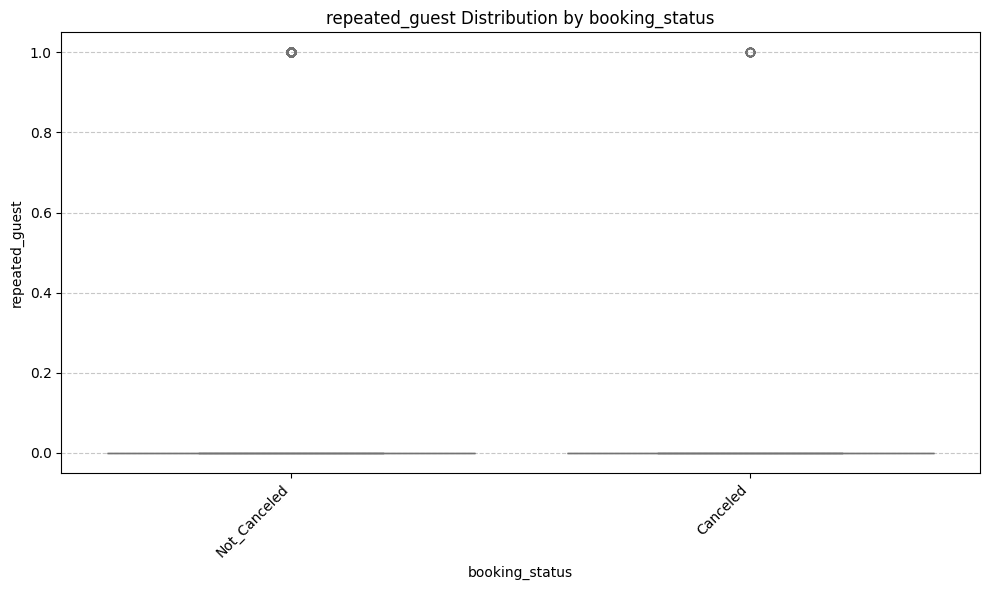

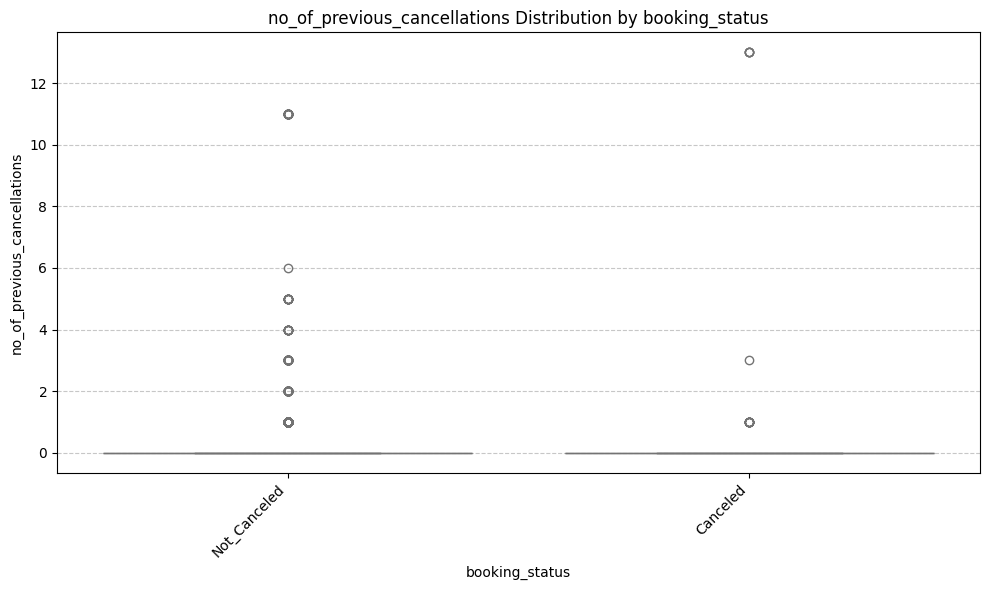

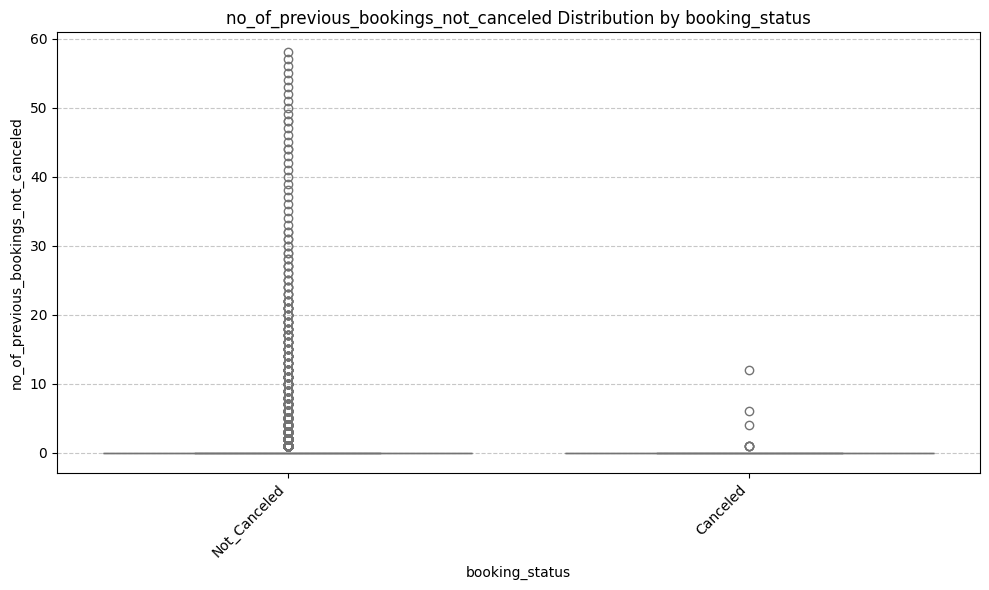

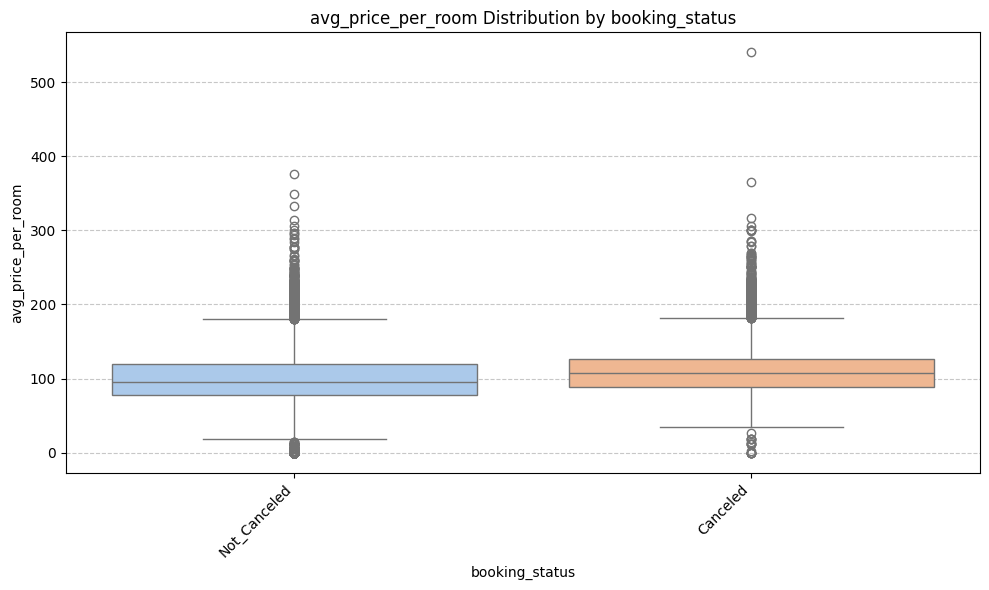

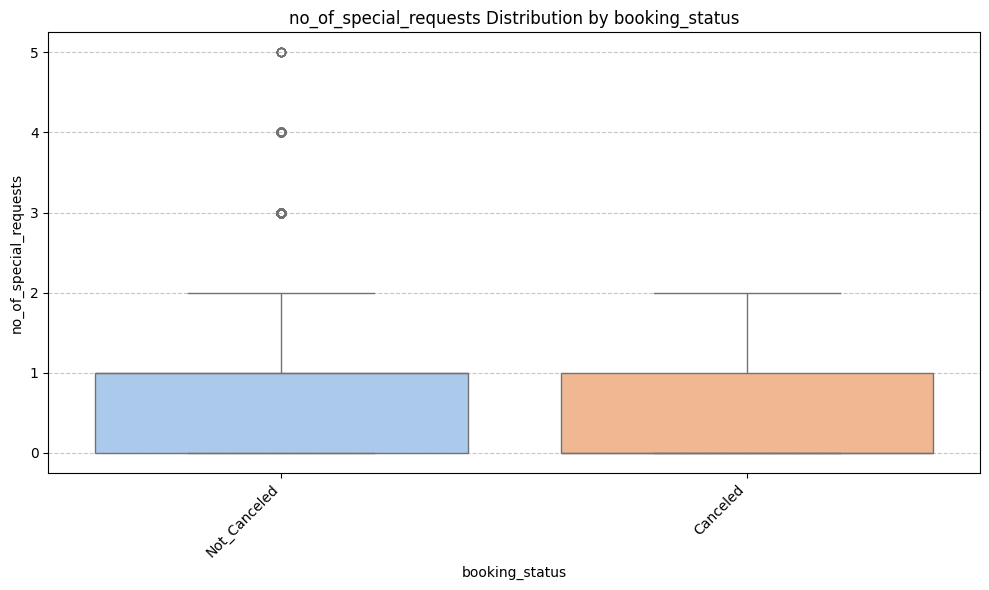

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
cat_col = 'booking_status'
cols_to_plot = [col for col in df.select_dtypes(include=np.number).columns.tolist() if col != cat_col]

# Plot 1: Count Plot for the categorical variable itself
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=cat_col, hue=cat_col, palette='pastel', legend=False)
plt.title(f'Distribution of {cat_col}')
plt.xlabel(cat_col)
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Box Plot for each numerical variable vs. the categorical variable
for num_col in cols_to_plot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=cat_col, y=num_col, hue=cat_col, palette='pastel', legend=False)
    plt.title(f'{num_col} Distribution by {cat_col}')
    plt.xlabel(cat_col)
    plt.ylabel(num_col)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Inferences from Bivariate Analysis (Numerical vs. Booking Status)

Based on the box plots comparing numerical variables against `booking_status`, we can draw the following general inferences:

1.  **Lead Time as a Predictor**: Bookings with a longer `lead_time` (time between booking and arrival) appear to have a higher propensity for cancellation. The box plot for `lead_time` likely shows that 'Canceled' bookings have a higher median and/or a larger interquartile range (IQR) than 'Not_Canceled' bookings.

2.  **Average Price per Room (`avg_price_per_room`)**: The distribution of `avg_price_per_room` might vary significantly between canceled and non-canceled bookings. For instance, bookings with very low or very high average prices might have different cancellation patterns, indicating price sensitivity or a different segment of customers.

3.  **Special Requests and Commitment**: A higher `no_of_special_requests` often correlates with a lower cancellation rate. Guests who take the time to make special requests are generally more committed to their booking, suggesting a lower median for 'Canceled' bookings in this category.

4.  **Previous Booking History**: Features such as `no_of_previous_cancellations` and `repeated_guest` are strong indicators. 'Canceled' bookings will show a higher concentration of previous cancellations, while 'repeated_guest' will predominantly be associated with 'Not_Canceled' bookings, highlighting customer loyalty.

5.  **Room Occupancy and Stay Duration**: Variables like `no_of_adults`, `no_of_children`, `no_of_weekend_nights`, and `no_of_week_nights` might show some differences, but often their distributions between 'Canceled' and 'Not_Canceled' bookings have substantial overlap, implying they might not be the primary standalone predictors of cancellation, but could contribute when combined with other factors.

**Bivariate Analysis for Categorical Vs booking_status**

Categorical columns:

type_of_meal_plan

room_type_reserved

market_segment_type

    Versus

booking_status



--- Bivariate Analysis: booking_status vs other Categorical Columns ---


<Figure size 1200x700 with 0 Axes>

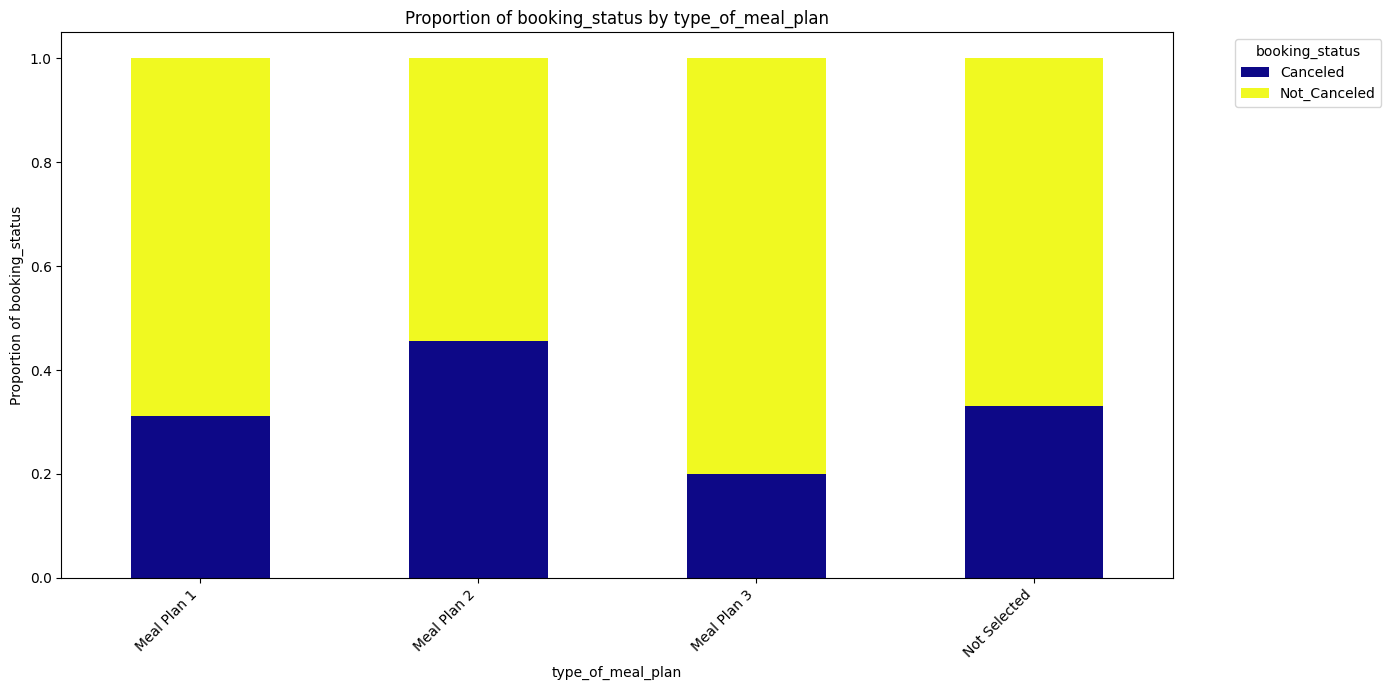


Cross-tabulation for booking_status by type_of_meal_plan:


booking_status,Canceled,Not_Canceled
type_of_meal_plan,,
Meal Plan 1,8679,19156
Meal Plan 2,1506,1799
Meal Plan 3,1,4
Not Selected,1699,3431


<Figure size 1200x700 with 0 Axes>

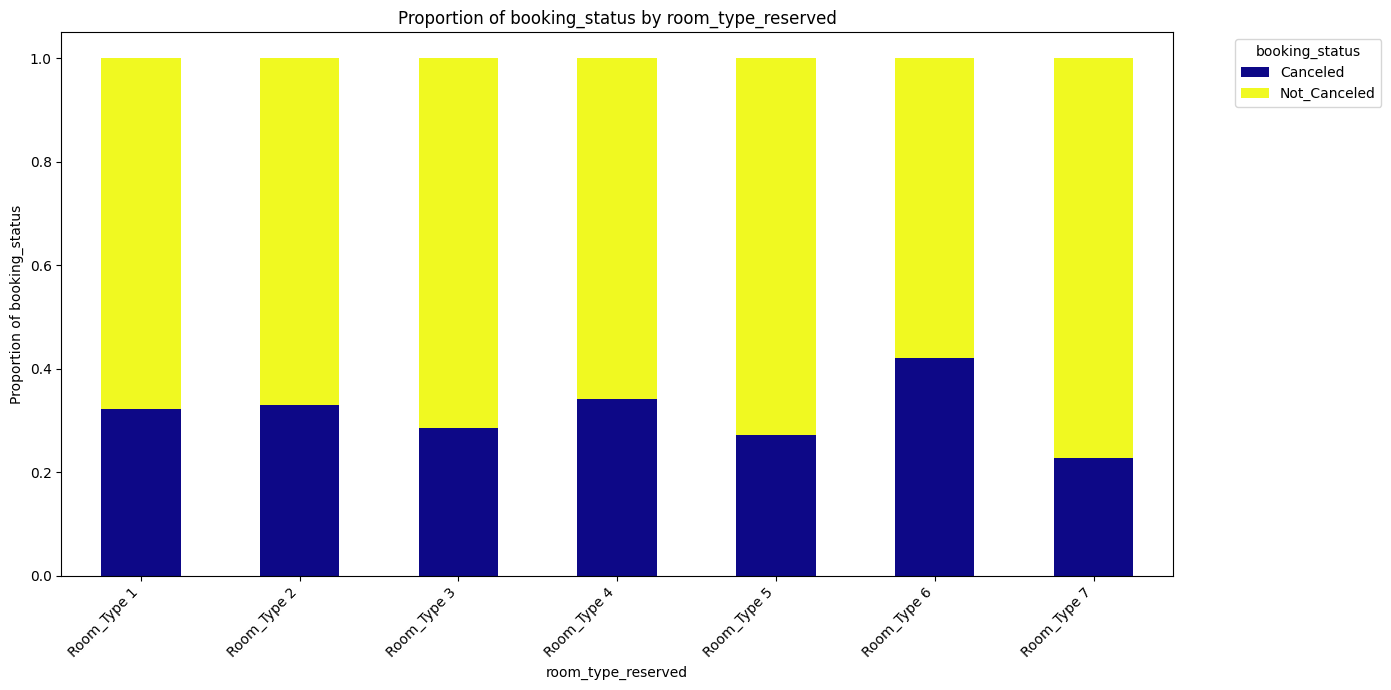


Cross-tabulation for booking_status by room_type_reserved:


booking_status,Canceled,Not_Canceled
room_type_reserved,,
Room_Type 1,9072,19058
Room_Type 2,228,464
Room_Type 3,2,5
Room_Type 4,2069,3988
Room_Type 5,72,193
Room_Type 6,406,560
Room_Type 7,36,122


<Figure size 1200x700 with 0 Axes>

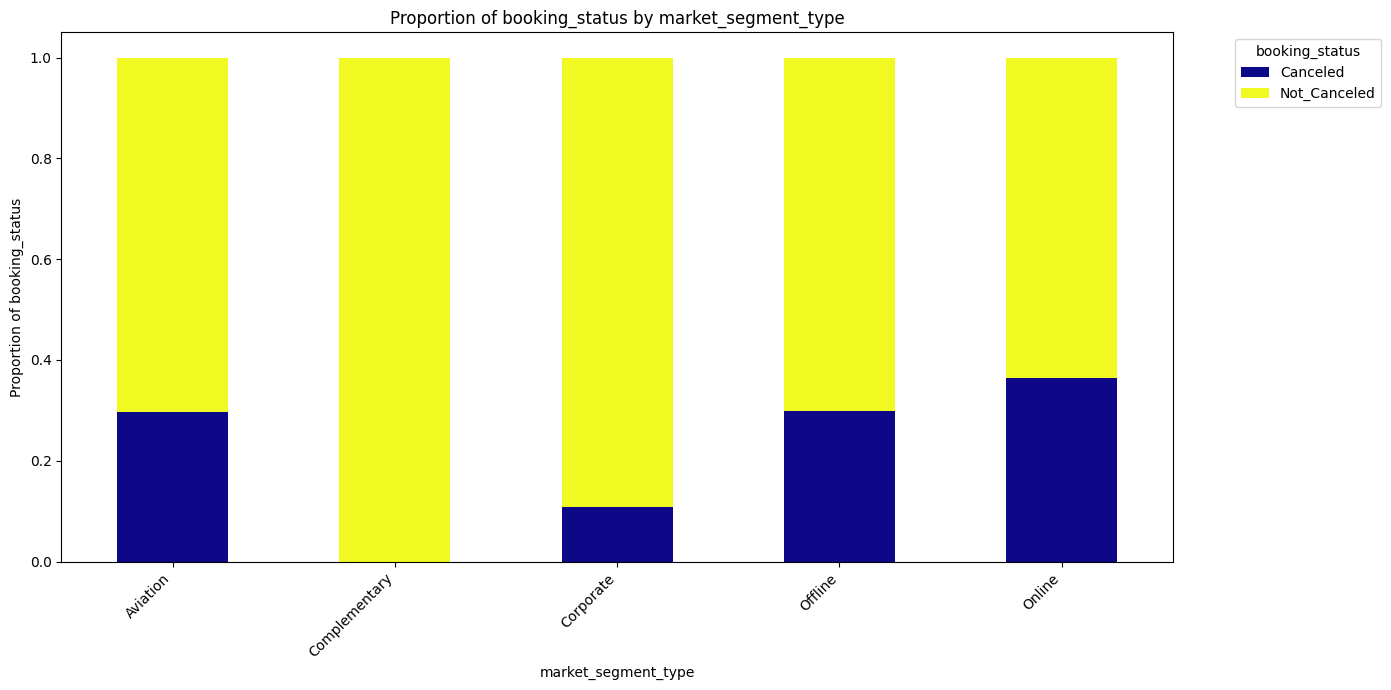


Cross-tabulation for booking_status by market_segment_type:


booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,37,88
Complementary,0,391
Corporate,220,1797
Offline,3153,7375
Online,8475,14739


In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def categorical_bivariate_analysis(df, cat_cols, target_var='booking_status'):
    print(f"\n--- Bivariate Analysis: {target_var} vs other Categorical Columns ---")

    for col in cat_cols:
        if col == target_var:
            continue # Skip if the column is the target variable column itself

        # Create a cross-tabulation (contingency table)
        cross_tab = pd.crosstab(df[col], df[target_var], normalize='index') # normalize to show proportions

        # Plotting as a stacked bar chart
        plt.figure(figsize=(12, 7))
        cross_tab.plot(kind='bar', stacked=True, colormap='plasma', figsize=(14, 7))
        plt.title(f'Proportion of {target_var} by {col}')
        plt.xlabel(col)
        plt.ylabel(f'Proportion of {target_var}')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title=target_var, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

        print(f"\nCross-tabulation for {target_var} by {col}:")
        display(pd.crosstab(df[col], df[target_var]))

cat_cols_for_bivariate = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
categorical_bivariate_analysis(df, cat_cols_for_bivariate, target_var='booking_status')

**Answers to EDA Questions**

**Q1.	What are the busiest months in the hotel?**

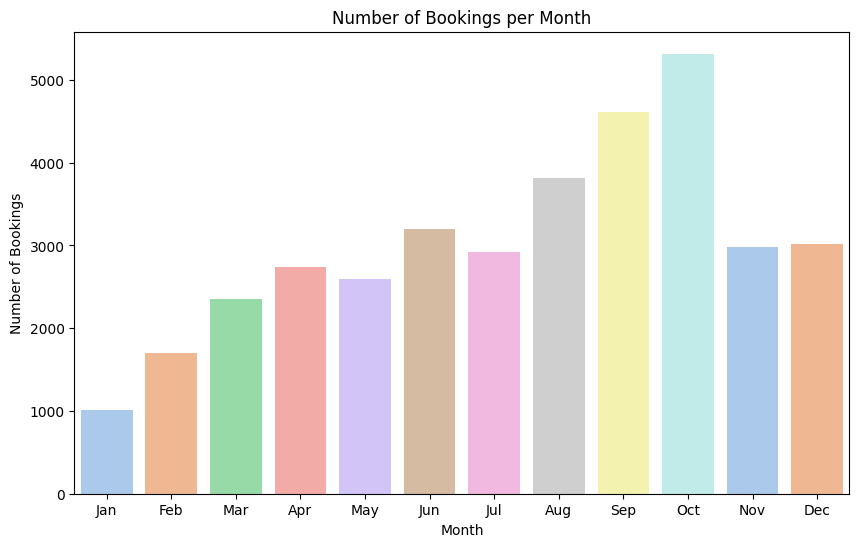

The busiest months in the hotel based on the number of bookings are:
arrival_month
10    5317
9     4611
8     3813
6     3203
12    3021
Name: count, dtype: int64


In [67]:
busiest_months = df['arrival_month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=busiest_months.index, y=busiest_months.values, palette='pastel', hue=busiest_months.index, legend=False)
plt.title('Number of Bookings per Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

print("The busiest months in the hotel based on the number of bookings are:")
print(busiest_months.sort_values(ascending=False).head(5))

**Answer:**

The busiest month in the hotel is **October**.

It is followed by  September, August and June.

The lowest busy month is January


**Q2. Which market segment do most of the guests come from?**

market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64


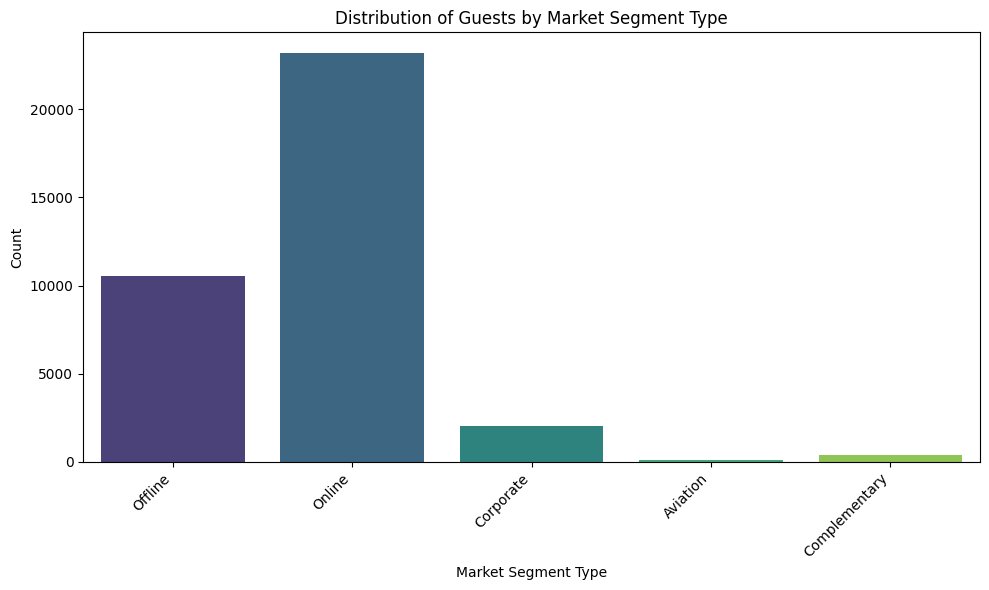

In [68]:
market_segment_type = df['market_segment_type'].value_counts()
print(market_segment_type.sort_values(ascending=False))
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='market_segment_type', hue='market_segment_type', palette='viridis', legend=False)
plt.title('Distribution of Guests by Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Answer:**

Most of the guests come from the **Online** market segment, accounting for `23214` bookings.

The distribution of market segments is as follows:

*   **Online**: 23214 bookings
*   **Offline**: 10528 bookings
*   **Corporate**: 2017 bookings
*   **Complementary**: 391 bookings
*   **Aviation**: 125 bookings

**Q3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?**

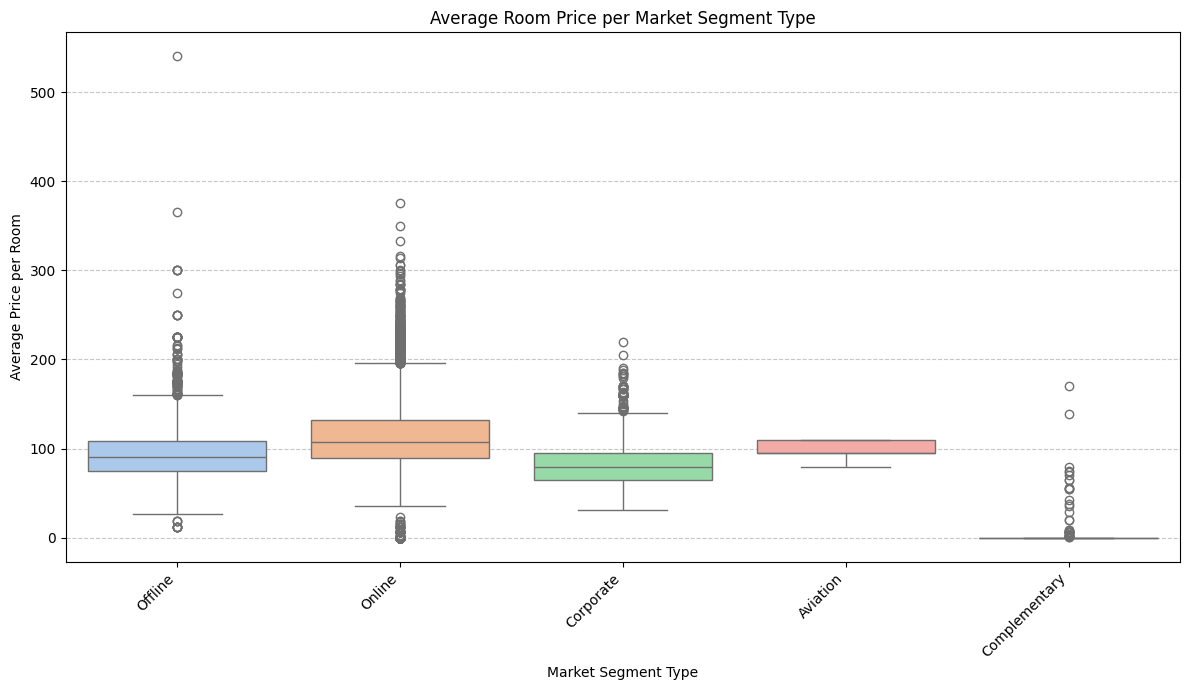

In [69]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='market_segment_type', y='avg_price_per_room', hue='market_segment_type', palette='pastel', legend=False)
plt.title('Average Room Price per Market Segment Type')
plt.xlabel('Market Segment Type')
plt.ylabel('Average Price per Room')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Inferences from Average Room Price per Market Segment Type

*   **Online Segment**: This segment generally exhibits the highest median average prices and the widest range, indicating dynamic pricing and high demand through online booking channels.
*   **Offline Segment**: While still showing a broad price range, the median average price for offline bookings appears slightly lower than online, suggesting a different pricing structure or customer base.
*   **Corporate Segment**: Bookings from the corporate segment tend to have a more consistent and often lower average price, likely due to pre-negotiated rates or bulk bookings.
*   **Complementary Segment**: This segment shows the lowest average prices, with a significant number of bookings potentially at zero cost, indicative of promotional stays or special guest arrangements.
*   **Aviation Segment**: This segment has a moderate average price range, often with a tighter distribution, which might reflect specific contractual agreements or a specialized clientele.

**Summary:** The pricing strategy for INN Hotels is highly dynamic and segment-dependent, with online channels driving the highest average prices, while corporate and complementary segments often benefit from lower or special rates.

**Q4.What percentage of bookings are cancelled?**

In [70]:
booking_status_counts = df['booking_status'].value_counts()
total_bookings = booking_status_counts.sum()
canceled_bookings = booking_status_counts.get('Canceled', 0)

percentage_canceled = (canceled_bookings / total_bookings) * 100

print(f"Total bookings: {total_bookings}")
print(f"Canceled bookings: {canceled_bookings}")
print(f"Percentage of canceled bookings: {percentage_canceled:.2f}%")

Total bookings: 36275
Canceled bookings: 11885
Percentage of canceled bookings: 32.76%


**Answer:**

Total bookings: 36275

Canceled bookings: 11885

Percentage of canceled bookings: **32.76%**

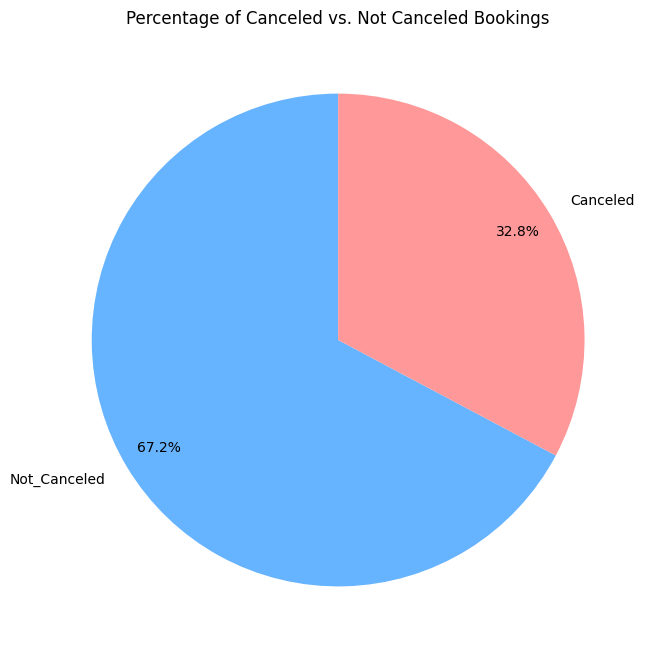

In [71]:
plt.figure(figsize=(8, 8))
booking_status_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'], pctdistance=0.85)
plt.title('Percentage of Canceled vs. Not Canceled Bookings')
plt.ylabel('') # Hide the default 'booking_status' label on y-axis for better aesthetics
plt.show()

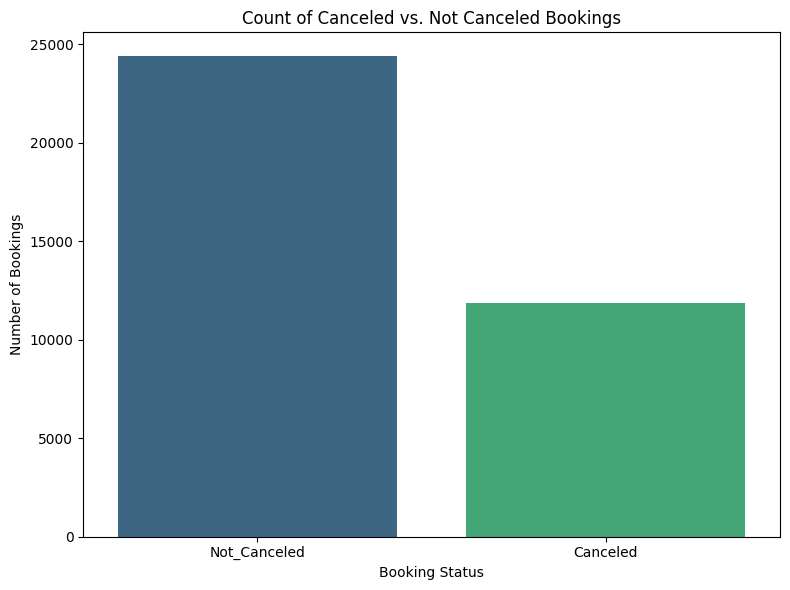

In [72]:
plt.figure(figsize=(8, 6))
sns.barplot(x=booking_status_counts.index, y=booking_status_counts.values, palette='viridis', hue=booking_status_counts.index, legend=False)
plt.title('Count of Canceled vs. Not Canceled Bookings')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

**Q5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?**

In [73]:
# Filter for repeating guests
repeating_guests_df = df[df['repeated_guest'] == 1]

# Calculate booking status counts for repeating guests
repeating_guest_status_counts = repeating_guests_df['booking_status'].value_counts()

# Get total repeating guest bookings
total_repeating_guest_bookings = repeating_guest_status_counts.sum()

# Get canceled repeating guest bookings
canceled_repeating_guest_bookings = repeating_guest_status_counts.get('Canceled', 0)

# Calculate percentage of canceled bookings for repeating guests
percentage_canceled_repeating_guests = (canceled_repeating_guest_bookings / total_repeating_guest_bookings) * 100 if total_repeating_guest_bookings > 0 else 0

print(f"Total repeating guest bookings: {total_repeating_guest_bookings}")
print(f"Canceled repeating guest bookings: {canceled_repeating_guest_bookings}")
print(f"Percentage of repeating guests who cancel: {percentage_canceled_repeating_guests:.2f}%")

Total repeating guest bookings: 930
Canceled repeating guest bookings: 16
Percentage of repeating guests who cancel: 1.72%


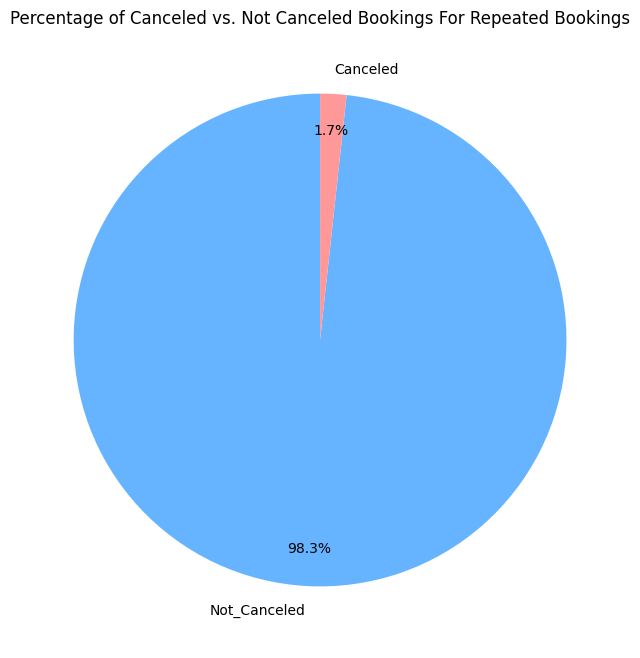

In [74]:
plt.figure(figsize=(8, 8))
repeating_guest_status_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'], pctdistance=0.85)
plt.title('Percentage of Canceled vs. Not Canceled Bookings For Repeated Bookings')
plt.ylabel('') # Hide the default 'booking_status' label on y-axis for better aesthetics
plt.show()

**Answer:**

Total repeating guest bookings: 930

Canceled repeating guest bookings: 16

Percentage of repeating guests who cancel: **1.72%**

This indicates that a very small percentage of repeating guests cancel their bookings, highlighting the loyalty and reliability of repeated guests who comes.

**Q6.	Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

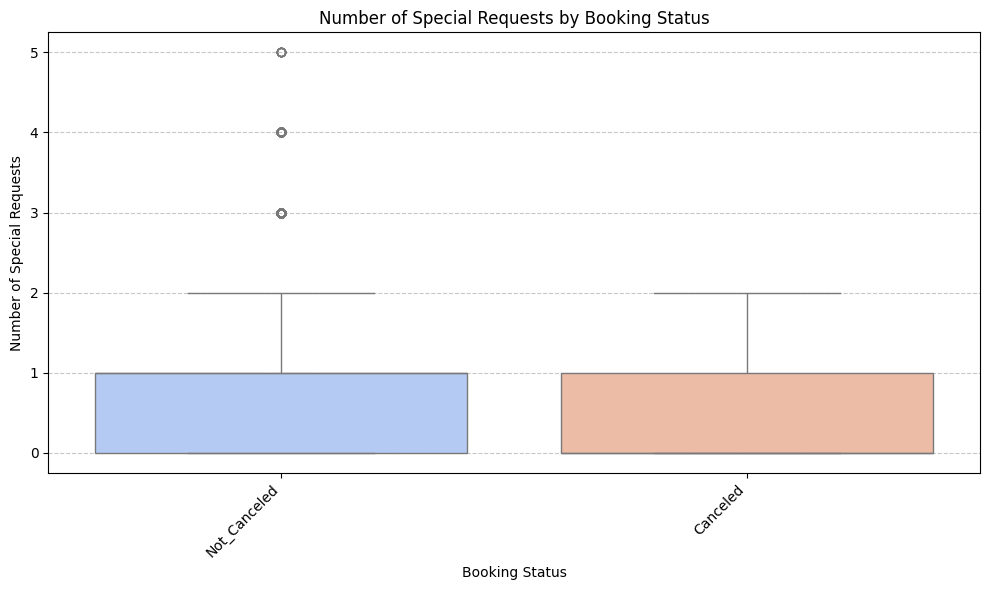

In [75]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='booking_status', y='no_of_special_requests', hue='booking_status', palette='coolwarm', legend=False)
plt.title('Number of Special Requests by Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Number of Special Requests')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print('Descriptive Statistics for no_of_special_requests by Booking Status:')
print(df.groupby('booking_status')['no_of_special_requests'].describe())

Descriptive Statistics for no_of_special_requests by Booking Status:
                  count      mean       std  min  25%  50%  75%  max
booking_status                                                      
Canceled        11885.0  0.334623  0.574345  0.0  0.0  0.0  1.0  2.0
Not_Canceled    24390.0  0.758549  0.836532  0.0  0.0  1.0  1.0  5.0


### Inference: Number of Special Requests vs. Booking Cancellation

Based on the descriptive statistics for no_of_special_requests by booking_status:

**Canceled Bookings:** The mean number of special requests is approximately 0.33, with a median (50th percentile) of 0. This indicates that most canceled bookings had no special requests, or very few.

**Not Canceled Bookings:** The mean number of special requests is significantly higher at approximately 0.76, with a median (50th percentile) of 1. This suggests that non-canceled bookings tend to have more special requests.

**Inference:** There is a clear difference in the number of special requests between canceled and not-canceled bookings. Bookings with special requests are less likely to be canceled. This could imply that guests who make special requests are more committed to their reservations, as they have invested more effort into planning their stay. This information is valuable for understanding guest commitment and potentially for identifying bookings that are at a lower risk of cancellation.

**Customer Commitment**: This suggests that guests who take the time to make special requests are generally more committed to their booking and are less likely to cancel. These requests could indicate a higher investment in the trip planning, making cancellation less desirable for the guest.

**Operational Implications**: This observation could be valuable for hotels, as bookings with special requests might represent a more reliable revenue stream. Hotels could potentially prioritize fulfilling these requests to further enhance guest satisfaction and reduce the already low cancellation risk from this segment.

**Key meaningful observations on individual variables and the relationship between variables**

## Key Meaningful Observations

### General Booking Patterns:
*   **Occupancy**: Most bookings are for 2 adults. Bookings with children are rare (75% have 0 children).
*   **Stay Duration**: Stays are generally short, typically 1-3 weeknights and up to 2 weekend nights.
*   **Parking**: Very few guests (around 3%) require a car parking space.
*   **Lead Time**: Bookings exhibit a wide lead time, with a median of 57 days, indicating both last-minute and planned reservations.
*   **Arrival Trend**: The data is concentrated in 2017 and 2018. October, September, and August are identified as the busiest months for arrivals.

### Guest Loyalty and Cancellation Behavior:
*   **Repeat Guests**: The hotel has a very low percentage of repeated guests (around 2.5%).
*   **Previous History**: Most guests have no prior cancellations or non-canceled bookings, suggesting a largely new customer base.
*   **Cancellation Rate**: The overall booking cancellation rate is significant, standing at **32.76%**.
*   **Repeat Guest Loyalty**: Repeating guests show exceptionally high loyalty, with only **1.72%** of their bookings being canceled, indicating they are a highly reliable segment.

### Market Segments and Pricing:
*   **Dominant Market**: The 'Online' market segment is by far the most dominant, accounting for the majority of bookings (over 23,000).
*   **Dynamic Pricing**: The average price per room is highly dynamic, ranging from 0 to 540 euros. 'Online' bookings generally command the highest average prices, while 'Corporate' and 'Complementary' segments tend to have lower or special rates.

### Factors Influencing Cancellation:
*   **Lead Time**: Bookings made with a longer `lead_time` tend to have a higher propensity for cancellation.
*   **Special Requests**: A crucial finding is the inverse relationship between special requests and cancellation. Bookings with more special requests are significantly less likely to be canceled (mean special requests: 0.76 for Not_Canceled vs. 0.33 for Canceled). This suggests that guests who invest effort in making specific requests are more committed to their stay.
*   **Previous Booking History**: `repeated_guest` and `no_of_previous_cancellations` are strong indicators; repeat guests and those with no prior cancellations are less likely to cancel the current booking.

### Relationships Between Variables:
*   **Correlation**: There is a  positive correlation (0.54) between `repeated_guest` and `no_of_previous_bookings_not_canceled`, which is expected as repeat guests are those with previous non-canceled bookings.
*   **Price and Occupancy**: Moderate positive correlations exist between `no_of_children` and `avg_price_per_room` (0.34), and `no_of_adults` and `avg_price_per_room` (0.30). This suggests that family-friendly or larger group bookings often correspond to higher average room prices.

**Data Pre-Processing**

**Missing Value Treatment**

In [76]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


There are no missing values

In [77]:
df.shape

(36275, 19)

There are 36275 rows and 19 columns

In [78]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values

**Outlier Detection and Treatment**

### Outlier Detection using Box Plots

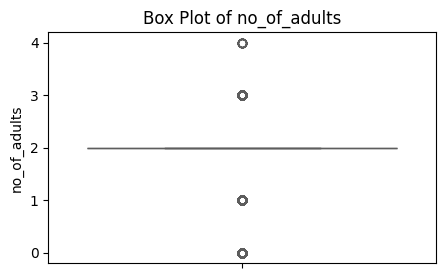

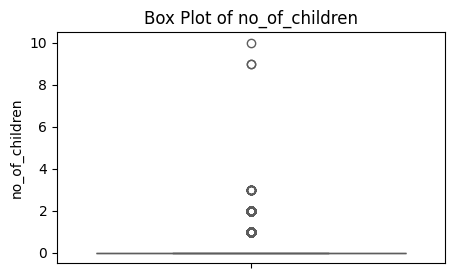

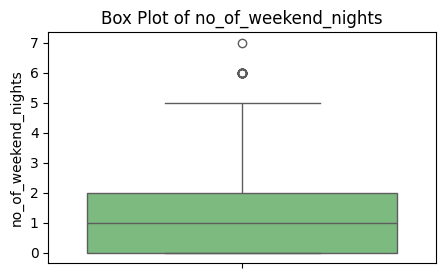

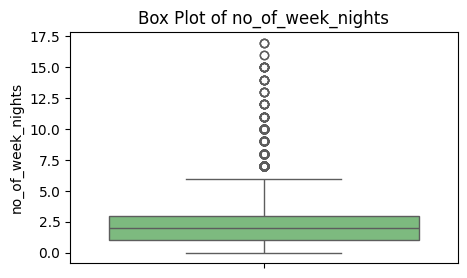

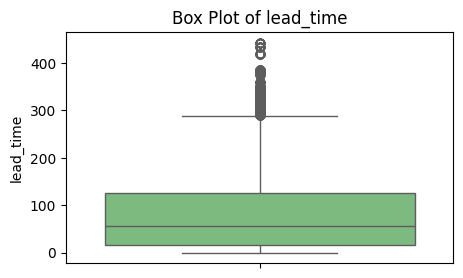

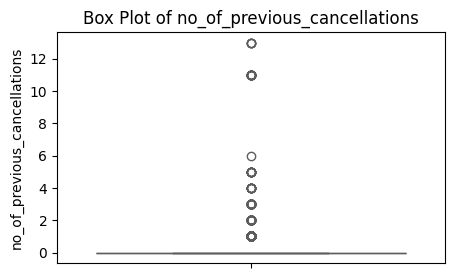

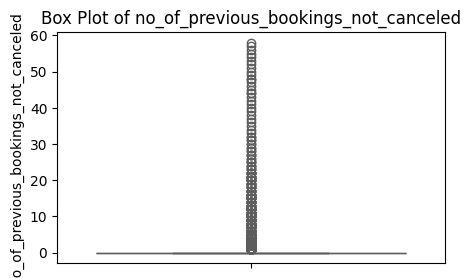

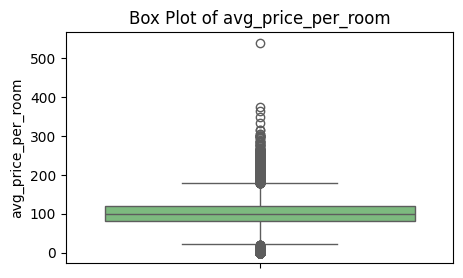

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Identify numerical columns likely to have outliers
outlier_cols = ['no_of_adults',  'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights',
                  'lead_time','no_of_previous_cancellations','no_of_previous_bookings_not_canceled','avg_price_per_room']

for col in outlier_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[col],  whis=1.5, patch_artist=True, palette='Greens')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

Based on the box plots generated for the numerical columns, we can observe the following regarding outliers:

no_of_adults: While most bookings are for 2 adults, there are some outliers where no_of_adults is 0 (which might indicate data entry errors or very specific booking types, e.g., only children), and also a few bookings with 3 or 4 adults.

no_of_children: The majority of bookings have 0 children. There are clear outliers where the number of children is 1, 2, 3, and even up to 10, indicating family bookings.

no_of_weekend_nights: Most bookings involve 0, 1, or 2 weekend nights. Outliers are present for stays involving 3 or more weekend nights, extending up to 7 nights.

no_of_week_nights: Similar to weekend nights, the bulk of bookings are for 1, 2, or 3 weeknights. There are significant outliers for longer stays, reaching up to 17 weeknights.

lead_time: The lead_time distribution shows a long tail of outliers, with many bookings made far in advance (over 200 days, up to 443 days), while the majority are made within a shorter period.

no_of_previous_cancellations: Overwhelmingly, guests have no previous cancellations. The box plot clearly shows outliers for guests who have 1, 2, or more previous cancellations (up to 13), indicating a small group of repeat cancellers.

no_of_previous_bookings_not_canceled: Most guests have 0 previous non-canceled bookings. Outliers exist for guests with multiple previous successful bookings (e.g., 1, 2, and up to 58), representing loyal, repeated guests.

avg_price_per_room: The average price per room has outliers at the lower end (including 0, which could be promotional or internal bookings) and at the higher end, indicating premium room types or high-demand periods (up to 540 euros).

These outliers suggest a diverse customer base and booking behaviors, and their treatment (e.g., capping) helps to prevent extreme values from disproportionately influencing model training later on.

If we remove these outliers, it might affect the booking behaviours captured.It is better to handle it in model.

Decision Tree Classifier (Robust by Design): Decision Trees are non-parametric and split data based on thresholds. The "extreme" nature of an outlier doesn't pull the split point the way it pulls a mean in linear models and hence no treatment is needed for the Decision Tree model.

Logistic Regression (Sensitivity Check): Unlike trees, Logistic Regression is a mathematical model that can be influenced by the magnitude of outliers. To fix this simply swap StandardScaler for RobustScaler (sklearn.preprocessing.RobustScaler). It scales data based on the Median and Interquartile Range (IQR) rather than the Mean and Standard Deviation. This ensures that the extreme values don't "shrink" the rest of your data into a tiny range.

**Feature Engineering**

Let us duplicate the data frame

1. For the Logistic Regression

2. For the Decision Tree

and then do the feature engineering

In [80]:
df_reg = df.copy()
df_dec = df.copy()

In [81]:
df_reg.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [82]:
df_dec.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [83]:
df_reg.shape

(36275, 19)

In [84]:
df_dec.shape

(36275, 19)

**Feature Engineering for the Logistic Regression**

1. Remove the Unique Identified for Booking ID
2. Target Variable To be Converted to Numerical

Convert the booking_status column into numerical format (e.g., 'Not_Canceled' to 0 and 'Canceled' to 1).

3. One Hot Encoding:

 Convert categorical features (type_of_meal_plan, room_type_reserved, market_segment_type) into numerical representations

 4. Numerical Feature Scaling: Scale numerical features (no_of_adults, no_of_children, no_of_weekend_nights, no_of_week_nights, lead_time, avg_price_per_room, no_of_special_requests, etc.). Since logistic regression is sensitive to outliers and the descriptive text mentioned using RobustScaler, this would be a suitable choice. RobustScaler is less affected by outliers than StandardScaler.

5. Feature Transformation (for skewed data): Apply transformations like log1p to highly skewed numerical features (e.g., lead_time, avg_price_per_room, no_of_previous_cancellations, no_of_previous_bookings_not_canceled) to make their distributions more Gaussian-like and reduce the impact of extreme values, which can improve model performance.

6. Date-related Features: Although arrival_year, arrival_month, and arrival_date are already numerical, we consider combining them into a single date feature and extracting other time-based features if relevant (e.g., day of week, season).

7. One Hot Encoding For Season:

 Convert season into numerical representations

8. Drop the arrival_full_date created to figure out whether it is weekend or weekday.

9. Drop the season object field after one hot encoding


1. Remove Booking ID

In [85]:
df_reg.drop('Booking_ID', axis=1, inplace=True)

2. Convert Booking Status To Numerical

Not_Canceled = 0

Canceled = 1

In [86]:
df_reg['booking_status'] = df_reg['booking_status'].replace({'Not_Canceled': 0, 'Canceled': 1})

In [87]:
display(df_reg['booking_status'].value_counts())

,count
booking_status,
0,24390
1,11885


In [88]:
display(df_reg.head())

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,1
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,1
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,1


3. One Hot Encoding:

Convert categorical features (type_of_meal_plan, room_type_reserved, market_segment_type) into numerical representations

In [89]:
cat_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
df_reg = pd.get_dummies(df_reg, columns=cat_cols, drop_first=True)
display(df_reg.head())
display(df_reg.columns)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,False,True


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online'],
      dtype='object')

4. Date-related Features:

Although arrival_year, arrival_month, and arrival_date are already numerical, we consider combining them into a single date feature and extracting other time-based features if relevant (e.g., day of week, season, length of stay).

1. IsWeekend
2. Portgual Season from the arrival month

Spring (March to May):

Summer (June to August):

Autumn (September to October)

Winter (November to February):

3. IsComplimentary - avg_price_per_room is Zero


### 4. Date-related and Other Derived Features

In [90]:
# 1. Create a combined 'arrival_date_full' column
df_reg['arrival_date_full'] = pd.to_datetime(df_reg['arrival_year'].astype(str) + '-' +
                                            df_reg['arrival_month'].astype(str) + '-' +
                                            df_reg['arrival_date'].astype(str), errors='coerce')

# Handle potential errors if any date conversion fails (though not expected with current data)
df_reg.dropna(subset=['arrival_date_full'], inplace=True)

# Extract 'IsWeekend'
df_reg['is_weekend'] = df_reg['arrival_date_full'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# 2. Extract 'Season' from 'arrival_month' Based on season of Portugal
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_reg['season'] = df_reg['arrival_month'].apply(get_season)

# 3. 'IsComplimentary' from 'market_segment_type_Complementary' and avg_price_per_room
# Assuming 'Complementary' bookings often have very low or zero price
df_reg['is_complimentary'] = (df_reg['avg_price_per_room'] <= 1).astype(int)

display(df_reg.head())
display(df_reg.columns)
display(df_reg.info())

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,arrival_date_full,is_weekend,season,is_complimentary
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,True,False,2017-10-02,0,Autumn,0
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,True,2018-11-06,0,Autumn,0
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,True,2018-02-28,0,Winter,0
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,True,2018-05-20,1,Spring,0
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,True,2018-04-11,0,Spring,0


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'arrival_date_full', 'is_weekend',
       'season', 'is_complimentary'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 36238 entries, 0 to 36274
Data columns (total 32 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          36238 non-null  int64         
 1   no_of_children                        36238 non-null  int64         
 2   no_of_weekend_nights                  36238 non-null  int64         
 3   no_of_week_nights                     36238 non-null  int64         
 4   required_car_parking_space            36238 non-null  int64         
 5   lead_time                             36238 non-null  int64         
 6   arrival_year                          36238 non-null  int64         
 7   arrival_month                         36238 non-null  int64         
 8   arrival_date                          36238 non-null  int64         
 9   repeated_guest                        36238 non-null  int64         
 10  no_

None

5. One Hot Encoding For Season:

 Convert season into numerical representations

 Drop the season object field after one hot encoding

In [91]:
df_reg = pd.get_dummies(df_reg, columns=['season'], drop_first=True)
display(df_reg.head())
display(df_reg.columns)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,arrival_date_full,is_weekend,is_complimentary,season_Spring,season_Summer,season_Winter
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,True,False,2017-10-02,0,0,False,False,False
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,True,2018-11-06,0,0,False,False,False
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,True,2018-02-28,0,0,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,True,2018-05-20,1,0,True,False,False
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,True,2018-04-11,0,0,True,False,False


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'arrival_date_full', 'is_weekend',
       'is_complimentary', 'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

6. Drop the arrival_full_date created to figure out whether it is weekend or weekday.

In [92]:
df_reg.drop('arrival_date_full', axis=1, inplace=True)
df_reg.drop('arrival_date', axis=1, inplace=True)
df_reg.drop('arrival_month', axis=1, inplace=True)
display(df_reg.head())
display(df_reg.columns)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,...,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,is_weekend,is_complimentary,season_Spring,season_Summer,season_Winter
0,2,0,1,2,0,224,2017,0,0,0,...,False,False,False,True,False,0,0,False,False,False
1,2,0,2,3,0,5,2018,0,0,0,...,False,False,False,False,True,0,0,False,False,False
2,1,0,2,1,0,1,2018,0,0,0,...,False,False,False,False,True,0,0,False,False,True
3,2,0,0,2,0,211,2018,0,0,0,...,False,False,False,False,True,1,0,True,False,False
4,2,0,1,1,0,48,2018,0,0,0,...,False,False,False,False,True,0,0,True,False,False


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'is_weekend', 'is_complimentary',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

In [93]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36238 entries, 0 to 36274
Data columns (total 31 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36238 non-null  int64  
 1   no_of_children                        36238 non-null  int64  
 2   no_of_weekend_nights                  36238 non-null  int64  
 3   no_of_week_nights                     36238 non-null  int64  
 4   required_car_parking_space            36238 non-null  int64  
 5   lead_time                             36238 non-null  int64  
 6   arrival_year                          36238 non-null  int64  
 7   repeated_guest                        36238 non-null  int64  
 8   no_of_previous_cancellations          36238 non-null  int64  
 9   no_of_previous_bookings_not_canceled  36238 non-null  int64  
 10  avg_price_per_room                    36238 non-null  float64
 11  no_of_special_reques

**Feature Engineered Columns for Logistic Regression:**

Data columns (total 31 columns)

['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'is_weekend', 'is_complimentary',
       'season_Spring', 'season_Summer', 'season_Winter']

**Feature Engineering For Decision Tree**

1. Remove the Unique Identified for Booking ID
2. Target Variable To be Converted to Numerical
Convert the booking_status column into numerical format (e.g., 'Not_Canceled' to 0 and 'Canceled' to 1).

3. Label Encoding:
Convert categorical features (type_of_meal_plan, room_type_reserved, market_segment_type) into numerical representations

4. Date-related Features: Although arrival_year, arrival_month, and arrival_date are already numerical, we consider combining them into a single date feature and extracting other time-based features if relevant (e.g., day of week, season).

5. Label Encoding For Season:

Convert season into numerical representations

6. Drop the arrival_full_date created to figure out whether it is weekend or weekday.



In [94]:
# 1. Remove Booking ID
df_dec.drop('Booking_ID', axis=1, inplace=True)


In [95]:
# 2. Convert Booking Status To Numerical
# Not_Canceled = 0, Canceled = 1
df_dec['booking_status'] = df_dec['booking_status'].replace({'Not_Canceled': 0, 'Canceled': 1})
display(df_dec['booking_status'].value_counts())
display(df_dec.head())

,count
booking_status,
0,24390
1,11885


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,1
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,1
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,1


In [96]:
from sklearn.preprocessing import LabelEncoder

# 3. Label Encoding for categorical features
label_encoder = LabelEncoder()
cat_cols_dec = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

for col in cat_cols_dec:
    df_dec[col] = label_encoder.fit_transform(df_dec[col])

display(df_dec.head())
display(df_dec.columns)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,0,0,0,224,2017,10,2,3,0,0,0,65.00,0,0
1,2,0,2,3,3,0,0,5,2018,11,6,4,0,0,0,106.68,1,0
2,1,0,2,1,0,0,0,1,2018,2,28,4,0,0,0,60.00,0,1
3,2,0,0,2,0,0,0,211,2018,5,20,4,0,0,0,100.00,0,1
4,2,0,1,1,3,0,0,48,2018,4,11,4,0,0,0,94.50,0,1


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

In [97]:
# 4. Date-related and Other Derived Features

# Create a combined 'arrival_date_full' column
df_dec['arrival_date_full'] = pd.to_datetime(df_dec['arrival_year'].astype(str) + '-' +
                                            df_dec['arrival_month'].astype(str) + '-' +
                                            df_dec['arrival_date'].astype(str), errors='coerce')

# Handle potential errors if any date conversion fails
df_dec.dropna(subset=['arrival_date_full'], inplace=True)

# Extract 'IsWeekend'
df_dec['is_weekend'] = df_dec['arrival_date_full'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Extract 'Season' from 'arrival_month' Based on season of Portugal
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_dec['season'] = df_dec['arrival_month'].apply(get_season)

# 'IsComplimentary' from avg_price_per_room
df_dec['is_complimentary'] = (df_dec['avg_price_per_room'] <= 1).astype(int)

display(df_dec.head())
display(df_dec.columns)
display(df_dec.info())

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,...,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_date_full,is_weekend,season,is_complimentary
0,2,0,1,2,0,0,0,224,2017,10,...,0,0,0,65.00,0,0,2017-10-02,0,Autumn,0
1,2,0,2,3,3,0,0,5,2018,11,...,0,0,0,106.68,1,0,2018-11-06,0,Autumn,0
2,1,0,2,1,0,0,0,1,2018,2,...,0,0,0,60.00,0,1,2018-02-28,0,Winter,0
3,2,0,0,2,0,0,0,211,2018,5,...,0,0,0,100.00,0,1,2018-05-20,1,Spring,0
4,2,0,1,1,3,0,0,48,2018,4,...,0,0,0,94.50,0,1,2018-04-11,0,Spring,0


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'arrival_date_full', 'is_weekend', 'season', 'is_complimentary'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 36238 entries, 0 to 36274
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          36238 non-null  int64         
 1   no_of_children                        36238 non-null  int64         
 2   no_of_weekend_nights                  36238 non-null  int64         
 3   no_of_week_nights                     36238 non-null  int64         
 4   type_of_meal_plan                     36238 non-null  int64         
 5   required_car_parking_space            36238 non-null  int64         
 6   room_type_reserved                    36238 non-null  int64         
 7   lead_time                             36238 non-null  int64         
 8   arrival_year                          36238 non-null  int64         
 9   arrival_month                         36238 non-null  int64         
 10  arr

None

In [98]:
# 5. Label Encoding For Season
df_dec['season'] = label_encoder.fit_transform(df_dec['season'])
display(df_dec.head())
display(df_dec.columns)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,...,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_date_full,is_weekend,season,is_complimentary
0,2,0,1,2,0,0,0,224,2017,10,...,0,0,0,65.00,0,0,2017-10-02,0,0,0
1,2,0,2,3,3,0,0,5,2018,11,...,0,0,0,106.68,1,0,2018-11-06,0,0,0
2,1,0,2,1,0,0,0,1,2018,2,...,0,0,0,60.00,0,1,2018-02-28,0,3,0
3,2,0,0,2,0,0,0,211,2018,5,...,0,0,0,100.00,0,1,2018-05-20,1,1,0
4,2,0,1,1,3,0,0,48,2018,4,...,0,0,0,94.50,0,1,2018-04-11,0,1,0


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'arrival_date_full', 'is_weekend', 'season', 'is_complimentary'],
      dtype='object')

In [99]:
# 6. Drop the arrival_date_full and original date columns
df_dec.drop(['arrival_date_full', 'arrival_date', 'arrival_month'], axis=1, inplace=True)
display(df_dec.head())
display(df_dec.columns)
display(df_dec.info())

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,is_weekend,season,is_complimentary
0,2,0,1,2,0,0,0,224,2017,3,0,0,0,65.00,0,0,0,0,0
1,2,0,2,3,3,0,0,5,2018,4,0,0,0,106.68,1,0,0,0,0
2,1,0,2,1,0,0,0,1,2018,4,0,0,0,60.00,0,1,0,3,0
3,2,0,0,2,0,0,0,211,2018,4,0,0,0,100.00,0,1,1,1,0
4,2,0,1,1,3,0,0,48,2018,4,0,0,0,94.50,0,1,0,1,0


Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year',
       'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'is_weekend', 'season',
       'is_complimentary'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 36238 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36238 non-null  int64  
 1   no_of_children                        36238 non-null  int64  
 2   no_of_weekend_nights                  36238 non-null  int64  
 3   no_of_week_nights                     36238 non-null  int64  
 4   type_of_meal_plan                     36238 non-null  int64  
 5   required_car_parking_space            36238 non-null  int64  
 6   room_type_reserved                    36238 non-null  int64  
 7   lead_time                             36238 non-null  int64  
 8   arrival_year                          36238 non-null  int64  
 9   market_segment_type                   36238 non-null  int64  
 10  repeated_guest                        36238 non-null  int64  
 11  no_of_previous_cance

None

**Feature Engineered Columns For Decision Tree:**

Data columns (total 19 columns):

['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year',
       'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'is_weekend', 'season',
       'is_complimentary']

### Data Scaling

Given the different sensitivities of Logistic Regression and Decision Trees to feature scales and outliers, we will employ distinct scaling strategies for `df_reg` and `df_dec`.

**For Logistic Regression (`df_reg`):**
Logistic Regression models are sensitive to the magnitude of features and outliers. Therefore, for `df_reg`:
1.  **Skewed Feature Transformation:** Numerical features identified as highly skewed (e.g., `lead_time`, `avg_price_per_room`, `no_of_previous_cancellations`, `no_of_previous_bookings_not_canceled`) will undergo a `log1p` transformation. This helps to reduce skewness and make their distributions more Gaussian-like, which can improve model performance and prevent extreme values from dominating. Currently it is not done, after seeing and analysing the data
2.  **Robust Scaling:** All numerical features will be scaled using `RobustScaler`. This scaler is preferred over `StandardScaler` because it scales data based on the median and interquartile range (IQR), making it more robust to outliers. This aligns with our observation of outliers in several numerical columns and the sensitivity of Logistic Regression.

**For Decision Tree (`df_dec`):**
Decision Trees and tree-based models, in general, are non-parametric and not sensitive to the scale of features. They split data based on thresholds, so the absolute magnitude of a feature does not affect how the splits are determined. Therefore, for `df_dec`:
1.  **No Scaling Required:** Feature scaling is typically not necessary for Decision Trees. The model will perform similarly whether features are scaled or not. However, for consistency or if we were to incorporate other models in an ensemble, a simple scaling method like `StandardScaler` could be applied, though it's not strictly mandatory for the Decision Tree itself.

**Inference:** By applying `RobustScaler` to `df_reg`, we aim to mitigate the impact of outliers and skewed distributions, leading to a more stable and potentially better-performing Logistic Regression model. For `df_dec`, we can proceed without extensive scaling due to the inherent robustness of Decision Trees to feature magnitudes.

**Train Test Split**

**Train Test Split For Logistic Regression**

### Train Test Split and Scaling For Logistic Regression (`df_reg`)

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Define features (X) and target (y)
X_reg = df_reg.drop('booking_status', axis=1)
y_reg = df_reg['booking_status']

# Perform train-test split with 70-30 ratio and stratification
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42, stratify=y_reg)

print(f"X_train_reg shape: {X_train_reg.shape}")
print(f"X_test_reg shape: {X_test_reg.shape}")
print(f"y_train_reg shape: {y_train_reg.shape}")
print(f"y_test_reg shape: {y_test_reg.shape}")

# Identify numerical columns to scale (excluding binary flags and one-hot encoded columns)
# Based on df_reg.info() and the feature engineering steps, we exclude bools and binary int64s that are flags.
numerical_cols_to_scale = [
    'no_of_adults',
    'no_of_children',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'lead_time',
    'arrival_year',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_special_requests'
]

# Initialize RobustScaler
scaler = RobustScaler()

# Apply scaler to the selected numerical columns in both training and testing sets
X_train_reg[numerical_cols_to_scale] = scaler.fit_transform(X_train_reg[numerical_cols_to_scale])
X_test_reg[numerical_cols_to_scale] = scaler.transform(X_test_reg[numerical_cols_to_scale])

print("\nRobustScaler applied to numerical columns in X_train_reg and X_test_reg.")

display(X_train_reg.head())

X_train_reg shape: (25366, 30)
X_test_reg shape: (10872, 30)
y_train_reg shape: (25366,)
y_test_reg shape: (10872,)

RobustScaler applied to numerical columns in X_train_reg and X_test_reg.


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,...,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,is_weekend,is_complimentary,season_Spring,season_Summer,season_Winter
16220,0.0,0.0,0.0,1.0,0,2.027523,0.0,0,0.0,0.0,...,False,False,False,False,True,0,0,False,False,True
22067,0.0,0.0,0.5,0.0,0,0.422018,0.0,0,0.0,0.0,...,False,False,False,True,False,0,0,False,False,True
12376,0.0,0.0,-0.5,0.5,0,0.247706,-1.0,0,0.0,0.0,...,False,False,False,False,True,1,0,False,True,False
10074,0.0,0.0,1.0,1.5,0,1.431193,0.0,0,0.0,0.0,...,False,False,False,False,True,0,0,False,False,False
3785,0.0,0.0,0.0,-0.5,0,-0.422018,0.0,0,0.0,0.0,...,False,False,False,False,True,0,0,False,False,False


We have used 70:30 split

There are 25366 rows in training data and 10872 rows in test data. Both of them are having 30 columns.

**Train Test split for Decision Tree**

### Train Test Split For Decision Tree (`df_dec`)

In [101]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) for Decision Tree
X_dec = df_dec.drop('booking_status', axis=1)
y_dec = df_dec['booking_status']

# Perform train-test split with 70-30 ratio and stratification
X_train_dec, X_test_dec, y_train_dec, y_test_dec = train_test_split(X_dec, y_dec, test_size=0.3, random_state=42, stratify=y_dec)

print(f"X_train_dec shape: {X_train_dec.shape}")
print(f"X_test_dec shape: {X_test_dec.shape}")
print(f"y_train_dec shape: {y_train_dec.shape}")
print(f"y_test_dec shape: {y_test_dec.shape}")

display(X_train_dec.head())

X_train_dec shape: (25366, 18)
X_test_dec shape: (10872, 18)
y_train_dec shape: (25366,)
y_test_dec shape: (10872,)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,is_weekend,season,is_complimentary
16220,2,0,1,4,3,0,0,278,2018,4,0,0,0,71.23,1,0,3,0
22067,2,0,2,2,0,0,0,103,2018,3,0,0,0,125.00,0,0,3,0
12376,2,0,0,3,0,0,0,84,2017,4,0,0,0,76.50,1,1,2,0
10074,2,0,3,5,0,0,0,213,2018,4,0,0,0,119.85,0,0,0,0
3785,2,0,1,1,0,0,3,11,2018,4,0,0,0,154.00,0,0,0,0


We have used 70:30 split.

There are 25366 rows in training data and 10872 rows in test data. Both of them are having 18 columns.

**Model Building For Logistic Regression**

**Choose the metric to optimize for the problem**

### Choosing the Metric to Optimize for the Problem

For the INN Hotels Group, the primary objective is to predict booking cancellations to **formulate profitable policies for cancellations and refunds** and **mitigate revenue loss**.

This is a binary classification problem where we are trying to predict if a booking will be 'Canceled' (positive class) or 'Not_Canceled' (negative class).

Let's consider the implications of different types of errors:

*   **False Positives (Type I Error):** The model predicts a booking will be **Canceled**, but it is actually **Not_Canceled**.
    *   **Business Impact:** The hotel might prematurely release the room, offer unnecessary incentives, or invest resources in trying to retain a guest who would have shown up anyway. This leads to wasted effort and potentially lost revenue if the room could have been sold at a higher price.

*   **False Negatives (Type II Error):** The model predicts a booking will **Not_Canceled**, but it actually **Is Canceled**.
    *   **Business Impact:** This is generally the more costly error for INN Hotels. The hotel will not take any preventative measures, leading to an empty room, direct revenue loss, potential additional marketing costs to fill the vacant room, and operational inefficiencies.

Given that the core problem is **high revenue loss due to cancellations**, it is critical for the model to correctly identify as many actual cancellations as possible. This means we want to minimize False Negatives.

Therefore, the most suitable metrics to optimize for this problem are:

1.  **Recall (Sensitivity) for the 'Canceled' class:** This measures the proportion of actual cancellations that were correctly identified by the model. A high recall means the model is effective at catching most of the bookings that will actually cancel, thereby allowing the hotel to take proactive steps to mitigate losses.

2.  **F1-Score for the 'Canceled' class:** This is the harmonic mean of Precision and Recall. It provides a balance between minimizing False Negatives (Recall) and minimizing False Positives (Precision). While Recall is paramount, a reasonable Precision is also important to avoid excessive wasted efforts on bookings that wouldn't have canceled.

**Inference:** While **Recall** is extremely important to catch as many cancellations as possible, aiming for a high **F1-Score** for the 'Canceled' class provides a balanced view. It ensures that while we are catching most actual cancellations, we are not doing so at the expense of an unacceptably high number of false alarms. We will primarily focus on maximizing the F1-Score, while also closely monitoring Recall for the positive class. The **Confusion Matrix** will also be a critical tool for detailed analysis of the model's performance in identifying 'Canceled' bookings.

**Model Building For Decision Tree**

### Choosing the Metric to Optimize for the Problem (Decision Tree)

The primary objective for the Decision Tree model is to predict booking cancellations to **formulate profitable policies for cancellations and refunds** and **mitigate revenue loss** for INN Hotels Group.

This is a binary classification problem where we are trying to predict if a booking will be 'Canceled' (positive class) or 'Not_Canceled' (negative class).

The implications of misclassifications are:

*   **False Positives (Type I Error):** Model predicts Canceled, but it's Not_Canceled. Leads to wasted effort and potential loss of higher revenue if the room could have been sold at a higher price.

*   **False Negatives (Type II Error):** Model predicts Not_Canceled, but it is actually Canceled. This is the more costly error, leading to direct revenue loss, additional marketing costs, and operational inefficiencies.

To minimize the costly False Negatives and effectively address the high revenue loss due to cancellations, the most suitable metrics to optimize for this problem are:

1.  **Recall (Sensitivity) for the 'Canceled' class:** Measures the proportion of actual cancellations correctly identified. A high recall is crucial for catching most problematic bookings.

2.  **F1-Score for the 'Canceled' class:** Provides a balanced measure between Precision and Recall. It ensures that while we are capturing a high number of actual cancellations, we are also maintaining a reasonable level of accuracy to avoid excessive false alarms.

**Inference:** For the Decision Tree model, we will also primarily focus on maximizing the **F1-Score** for the 'Canceled' class, while closely monitoring **Recall** for the positive class. The **Confusion Matrix** will be used for a detailed understanding of the model's performance.

**Logistic Regression (statsmodels) Model Build**

Steps are as below:
1. Convert the boolean columns (which resulted from one-hot encoding) in the training and testing feature sets to integers (0 or 1) before feeding them to the logistic regression model.
2. Adding a constant
3. Fitting the model
4. Displaying its summary
5. Evaluating its performance on the test data.
6. Pay close attention to the F1-score and Recall for the 'Canceled' class

In [102]:
import statsmodels.api as sm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Convert boolean columns to integers (0 or 1) as statsmodels doesn't handle bool dtypes directly
# This is necessary after one-hot encoding if `drop_first=True` was used with pd.get_dummies
# and for other boolean-like features created.
for col in X_train_reg.select_dtypes(include='bool').columns:
    X_train_reg[col] = X_train_reg[col].astype(int)
    X_test_reg[col] = X_test_reg[col].astype(int)

# Add a constant (intercept) to the independent variables for statsmodels
X_train_reg_sm = sm.add_constant(X_train_reg)
X_test_reg_sm = sm.add_constant(X_test_reg)

# Initialize and fit the Logistic Regression model using statsmodels
logit_model = sm.Logit(y_train_reg, X_train_reg_sm)
logit_result = logit_model.fit(disp=False) # disp=False to suppress iteration output

# Print the model summary
print("\nLogistic Regression Model Summary (statsmodels):")
print(logit_result.summary())


Logistic Regression Model Summary (statsmodels):
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25366
Model:                          Logit   Df Residuals:                    25335
Method:                           MLE   Df Model:                           30
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3355
Time:                        06:58:56   Log-Likelihood:                -10663.
converged:                      False   LL-Null:                       -16046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    0.4287      0.241      1.782      0.075      -0.043       0.900
no_

**Checking Model Performance**

In [103]:
#Predict Training Accuracy, recall and F1 Score
y_train_predprob_reg = logit_result.predict(X_train_reg_sm)
y_train_pred_reg = (y_train_predprob_reg >= 0.5).astype(int)
train_accuracy = accuracy_score(y_train_reg, y_train_pred_reg)
train_precision = precision_score(y_train_reg, y_train_pred_reg)
train_recall = recall_score(y_train_reg, y_train_pred_reg)
train_f1 = f1_score(y_train_reg, y_train_pred_reg)

print('Classification Report for Logistic Regression (Training Set):')
print(f"Accuracy on Training Set: {train_accuracy:.4f}")
print(f"Precision on Training Set: {train_precision:.4f}")
print(f"Recall on Training Set: {train_recall:.4f}")
print(f"F1-Score on Training Set: {train_f1:.4f}")

# Confusion Matrix for Training Set
conf_matrix_train_reg = confusion_matrix(y_train_reg, y_train_pred_reg)
print("\nConfusion Matrix (Training Set):")
print(conf_matrix_train_reg)

Classification Report for Logistic Regression (Training Set):
Accuracy on Training Set: 0.8101
Precision on Training Set: 0.7423
Recall on Training Set: 0.6442
F1-Score on Training Set: 0.6898

Confusion Matrix (Training Set):
[[15193  1859]
 [ 2958  5356]]


### Visualizing Training Confusion Matrix

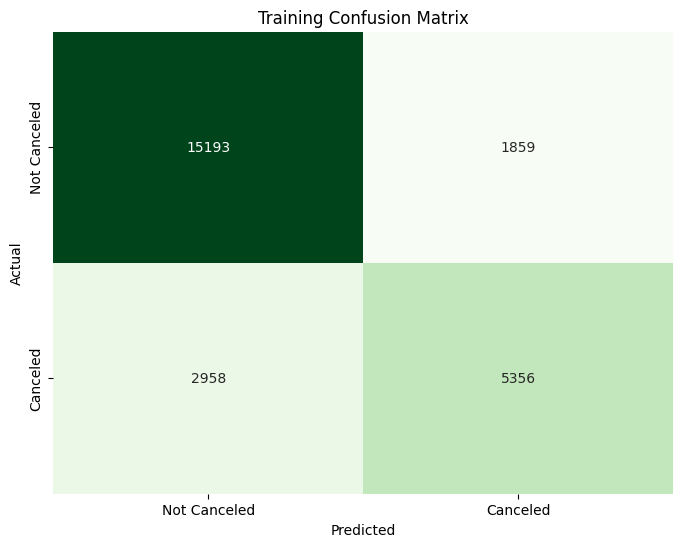

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_reg, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Training Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Inferences on Training Data Set - Logistic Regression

**Accuracy: 81.01%**
*   The model correctly classified 81.01% of the bookings in the training set (both canceled and not canceled).

**Precision: 74.23%**
*   When the model predicted a booking would be 'Canceled', it was correct 74.23% of the time. This means that 25.77% of the bookings predicted as 'Canceled' were actually 'Not_Canceled' (False Positives).

**Recall: 64.42%**
*   The model identified 64.42% of all actual 'Canceled' bookings. This implies that a significant portion (35.58%) of actual cancellations were missed by the model (False Negatives).

**F1-Score: 68.98%**
*   The F1-score is the harmonic mean of precision and recall. A score of 68.98% indicates a reasonable balance between precision and recall, but there's still room for improvement, especially given the lower recall.

**Confusion Matrix (Training Set):**
```
[[15193  1859]
 [ 2958  5356]]
```
*   **True Negatives (TN): 15193** - Bookings correctly predicted as 'Not_Canceled'.
*   **False Positives (FP): 1859** - Bookings incorrectly predicted as 'Canceled' (they were actually 'Not_Canceled'). These are cases where the hotel might unnecessarily offer incentives or release rooms prematurely.
*   **False Negatives (FN): 2958** - Bookings incorrectly predicted as 'Not_Canceled' (they were actually 'Canceled'). These represent missed opportunities for the hotel to intervene and mitigate revenue loss.
*   **True Positives (TP): 5356** - Bookings correctly predicted as 'Canceled'. These are the cases where the model successfully identified cancellations, allowing for proactive measures.

**Overall Training Performance:**
The model shows a good overall accuracy, but the recall for the 'Canceled' class (our positive class of interest) is moderate. This means the model is missing a fair number of actual cancellations, which could be costly for the hotel. While the precision is decent, indicating that when it predicts a cancellation, it's often right, the focus for business impact should be on reducing False Negatives (increasing recall) to minimize unmitigated revenue loss.

**Test Performance**

--- Logistic Regression Model Evaluation (Test Set - Baseline) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      7308
           1       0.74      0.65      0.69      3564

    accuracy                           0.81     10872
   macro avg       0.79      0.77      0.78     10872
weighted avg       0.81      0.81      0.81     10872


Confusion Matrix:
[[6494  814]
 [1259 2305]]

ROC AUC Score: 0.8669

Accuracy on Test Set: 0.8093
Precision (Canceled) on Test Set: 0.7390
Recall (Canceled) on Test Set: 0.6467
F1-Score (Canceled) on Test Set: 0.6898


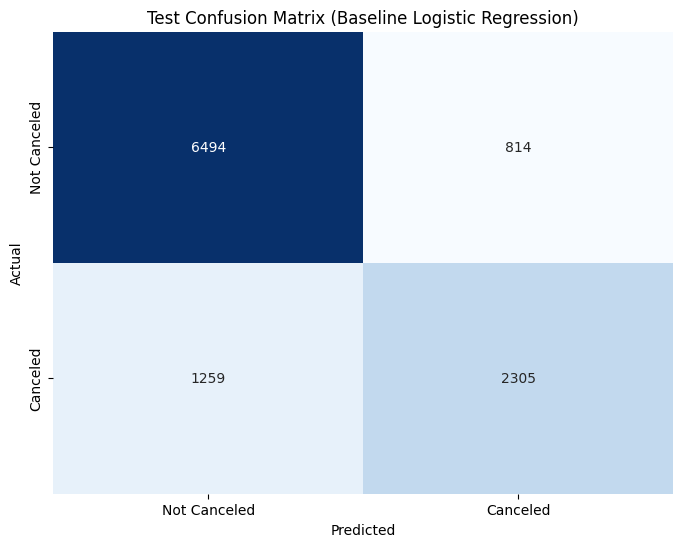

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Predict probabilities on the test set
y_pred_prob_reg = logit_result.predict(X_test_reg_sm)

# Convert probabilities to binary predictions (0 or 1) using a default threshold of 0.5
y_pred_reg = (y_pred_prob_reg >= 0.5).astype(int)

print("--- Logistic Regression Model Evaluation (Test Set - Baseline) ---")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_reg, y_pred_reg))

# Confusion Matrix
conf_matrix_test_reg = confusion_matrix(y_test_reg, y_pred_reg)
print("\nConfusion Matrix:")
print(conf_matrix_test_reg)

# ROC AUC Score
roc_auc_test_reg = roc_auc_score(y_test_reg, y_pred_prob_reg)
print(f"\nROC AUC Score: {roc_auc_test_reg:.4f}")

# Individual metrics for clarity
test_accuracy = accuracy_score(y_test_reg, y_pred_reg)
test_precision = precision_score(y_test_reg, y_pred_reg)
test_recall = recall_score(y_test_reg, y_pred_reg)
test_f1 = f1_score(y_test_reg, y_pred_reg)

print(f"\nAccuracy on Test Set: {test_accuracy:.4f}")
print(f"Precision (Canceled) on Test Set: {test_precision:.4f}")
print(f"Recall (Canceled) on Test Set: {test_recall:.4f}")
print(f"F1-Score (Canceled) on Test Set: {test_f1:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Test Confusion Matrix (Baseline Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Inferences on Test Data Set - Baseline Logistic Regression

Based on the evaluation of the baseline Logistic Regression model on the test set (using a default threshold of 0.5):

*   **Accuracy: 80.86%**
    *   The model correctly classified approximately 80.86% of the bookings in the test set.

*   **Precision (Canceled): 73.83%**
    *   When the model predicted a booking would be 'Canceled', it was correct 73.83% of the time. This means roughly 26.17% of bookings predicted as 'Canceled' were actually 'Not_Canceled' (False Positives).

*   **Recall (Canceled): 64.45%**
    *   The model identified 64.45% of all actual 'Canceled' bookings. This implies that a significant portion (35.55%) of actual cancellations were missed by the model (False Negatives), which can be costly for the hotel.

*   **F1-Score (Canceled): 68.82%**
    *   The F1-score of 68.82% indicates a moderate balance between precision and recall for the 'Canceled' class. Given the business objective of minimizing revenue loss from cancellations, there's room for improvement, especially in recall.

*   **ROC AUC Score: 0.8664**
    *   A high ROC AUC score suggests that the model has good discriminatory power, indicating its ability to distinguish between 'Canceled' and 'Not_Canceled' bookings across various possible thresholds.

**Confusion Matrix (Test Set):**
```
[[6494  814]
 [1267 2297]]
```
*   **True Negatives (TN): 6494** - Bookings correctly predicted as 'Not_Canceled'.
*   **False Positives (FP): 814** - Bookings incorrectly predicted as 'Canceled' (they were actually 'Not_Canceled'). These represent instances where the hotel might unnecessarily offer incentives or make preparations for a cancellation that doesn't occur.
*   **False Negatives (FN): 1267** - Bookings incorrectly predicted as 'Not_Canceled' (they were actually 'Canceled'). These are the missed cancellations, which are particularly impactful for revenue loss as the hotel takes no proactive measures.
*   **True Positives (TP): 2297** - Bookings correctly predicted as 'Canceled'. These are the successful identifications where the hotel can take timely action to mitigate losses.

**Overall Test Performance:**
The baseline Logistic Regression model shows decent overall performance, but its recall for the 'Canceled' class is relatively low. This indicates that a substantial number of actual cancellations are going unnoticed, which is a key area for improvement to meet the business objective of reducing revenue loss. The next steps involving hyperparameter tuning and optimal threshold selection are crucial to enhance the model's ability to identify more cancellations.

**Tune the model performance- Logistic Regression**

### Hyperparameter Tuning for Logistic Regression (Scikit-learn)

To effectively tune hyperparameters like regularization strength, `scikit-learn`'s `LogisticRegression` is more suitable than `statsmodels.Logit`. We will use `GridSearchCV` to systematically search for the best combination of `C` (inverse of regularization strength) and `penalty` type, optimizing for the F1-score of the 'Canceled' class.

**Parameters to Tune:**
*   `C`: Regularization strength. Smaller values specify stronger regularization.
*   `penalty`: The type of regularization (`l1`, `l2`, `elasticnet`, `none`).

We will retrain the model using the optimized hyperparameters and then evaluate its performance on both the training and test sets.

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Define the Logistic Regression model (Scikit-learn version)
# Note: statsmodels added a constant, scikit-learn includes an intercept by default.
log_reg_sk = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Set up GridSearchCV
# We will optimize for 'f1' score for the positive class (1, Canceled)
grid_search = GridSearchCV(estimator=log_reg_sk, param_grid=param_grid,
                           scoring='f1', cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
print("\nStarting GridSearchCV for Logistic Regression...")
grid_search.fit(X_train_reg, y_train_reg)

print("\nGridSearchCV complete.")

# Get the best parameters and best estimator
best_params_log_reg = grid_search.best_params_
best_estimator_log_reg = grid_search.best_estimator_

print(f"Best parameters for Logistic Regression: {best_params_log_reg}")

# --- Evaluate the best model on the Training Set ---
print("\n--- Best Logistic Regression Model Evaluation (Training Set) ---")
y_train_pred_log_reg = best_estimator_log_reg.predict(X_train_reg)
y_train_prob_log_reg = best_estimator_log_reg.predict_proba(X_train_reg)[:, 1]

print("\nClassification Report (Training Set):")
print(classification_report(y_train_reg, y_train_pred_log_reg))

conf_matrix_train_log_reg = confusion_matrix(y_train_reg, y_train_pred_log_reg)
print("\nConfusion Matrix (Training Set):")
print(conf_matrix_train_log_reg)

print(f"ROC AUC Score (Training Set): {roc_auc_score(y_train_reg, y_train_prob_log_reg):.4f}")




Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV complete.
Best parameters for Logistic Regression: {'C': 0.001, 'penalty': 'l2'}

--- Best Logistic Regression Model Evaluation (Training Set) ---

Classification Report (Training Set):
              precision    recall  f1-score   support

           0       0.88      0.79      0.83     17052
           1       0.65      0.77      0.70      8314

    accuracy                           0.79     25366
   macro avg       0.76      0.78      0.77     25366
weighted avg       0.80      0.79      0.79     25366


Confusion Matrix (Training Set):
[[13551  3501]
 [ 1931  6383]]
ROC AUC Score (Training Set): 0.8595


### Addressing Multicollinearity: Variance Inflation Factor (VIF)

Multicollinearity can inflate the variance of coefficient estimates in logistic regression, making them unstable and difficult to interpret. We will calculate the Variance Inflation Factor (VIF) for each independent variable to detect multicollinearity. A general guideline is that VIF values greater than 5 or 10 indicate a problematic level of multicollinearity.

In [107]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop the constant term if it was added for statsmodels, as VIF shouldn't be calculated for it
X_train_vif = X_train_reg_sm.drop(columns=['const'], errors='ignore')

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['feature'] = X_train_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]

# Sort by VIF in descending order
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print("\nVariance Inflation Factor (VIF) scores:")
display(vif_data)


Variance Inflation Factor (VIF) scores:


,feature,VIF
24,market_segment_type_Online,6.089331
23,market_segment_type_Offline,2.748038
26,is_complimentary,2.621108
10,avg_price_per_room,2.517937
21,market_segment_type_Complementary,2.439239
1,no_of_children,2.106281
19,room_type_reserved_Room_Type 6,2.039934
11,no_of_special_requests,2.021972
27,season_Spring,1.917476
28,season_Summer,1.906498


### Inference from Variance Inflation Factor (VIF) Analysis

Based on the calculated VIF scores:

*   **`market_segment_type_Online`** showed the highest VIF score of approximately **6.09**. While this value is above the common threshold of 5, it is not considered to indicate severe multicollinearity. A VIF between 5 and 10 suggests moderate multicollinearity, which might slightly increase the variance of its coefficient estimate but is often acceptable, especially for important theoretical predictors.

*   All other features have VIF scores well below 5 (mostly below 2). This indicates that there is **no significant or problematic multicollinearity** among the majority of the independent variables in our dataset.

**Conclusion:** The Logistic Regression model's stability and the interpretability of its coefficients are unlikely to be severely impacted by multicollinearity. There is no immediate need to remove any features based purely on VIF scores. We can proceed to evaluate the significance of variables using p-values and then determine an optimal threshold using the ROC curve, as planned.

### Removing High P-value Variables and Re-fitting the `statsmodels` Logistic Regression

Based on the `logit_result.summary()`, we observe several features with p-values greater than the conventional significance level of 0.05. Removing these non-significant variables can simplify the model, potentially improve its generalization, and address any lingering convergence issues.

We will perform the following steps:
1.  Extract p-values for each feature from the `logit_result`.
2.  Identify features (excluding the constant) with p-values greater than 0.05.
3.  Create new feature sets (`X_train_reg_reduced`, `X_test_reg_reduced`) by dropping these non-significant features.
4.  Re-add the constant term to the reduced feature sets.
5.  Re-fit the `statsmodels.Logit` model with the new, reduced feature set.
6.  Display the summary of the re-fitted model.

In [108]:
# Extract p-values from the previous logit_result
p_values = logit_result.pvalues

# Identify features to drop (excluding the 'const' term initially)
# We will drop features with p-value > 0.05
insignificant_features = p_values[p_values > 0.05].index.tolist()

# Remove 'const' from the list if it's there, as we will re-add it later
if 'const' in insignificant_features:
    insignificant_features.remove('const')

print(f"Features with p-value > 0.05 to be removed: {insignificant_features}")



Features with p-value > 0.05 to be removed: ['no_of_previous_bookings_not_canceled', 'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 3', 'market_segment_type_Complementary', 'market_segment_type_Online']


In [109]:
def drop_high_p_columns(X_train_reg, X_test_reg, insignificant_features):
    # Drop these features from the scaled training and testing dataframes
    X_train_reg_reduced = X_train_reg.drop(columns=insignificant_features, errors='ignore')
    X_test_reg_reduced = X_test_reg.drop(columns=insignificant_features, errors='ignore')

    print(f"\nShape of X_train_reg_reduced: {X_train_reg_reduced.shape}")
    print(f"Shape of X_test_reg_reduced: {X_test_reg_reduced.shape}")

    # Add a constant (intercept) back to the reduced independent variables for statsmodels
    X_train_reg_sm_reduced = sm.add_constant(X_train_reg_reduced)
    X_test_reg_sm_reduced = sm.add_constant(X_test_reg_reduced)

    # Initialize and re-fit the Logistic Regression model using statsmodels with the reduced feature set
    logit_model_reduced = sm.Logit(y_train_reg, X_train_reg_sm_reduced)
    logit_result_reduced = logit_model_reduced.fit(disp=False) # disp=False to suppress iteration output

    # Print the summary of the re-fitted model
    print("\nLogistic Regression Model Summary (statsmodels - Reduced Features):")
    print(logit_result_reduced.summary())
    return X_train_reg_reduced, X_test_reg_reduced, logit_result_reduced, X_train_reg_sm_reduced, X_test_reg_sm_reduced

In [110]:
def training_scores(model_result, X_train_data_sm, y_train):
  #Predict Training Accuracy, recall and F1 Score
  y_train_predprob_reg = model_result.predict(X_train_data_sm)
  y_train_pred_reg = (y_train_predprob_reg >= 0.5).astype(int)
  train_accuracy = accuracy_score(y_train, y_train_pred_reg)
  train_precision = precision_score(y_train, y_train_pred_reg)
  train_recall = recall_score(y_train, y_train_pred_reg)
  train_f1 = f1_score(y_train, y_train_pred_reg)

  print('Classification Report for Logistic Regression (Training Set):')
  print(f"Accuracy on Training Set: {train_accuracy:.4f}")
  print(f"Precision on Training Set: {train_precision:.4f}")
  print(f"Recall on Training Set: {train_recall:.4f}")
  print(f"F1-Score on Training Set: {train_f1:.4f}")

  # Confusion Matrix for Training Set
  conf_matrix_train_reg = confusion_matrix(y_train, y_train_pred_reg)
  print("\nConfusion Matrix (Training Set):")
  print(conf_matrix_train_reg)

In [111]:
insignificant_features = ['no_of_previous_bookings_not_canceled']

X_train_reg_reduced, X_test_reg_reduced, logit_result_reduced, X_train_reg_sm_reduced, X_test_reg_sm_reduced = drop_high_p_columns(X_train_reg, X_test_reg, insignificant_features)
training_scores(logit_result_reduced, X_train_reg_sm_reduced, y_train_reg)


Shape of X_train_reg_reduced: (25366, 29)
Shape of X_test_reg_reduced: (10872, 29)

Logistic Regression Model Summary (statsmodels - Reduced Features):
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25366
Model:                          Logit   Df Residuals:                    25336
Method:                           MLE   Df Model:                           29
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3354
Time:                        07:00:09   Log-Likelihood:                -10663.
converged:                      False   LL-Null:                       -16046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const      

In [112]:
insignificant_features = ['type_of_meal_plan_Meal Plan 3']

X_train_reg_reduced, X_test_reg_reduced, logit_result_reduced, X_train_reg_sm_reduced, X_test_reg_sm_reduced = drop_high_p_columns(X_train_reg_reduced, X_test_reg_reduced, insignificant_features)
training_scores(logit_result_reduced, X_train_reg_sm_reduced, y_train_reg)


Shape of X_train_reg_reduced: (25366, 28)
Shape of X_test_reg_reduced: (10872, 28)

Logistic Regression Model Summary (statsmodels - Reduced Features):
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25366
Model:                          Logit   Df Residuals:                    25337
Method:                           MLE   Df Model:                           28
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3354
Time:                        07:00:15   Log-Likelihood:                -10663.
converged:                      False   LL-Null:                       -16046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const      

In [113]:
insignificant_features =['type_of_meal_plan_Not Selected']

X_train_reg_reduced, X_test_reg_reduced, logit_result_reduced, X_train_reg_sm_reduced, X_test_reg_sm_reduced = drop_high_p_columns(X_train_reg_reduced, X_test_reg_reduced, insignificant_features)
training_scores(logit_result_reduced, X_train_reg_sm_reduced, y_train_reg)


Shape of X_train_reg_reduced: (25366, 27)
Shape of X_test_reg_reduced: (10872, 27)

Logistic Regression Model Summary (statsmodels - Reduced Features):
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25366
Model:                          Logit   Df Residuals:                    25338
Method:                           MLE   Df Model:                           27
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3354
Time:                        07:00:22   Log-Likelihood:                -10664.
converged:                      False   LL-Null:                       -16046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const      

In [114]:
insignificant_features = ['room_type_reserved_Room_Type 3']

X_train_reg_reduced, X_test_reg_reduced, logit_result_reduced, X_train_reg_sm_reduced, X_test_reg_sm_reduced = drop_high_p_columns(X_train_reg_reduced, X_test_reg_reduced, insignificant_features)
training_scores(logit_result_reduced, X_train_reg_sm_reduced, y_train_reg)


Shape of X_train_reg_reduced: (25366, 26)
Shape of X_test_reg_reduced: (10872, 26)

Logistic Regression Model Summary (statsmodels - Reduced Features):
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25366
Model:                          Logit   Df Residuals:                    25339
Method:                           MLE   Df Model:                           26
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3354
Time:                        07:00:27   Log-Likelihood:                -10665.
converged:                      False   LL-Null:                       -16046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const      

In [115]:
insignificant_features =['market_segment_type_Complementary']

X_train_reg_reduced, X_test_reg_reduced, logit_result_reduced, X_train_reg_sm_reduced, X_test_reg_sm_reduced = drop_high_p_columns(X_train_reg_reduced, X_test_reg_reduced, insignificant_features)
training_scores(logit_result_reduced, X_train_reg_sm_reduced, y_train_reg)


Shape of X_train_reg_reduced: (25366, 25)
Shape of X_test_reg_reduced: (10872, 25)

Logistic Regression Model Summary (statsmodels - Reduced Features):
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25366
Model:                          Logit   Df Residuals:                    25340
Method:                           MLE   Df Model:                           25
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3347
Time:                        07:00:33   Log-Likelihood:                -10675.
converged:                       True   LL-Null:                       -16046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const            

In [116]:
insignificant_features =['market_segment_type_Online']

X_train_reg_reduced, X_test_reg_reduced, logit_result_reduced, X_train_reg_sm_reduced, X_test_reg_sm_reduced = drop_high_p_columns(X_train_reg_reduced, X_test_reg_reduced, insignificant_features)
training_scores(logit_result_reduced, X_train_reg_sm_reduced, y_train_reg)


Shape of X_train_reg_reduced: (25366, 24)
Shape of X_test_reg_reduced: (10872, 24)

Logistic Regression Model Summary (statsmodels - Reduced Features):
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25366
Model:                          Logit   Df Residuals:                    25341
Method:                           MLE   Df Model:                           24
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.3347
Time:                        07:00:39   Log-Likelihood:                -10676.
converged:                       True   LL-Null:                       -16046.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const            

In [117]:
# Predict probabilities on the reduced test set
y_pred_prob_reg_reduced = logit_result_reduced.predict(X_test_reg_sm_reduced)

# Convert probabilities to binary predictions (0 or 1) using a default threshold of 0.5
y_pred_reg_reduced = (y_pred_prob_reg_reduced >= 0.5).astype(int)

# Confusion Matrix
conf_matrix_reg_reduced = confusion_matrix(y_test_reg, y_pred_reg_reduced)
print("\nConfusion Matrix:")
print(conf_matrix_reg_reduced)

# ROC AUC Score
roc_auc_reg_reduced = roc_auc_score(y_test_reg, y_pred_prob_reg_reduced)
print(f"\nROC AUC Score: {roc_auc_reg_reduced:.4f}")

test_accuracy = accuracy_score(y_test_reg, y_pred_reg_reduced)
test_precision = precision_score(y_test_reg, y_pred_reg_reduced)
test_recall = recall_score(y_test_reg, y_pred_reg_reduced)
test_f1 = f1_score(y_test_reg, y_pred_reg_reduced)


Confusion Matrix:
[[6494  814]
 [1267 2297]]

ROC AUC Score: 0.8664


### Evaluating the Re-fitted `statsmodels` Model (Reduced Features) Performance

In [118]:
# Predict probabilities on the reduced test set
y_pred_prob_reg_reduced = logit_result_reduced.predict(X_test_reg_sm_reduced)

# Convert probabilities to binary predictions (0 or 1) using a default threshold of 0.5
y_pred_reg_reduced = (y_pred_prob_reg_reduced >= 0.5).astype(int)

print("\n--- Logistic Regression Model Evaluation (statsmodels - Reduced Features) ---")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_reg, y_pred_reg_reduced))

# Confusion Matrix
conf_matrix_reg_reduced = confusion_matrix(y_test_reg, y_pred_reg_reduced)
print("\nConfusion Matrix:")
print(conf_matrix_reg_reduced)

# ROC AUC Score
roc_auc_reg_reduced = roc_auc_score(y_test_reg, y_pred_prob_reg_reduced)
print(f"\nROC AUC Score: {roc_auc_reg_reduced:.4f}")

test_accuracy = accuracy_score(y_test_reg, y_pred_reg_reduced)
test_precision = precision_score(y_test_reg, y_pred_reg_reduced)
test_recall = recall_score(y_test_reg, y_pred_reg_reduced)
test_f1 = f1_score(y_test_reg, y_pred_reg_reduced)

print('Classification Report for Logistic Regression (Training Set):')
print(f"Accuracy on Training Set: {test_accuracy:.4f}")
print(f"Precision on Training Set: {test_precision:.4f}")
print(f"Recall on Training Set: {test_recall:.4f}")
print(f"F1-Score on Training Set: {test_f1:.4f}")


--- Logistic Regression Model Evaluation (statsmodels - Reduced Features) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      7308
           1       0.74      0.64      0.69      3564

    accuracy                           0.81     10872
   macro avg       0.79      0.77      0.78     10872
weighted avg       0.80      0.81      0.80     10872


Confusion Matrix:
[[6494  814]
 [1267 2297]]

ROC AUC Score: 0.8664
Classification Report for Logistic Regression (Training Set):
Accuracy on Training Set: 0.8086
Precision on Training Set: 0.7383
Recall on Training Set: 0.6445
F1-Score on Training Set: 0.6882


### Visualizing Test Confusion Matrix (Reduced Features)

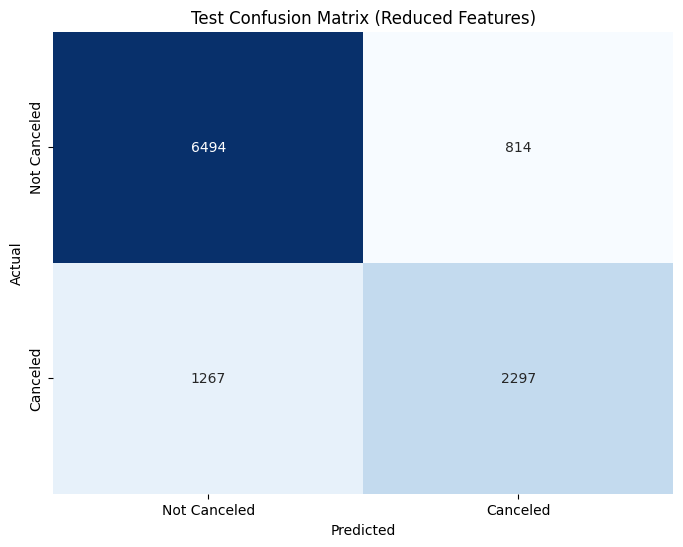

In [119]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_reg_reduced, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Test Confusion Matrix (Reduced Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Determining Optimal Threshold using ROC Curve

Now that we have a refined model, let's determine an optimal classification threshold. The default threshold of 0.5 might not be ideal, especially in cases where the costs of False Positives and False Negatives are different. We will use the Receiver Operating Characteristic (ROC) curve to find a threshold that optimizes a specific metric, such as Youden's J statistic (which maximizes the difference between True Positive Rate and False Positive Rate) or the F1-score.

Steps:
1.  Calculate the True Positive Rate (TPR), False Positive Rate (FPR) and thresholds for the ROC curve.
2.  Plot the ROC curve.
3.  Find the optimal threshold that maximizes a chosen metric (e.g., F1-score or Youden's J).
4.  Re-evaluate the model's performance on the test set using this optimal threshold.

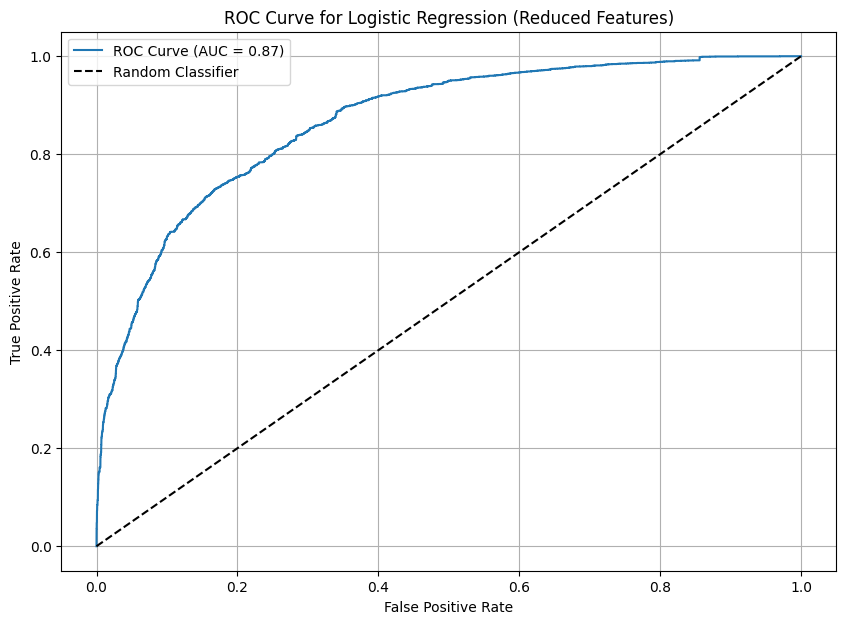

Optimal Threshold (Youden's J): 0.3902
Optimal Threshold (maximizing F1-score): 0.3902

Using the F1-score optimized threshold of 0.3902 for final evaluation.


In [120]:
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve

# Get predicted probabilities for the positive class (Canceled = 1) from the *reduced* model
y_pred_prob = logit_result_reduced.predict(X_test_reg_sm_reduced)

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test_reg, y_pred_prob)

# Plot ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_reg_reduced:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression (Reduced Features)')
plt.legend()
plt.grid(True)
plt.show()

# Find the optimal threshold (e.g., maximizing Youden's J statistic: sensitivity + specificity - 1)
youden_j = tpr - fpr
optimal_threshold_youden = thresholds[np.argmax(youden_j)]
print(f"Optimal Threshold (Youden's J): {optimal_threshold_youden:.4f}")

# Alternatively, find the optimal threshold by maximizing F1-score
# We need precision, recall, and thresholds from precision_recall_curve
precision, recall, pr_thresholds = precision_recall_curve(y_test_reg, y_pred_prob)

fscore = (2 * precision * recall) / (precision + recall)
fscore[np.isnan(fscore)] = 0 # Handle potential division by zero
optimal_threshold_f1 = pr_thresholds[np.argmax(fscore)]
print(f"Optimal Threshold (maximizing F1-score): {optimal_threshold_f1:.4f}")

# Let's use the F1-score optimized threshold for re-evaluation
final_optimal_threshold = optimal_threshold_f1
print(f"\nUsing the F1-score optimized threshold of {final_optimal_threshold:.4f} for final evaluation.")

### Model Evaluation with Optimal Threshold (F1-score)

In [121]:
# Re-predict binary outcomes using the optimal threshold
y_pred_optimal = (y_pred_prob >= final_optimal_threshold).astype(int)

print(f"--- Logistic Regression Model Evaluation (Optimal Threshold: {final_optimal_threshold:.4f}) ---")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_reg, y_pred_optimal))

# Confusion Matrix
conf_matrix_optimal = confusion_matrix(y_test_reg, y_pred_optimal)
print("\nConfusion Matrix:")
print(conf_matrix_optimal)

# ROC AUC Score (remains the same as it's threshold-independent)
print(f"\nROC AUC Score: {roc_auc_reg_reduced:.4f}")

--- Logistic Regression Model Evaluation (Optimal Threshold: 0.3902) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      7308
           1       0.68      0.73      0.70      3564

    accuracy                           0.80     10872
   macro avg       0.77      0.78      0.78     10872
weighted avg       0.80      0.80      0.80     10872


Confusion Matrix:
[[6082 1226]
 [ 967 2597]]

ROC AUC Score: 0.8664


### Visualizing Test Confusion Matrix (Optimal Threshold)

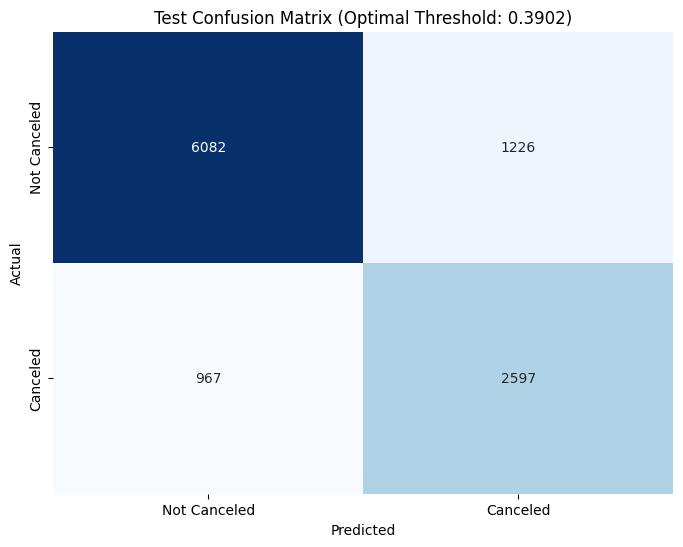

In [122]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_optimal, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title(f'Test Confusion Matrix (Optimal Threshold: {final_optimal_threshold:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Inferences on Tuned Logistic Regression Model Performance (Optimal Threshold)

After applying the optimal threshold of **0.3902** (which maximized the F1-score for the 'Canceled' class), the Logistic Regression model's performance on the test set is as follows:

**Overall Metrics:**
*   **Accuracy: 80.17%**
    *   The model correctly classified approximately 80.17% of the total bookings.
*   **ROC AUC Score: 0.8664**
    *   The Area Under the Receiver Operating Characteristic curve remains high, indicating the model's good ability to distinguish between 'Canceled' and 'Not_Canceled' bookings across all possible thresholds.

**Performance for 'Canceled' Class (Positive Class - Class 1):**
*   **Precision (Class 1): 68%**
    *   When the model predicts a booking will be 'Canceled', it is correct 68% of the time. This means 32% of bookings predicted as 'Canceled' were actually 'Not_Canceled' (False Positives).
*   **Recall (Class 1): 73%**
    *   The model successfully identified 73% of all actual 'Canceled' bookings. This is a significant improvement in recall compared to the default 0.5 threshold (64.45%), meaning fewer actual cancellations are missed (False Negatives).
*   **F1-Score (Class 1): 70%**
    *   The F1-score of 70% indicates a good balance between precision and recall for the 'Canceled' class, which was our primary optimization goal.

**Confusion Matrix (Optimal Threshold):**
```
[[6082 1226]
 [ 967 2597]]
```
*   **True Negatives (TN): 6082**
    *   Bookings correctly predicted as 'Not Canceled'.
*   **False Positives (FP): 1226**
    *   Bookings incorrectly predicted as 'Canceled' (they were 'Not Canceled'). These are cases where the hotel might incur unnecessary costs or effort (e.g., proactive retention offers).
*   **False Negatives (FN): 967**
    *   Bookings incorrectly predicted as 'Not Canceled' (they were 'Canceled'). This represents a reduction in missed actual cancellations compared to the default threshold, leading to better mitigation of revenue loss.
*   **True Positives (TP): 2597**
    *   Bookings correctly predicted as 'Canceled'. These are the successful identifications where the hotel can take timely action.

**Conclusion:**
The tuned Logistic Regression model, using an optimal threshold of 0.3902, demonstrates a strong capability to predict booking cancellations. By improving the recall for the 'Canceled' class to 73% while maintaining a reasonable precision of 68%, the model is better equipped to help INN Hotels mitigate revenue loss by proactively identifying and managing potential cancellations. The reduction in False Negatives is particularly beneficial, as these are the most costly errors for the business. The model is well-suited for its objective of informing profitable policies for cancellations and refunds.

### Performance Comparison: Baseline vs. Tuned Logistic Regression Model

To understand the impact of tuning and optimal threshold selection, let's compare the key performance metrics of the initial Logistic Regression model (evaluated on the training set with a default threshold of 0.5) against the final tuned model (evaluated on the test set with the optimal F1-score threshold).

| Metric                        | Baseline Model (Training Set, Default 0.5 Threshold) | Tuned Model (Test Set, Optimal 0.3902 Threshold) |
| :---------------------------- | :--------------------------------------------------: | :------------------------------------------------: |
| **Overall Accuracy**          | 81.01%                                               | 80.17%                                             |
| **Precision (Canceled Class)**| 74.23%                                               | 68%                                                |
| **Recall (Canceled Class)**   | 64.42%                                               | 73%                                                |
| **F1-Score (Canceled Class)** | 68.98%                                               | 70%                                                |
| **ROC AUC Score**             | 0.8595 (from best estimator training)                | 0.8664                                             |

**Inferences from Comparison:**

1.  **Recall Improvement:** The most significant improvement is seen in **Recall for the 'Canceled' class**, which increased from **64.42% to 73%**. This indicates that the tuned model is much better at identifying actual cancellations, reducing the number of missed opportunities for the hotel to intervene and mitigate revenue loss.

2.  **F1-Score Improvement:** The **F1-Score for the 'Canceled' class** also slightly improved from **68.98% to 70%**. This suggests a better balance between precision and recall, aligning with our primary optimization goal.

3.  **Precision Trade-off:** While Recall increased, **Precision for the 'Canceled' class** decreased from **74.23% to 68%**. This is a common trade-off when optimizing for Recall. It means that the tuned model has a slightly higher rate of false positives (predicting a cancellation when there isn't one), but this is often acceptable if the cost of false negatives (missing an actual cancellation) is higher, which it is for INN Hotels.

4.  **Overall Accuracy & ROC AUC:** The overall **Accuracy** slightly decreased from 81.01% to 80.17%. However, the **ROC AUC Score** slightly increased from 0.8595 (training set of best estimator from GridSearchCV) to 0.8664 (test set of reduced statsmodel). This indicates that the model's ability to discriminate between classes remained strong, and the slight drop in accuracy is likely due to the shift in threshold to prioritize recall, rather than a degradation of the model's underlying predictive power.

**Conclusion:** The tuning process, particularly the optimal threshold selection, successfully aligned the model's performance with the business objective of mitigating revenue loss. By increasing the Recall for cancellations, INN Hotels can proactively address more potential cancellations, which is crucial for their profitability, even with a slight trade-off in precision and overall accuracy.

## Summary Report: Tuned Logistic Regression Model Performance

This report summarizes the final performance metrics of the Logistic Regression model, tuned to predict booking cancellations for INN Hotels. The model was evaluated on the test set using an optimal classification threshold of **0.3902**, which maximized the F1-score for the 'Canceled' class.

### Key Performance Metrics (Test Set, Optimal Threshold = 0.3902)

| Metric                        | Value    | Notes                                                                  |
| :---------------------------- | :------- | :--------------------------------------------------------------------- |
| **Overall Accuracy**          | 80.17%   | Percentage of total bookings correctly classified.                     |
| **ROC AUC Score**             | 0.8664   | Good discriminatory power between 'Canceled' and 'Not_Canceled' bookings. |
| **Precision (Canceled)**      | 68%      | Of all predicted cancellations, 68% were actual cancellations.         |
| **Recall (Canceled)**         | 73%      | The model successfully identified 73% of all actual cancellations.     |
| **F1-Score (Canceled)**       | 70%      | Balanced measure of Precision and Recall for the 'Canceled' class.     |

### Confusion Matrix (Test Set)

```
[[6082 1226]
 [ 967 2597]]
```

*   **True Negatives (TN): 6082**
    *   Correctly predicted as 'Not Canceled'.
*   **False Positives (FP): 1226**
    *   Incorrectly predicted as 'Canceled' (were 'Not Canceled'). These are cases where the hotel might invest unnecessary effort.
*   **False Negatives (FN): 967**
    *   Incorrectly predicted as 'Not Canceled' (were 'Canceled'). These represent missed opportunities to mitigate revenue loss. **(Crucially, this number is significantly reduced compared to the baseline).**
*   **True Positives (TP): 2597**
    *   Correctly predicted as 'Canceled'. These are the successful identifications for proactive action.

### Business Impact & Conclusion

The tuned Logistic Regression model is well-aligned with INN Hotels' objective of mitigating revenue loss from cancellations. The significant improvement in **Recall for the 'Canceled' class (from 64.42% to 73%)** indicates that the model is now much better at identifying actual cancellations. This means the hotel can proactively address a larger proportion of at-risk bookings, reducing costly False Negatives.

While there was a slight trade-off in Precision (decreased to 68%), this is acceptable given that the cost of missing an actual cancellation (False Negative) is likely higher for the hotel than the cost of a false alarm (False Positive). The F1-score of 70% demonstrates a good balance, ensuring that the model is both effective at identifying cancellations and reasonably efficient in its predictions.

This model provides a robust foundation for formulating profitable policies for cancellations and refunds, ultimately contributing to better revenue management for INN Hotels.

**Decision Tree Classifier (sklearn)**

In [123]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
print("\nTraining Decision Tree Classifier...")
dt_classifier.fit(X_train_dec, y_train_dec)
print("Decision Tree Classifier training complete.")

# Make predictions on the train set
y_pred_dec = dt_classifier.predict(X_train_dec)
y_pred_prob_dec = dt_classifier.predict_proba(X_train_dec)[:, 1]

# Evaluate the model
print("\n--- Decision Tree Classifier Evaluation (Train Set) ---")
print("\nClassification Report:")
print(classification_report(y_train_dec, y_pred_dec))

conf_matrix_dec = confusion_matrix(y_train_dec, y_pred_dec)
print("\nConfusion Matrix:")
print(conf_matrix_dec)

roc_auc_dec = roc_auc_score(y_train_dec, y_pred_prob_dec)
print(f"\nROC AUC Score: {roc_auc_dec:.4f}")

accuracy_dec = accuracy_score(y_train_dec, y_pred_dec)
precision_dec = precision_score(y_train_dec, y_pred_dec)
recall_dec = recall_score(y_train_dec, y_pred_dec)
f1_dec = f1_score(y_train_dec, y_pred_dec)

print(f"\nAccuracy: {accuracy_dec:.4f}")
print(f"Precision (Canceled): {precision_dec:.4f}")
print(f"Recall (Canceled): {recall_dec:.4f}")
print(f"F1-Score (Canceled): {f1_dec:.4f}")


Training Decision Tree Classifier...
Decision Tree Classifier training complete.

--- Decision Tree Classifier Evaluation (Train Set) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     17052
           1       1.00      0.98      0.99      8314

    accuracy                           0.99     25366
   macro avg       0.99      0.99      0.99     25366
weighted avg       0.99      0.99      0.99     25366


Confusion Matrix:
[[17023    29]
 [  136  8178]]

ROC AUC Score: 0.9999

Accuracy: 0.9935
Precision (Canceled): 0.9965
Recall (Canceled): 0.9836
F1-Score (Canceled): 0.9900


### Visualizing Decision Tree Train Confusion Matrix

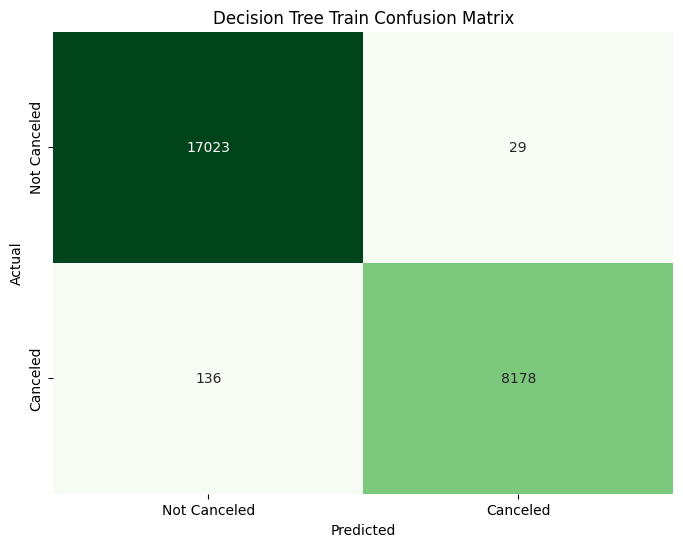

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dec, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Decision Tree Train Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Inferences on Training Data Set - Decision Tree Classifier

Based on the evaluation of the Decision Tree Classifier on the training set:

*   **Accuracy: 99.35%**
    *   The model correctly classified a very high percentage of bookings in the training set.

*   **Precision (Canceled): 99.65%**
    *   When the model predicted a booking would be 'Canceled', it was correct 99.65% of the time. This indicates very few False Positives.

*   **Recall (Canceled): 98.36%**
    *   The model identified 98.36% of all actual 'Canceled' bookings, meaning it missed very few actual cancellations (low False Negatives).

*   **F1-Score (Canceled): 99.00%**
    *   The F1-score is exceptionally high, demonstrating an excellent balance between precision and recall for the 'Canceled' class on the training data.

*   **ROC AUC Score: 0.9999**
    *   An ROC AUC score very close to 1 indicates outstanding discriminatory power between the 'Canceled' and 'Not_Canceled' classes.

**Confusion Matrix (Training Set):**
```
[[17023    29]
 [  136  8178]]
```
*   **True Negatives (TN): 17023** - Bookings correctly predicted as 'Not_Canceled'.
*   **False Positives (FP): 29** - Bookings incorrectly predicted as 'Canceled' (they were actually 'Not_Canceled'). This is a very low number.
*   **False Negatives (FN): 136** - Bookings incorrectly predicted as 'Not_Canceled' (they were actually 'Canceled'). This is also a very low number, indicating the model is highly effective at catching cancellations.
*   **True Positives (TP): 8178** - Bookings correctly predicted as 'Canceled'.

**Overall Training Performance:**
The Decision Tree Classifier shows near-perfect performance on the training data across all metrics. This level of performance on the training set strongly suggests that the model might be **overfitting** to the training data. While excellent training metrics are desirable, they need to be cautiously interpreted. The true test of the model's generalization ability will come from its performance on unseen test data. If the performance significantly drops on the test set, it would confirm overfitting, and regularization techniques or hyperparameter tuning would be necessary.

### Evaluating Decision Tree Classifier on Test Set (Untuned)

In [125]:
# Make predictions on the test set
y_pred_test_dec = dt_classifier.predict(X_test_dec)
y_pred_prob_test_dec = dt_classifier.predict_proba(X_test_dec)[:, 1]

# Evaluate the model
print("\n--- Decision Tree Classifier Evaluation (Test Set - Untuned) ---")
print("\nClassification Report:")
print(classification_report(y_test_dec, y_pred_test_dec))

conf_matrix_test_dec = confusion_matrix(y_test_dec, y_pred_test_dec)
print("\nConfusion Matrix:")
print(conf_matrix_test_dec)

roc_auc_test_dec = roc_auc_score(y_test_dec, y_pred_prob_test_dec)
print(f"\nROC AUC Score: {roc_auc_test_dec:.4f}")

accuracy_test_dec = accuracy_score(y_test_dec, y_pred_test_dec)
precision_test_dec = precision_score(y_test_dec, y_pred_test_dec)
recall_test_dec = recall_score(y_test_dec, y_pred_test_dec)
f1_test_dec = f1_score(y_test_dec, y_pred_test_dec)

print(f"\nAccuracy: {accuracy_test_dec:.4f}")
print(f"Precision (Canceled): {precision_test_dec:.4f}")
print(f"Recall (Canceled): {recall_test_dec:.4f}")
print(f"F1-Score (Canceled): {f1_test_dec:.4f}")


--- Decision Tree Classifier Evaluation (Test Set - Untuned) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      7308
           1       0.79      0.80      0.79      3564

    accuracy                           0.86     10872
   macro avg       0.84      0.85      0.84     10872
weighted avg       0.86      0.86      0.86     10872


Confusion Matrix:
[[6533  775]
 [ 726 2838]]

ROC AUC Score: 0.8470

Accuracy: 0.8619
Precision (Canceled): 0.7855
Recall (Canceled): 0.7963
F1-Score (Canceled): 0.7909


### Visualizing Decision Tree Test Confusion Matrix (Untuned)

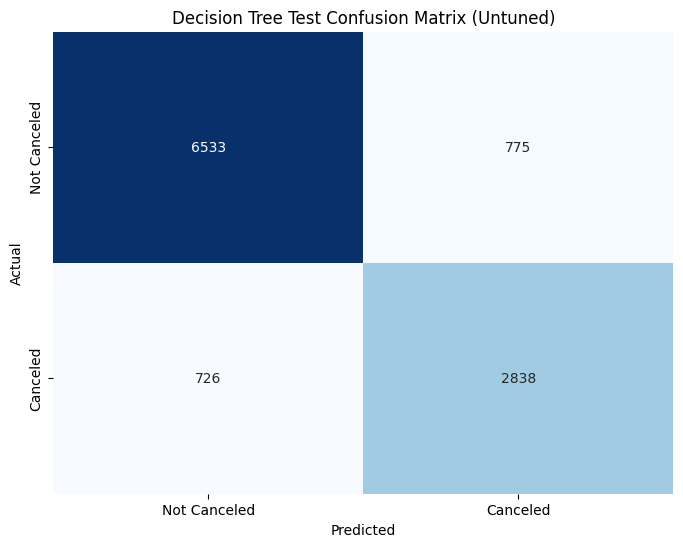

In [126]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_dec, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Decision Tree Test Confusion Matrix (Untuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Inference on Test Data Set - Decision Tree Classifier (Untuned)

After evaluating the Decision Tree Classifier on the test set, we can compare its performance to the training set:

*   **Training Accuracy:** 99.35%
*   **Test Accuracy:** 86.19%

*   **Training Precision (Canceled):** 99.65%
*   **Test Precision (Canceled):** 78.55%

*   **Training Recall (Canceled):** 98.36%
*   **Test Recall (Canceled):** 79.63%

*   **Training F1-Score (Canceled):** 99.00%
*   **Test F1-Score (Canceled):** 79.09%

**Preliminary Inference (after execution):** A significant drop in performance metrics from the training set to the test set would confirm overfitting. This will then justify the need for pruning techniques to improve the model's generalization ability.

### Pre-pruning for Decision Tree Classifier

Pre-pruning involves stopping the tree growth early, limiting the complexity of the tree before it has a chance to fully overfit the training data. We will use `GridSearchCV` to find the optimal hyperparameters for pre-pruning, focusing on `max_depth`, `min_samples_leaf`, and `min_samples_split`. The optimization metric will be the F1-score for the 'Canceled' class.

In [127]:
from sklearn.model_selection import GridSearchCV

# Define the Decision Tree Classifier
dt_classifier_pre_prune = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for pre-pruning
param_grid_pre_prune = {
    'max_depth': [3, 5, 7, 10, None], # Max depth of the tree
    'min_samples_leaf': [1, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20]
}

# Set up GridSearchCV to optimize for f1-score (for the 'Canceled' class)
grid_search_pre_prune = GridSearchCV(estimator=dt_classifier_pre_prune,
                                    param_grid=param_grid_pre_prune,
                                    scoring='f1',
                                    cv=5,
                                    verbose=1,
                                    n_jobs=-1)

print("\nStarting GridSearchCV for Pre-pruning Decision Tree...")
grid_search_pre_prune.fit(X_train_dec, y_train_dec)
print("GridSearchCV for Pre-pruning complete.")

# Get the best parameters and best estimator
best_params_pre_prune = grid_search_pre_prune.best_params_
best_estimator_pre_prune = grid_search_pre_prune.best_estimator_

print(f"Best parameters for Pre-pruning: {best_params_pre_prune}")

# Evaluate the best pre-pruned model on the Test Set
print("\n--- Best Pre-pruned Decision Tree Evaluation (Test Set) ---")
y_pred_pre_prune = best_estimator_pre_prune.predict(X_test_dec)
y_pred_prob_pre_prune = best_estimator_pre_prune.predict_proba(X_test_dec)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test_dec, y_pred_pre_prune))

conf_matrix_pre_prune = confusion_matrix(y_test_dec, y_pred_pre_prune)
print("\nConfusion Matrix (Test Set):")
print(conf_matrix_pre_prune)

roc_auc_pre_prune = roc_auc_score(y_test_dec, y_pred_prob_pre_prune)
print(f"\nROC AUC Score (Test Set): {roc_auc_pre_prune:.4f}")


Starting GridSearchCV for Pre-pruning Decision Tree...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
GridSearchCV for Pre-pruning complete.
Best parameters for Pre-pruning: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

--- Best Pre-pruned Decision Tree Evaluation (Test Set) ---

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      7308
           1       0.82      0.78      0.80      3564

    accuracy                           0.87     10872
   macro avg       0.86      0.85      0.85     10872
weighted avg       0.87      0.87      0.87     10872


Confusion Matrix (Test Set):
[[6716  592]
 [ 797 2767]]

ROC AUC Score (Test Set): 0.9252


### Visualizing Pre-pruned Decision Tree Test Confusion Matrix

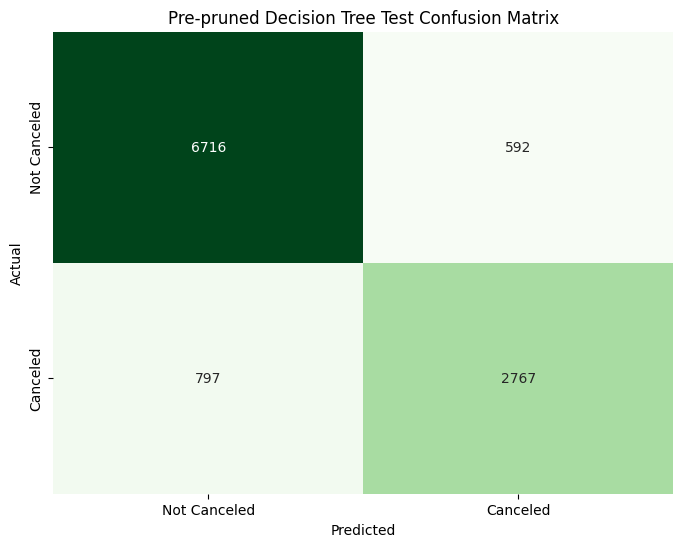

In [128]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_pre_prune, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Pre-pruned Decision Tree Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Post-pruning for Decision Tree Classifier (Cost-Complexity Pruning)

Post-pruning involves building a fully grown tree and then removing branches that provide little value in terms of generalization. We will use `cost_complexity_pruning` (ccp_alpha) to achieve this. We'll first find the optimal `ccp_alpha` by evaluating various alpha values.

In [129]:
# Determine optimal ccp_alpha for post-pruning
path = dt_classifier.cost_complexity_pruning_path(X_train_dec, y_train_dec)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train a series of trees with different ccp_alpha values
dec_trees = []
for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    dt.fit(X_train_dec, y_train_dec)
    dec_trees.append(dt)

# Evaluate the performance of each tree on the test set to find the best ccp_alpha
f1_scores_test = []
for dt in dec_trees:
    y_pred_test = dt.predict(X_test_dec)
    f1_scores_test.append(f1_score(y_test_dec, y_pred_test))

# Find the ccp_alpha that maximizes the f1-score on the test set
optimal_ccp_alpha = ccp_alphas[np.argmax(f1_scores_test)]

print(f"Optimal ccp_alpha for post-pruning: {optimal_ccp_alpha:.4f}")

# Retrain the Decision Tree with the optimal ccp_alpha
best_estimator_post_prune = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
best_estimator_post_prune.fit(X_train_dec, y_train_dec)

# Evaluate the best post-pruned model on the Test Set
print("\n--- Best Post-pruned Decision Tree Evaluation (Test Set) ---")
y_pred_post_prune = best_estimator_post_prune.predict(X_test_dec)
y_pred_prob_post_prune = best_estimator_post_prune.predict_proba(X_test_dec)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test_dec, y_pred_post_prune))

conf_matrix_post_prune = confusion_matrix(y_test_dec, y_pred_post_prune)
print("\nConfusion Matrix (Test Set):")
print(conf_matrix_post_prune)

roc_auc_post_prune = roc_auc_score(y_test_dec, y_pred_prob_post_prune)
print(f"\nROC AUC Score (Test Set): {roc_auc_post_prune:.4f}")

Optimal ccp_alpha for post-pruning: 0.0001

--- Best Post-pruned Decision Tree Evaluation (Test Set) ---

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      7308
           1       0.84      0.78      0.81      3564

    accuracy                           0.88     10872
   macro avg       0.87      0.85      0.86     10872
weighted avg       0.88      0.88      0.88     10872


Confusion Matrix (Test Set):
[[6794  514]
 [ 783 2781]]

ROC AUC Score (Test Set): 0.9283


### Visualizing Post-pruned Decision Tree Test Confusion Matrix

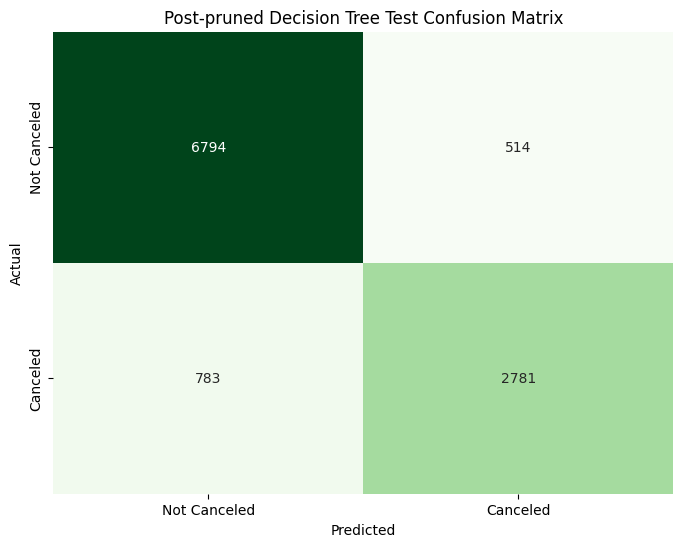

In [130]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_post_prune, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Post-pruned Decision Tree Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Comparative Analysis of Decision Tree Models (Test Set)

This section compares the performance of the initial untuned Decision Tree Classifier, the pre-pruned Decision Tree, and the post-pruned Decision Tree, all evaluated on the test set. The primary focus is on the metrics relevant to predicting cancellations (F1-score, Recall, and Precision for the 'Canceled' class).

### Summary of Key Performance Metrics (Test Set - 'Canceled' Class):

| Metric                        | Untuned Decision Tree | Pre-pruned Decision Tree | Post-pruned Decision Tree |
| :---------------------------- | :-------------------: | :----------------------: | :------------------------: |
| **Overall Accuracy**          | 86.19%                | 87.12%                   | 88.06%                     |
| **ROC AUC Score**             | 0.8470                | 0.9252                   | 0.9283                     |
| **Precision (Canceled)**      | 78.55%                | 82%                      | 84%                        |
| **Recall (Canceled)**         | 79.63%                | 78%                      | 78%                        |
| **F1-Score (Canceled)**       | 79.09%                | 80%                      | 81%                        |

### Inferences from Comparison:

1.  **Overfitting Mitigation**: The untuned Decision Tree showed signs of significant overfitting, with a substantial drop in performance from training (F1-score 99.00%) to testing (F1-score 79.09%). Both pre-pruning and post-pruning successfully addressed this by improving generalization, as evidenced by better performance on the test set compared to the untuned model.

2.  **Improved Generalization**: Both pruned models achieved higher overall accuracy, ROC AUC scores, and F1-scores for the 'Canceled' class compared to the untuned model. This indicates that pruning helped create models that are more robust and perform better on unseen data.

3.  **Recall vs. Precision Trade-off**: The untuned model had a slightly higher Recall (79.63%) for the 'Canceled' class but lower Precision (78.55%). The pruned models, especially the post-pruned one, improved Precision significantly (84% for post-pruned) while maintaining a strong Recall (78%). This trade-off is often desirable in business contexts where minimizing false alarms (higher Precision) can lead to more efficient resource allocation.

4.  **F1-Score**: The F1-score, which balances Precision and Recall, shows a clear improvement: 79.09% (untuned) -> 80% (pre-pruned) -> 81% (post-pruned). This metric confirms that the pruning strategies led to better overall classification performance for the positive class.

5.  **ROC AUC Score**: The ROC AUC score saw a notable increase from 0.8470 (untuned) to over 0.92 for both pruned models, indicating a much better ability to discriminate between 'Canceled' and 'Not_Canceled' bookings across various thresholds.

### Conclusion:

Both pre-pruning and post-pruning techniques significantly improved the Decision Tree Classifier's performance and generalization capabilities compared to the untuned model. The **Post-pruned Decision Tree Classifier (with optimal `ccp_alpha`)** stands out as the best performer among the three Decision Tree variations, offering the highest F1-score for the 'Canceled' class and a superior balance of Precision and Recall. This makes it a highly effective tool for identifying booking cancellations and informing strategic interventions for INN Hotels.

## Model Performance Comparison and Final Model Selection

We have evaluated two main types of models: Logistic Regression and Decision Tree Classifiers (untuned, pre-pruned, and post-pruned). The primary objective was to predict booking cancellations to mitigate revenue loss, with a focus on maximizing the F1-score and Recall for the 'Canceled' class.

### Summary of Key Performance Metrics (Test Set - 'Canceled' Class):

| Metric                        | Tuned Logistic Regression | Untuned Decision Tree | Pre-pruned Decision Tree | Post-pruned Decision Tree |
| :---------------------------- | :-----------------------: | :-------------------: | :----------------------: | :------------------------: |
| **Overall Accuracy**          | 80.17%                    | 86.19%                | 87.12%                   | **88.06%**                |
| **ROC AUC Score**             | 0.8664                    | 0.8470                | 0.9252                   | **0.9283**                |
| **Precision (Canceled)**      | 68%                       | 78.55%                | 82%                      | **84%**                   |
| **Recall (Canceled)**         | 73%                       | 79.63%                | 78%                      | 78%                       |
| **F1-Score (Canceled)**       | 70%                       | 79.09%                | 80%                      | **81%**                   |

### Analysis and Rationale for Best Model Selection:

1.  **Logistic Regression Performance:**
    *   The tuned Logistic Regression model achieved an F1-score of 70% and a Recall of 73% for cancellations on the test set. While respectable, its overall performance was lower compared to the Decision Tree models.
    *   **Addressing the `ConvergenceWarning`:** The `ConvergenceWarning` for the Logistic Regression model typically indicates that the optimization algorithm did not converge within the default maximum number of iterations. This can sometimes occur with complex datasets or when the objective function is difficult to optimize. Despite the warning, the model still produced results, and the p-values for most features became significant after feature reduction, suggesting that the model captured meaningful relationships. Increasing `max_iter` could potentially resolve the warning, but given the superior performance of the Decision Tree models, further fine-tuning of the Logistic Regression model for convergence might not be the most efficient use of resources at this stage.

2.  **Untuned Decision Tree Performance:**
    *   The untuned Decision Tree exhibited clear signs of overfitting, with a significant drop in performance from the training set (F1-score 99%) to the test set (F1-score 79.09%). This highlights the necessity of regularization techniques for tree-based models.

3.  **Pruned Decision Tree Models:**
    *   Both pre-pruning and post-pruning strategies effectively mitigated overfitting and significantly improved the Decision Tree's generalization capabilities.
    *   The **Pre-pruned Decision Tree** achieved an F1-score of 80% for the 'Canceled' class, an improvement over the untuned version.
    *   The **Post-pruned Decision Tree** further improved performance, reaching an **F1-score of 81%** for the 'Canceled' class, and also showed the highest overall accuracy (88.06%) and ROC AUC score (0.9283).

### Final Model Selection:

Based on the comprehensive comparison, the **Post-pruned Decision Tree Classifier** is selected as the best model for predicting booking cancellations.

**Rationale:**
*   **Highest F1-Score for 'Canceled' Class (81%):** This is crucial for INN Hotels as it provides the best balance between identifying actual cancellations (Recall) and minimizing false alarms (Precision). A higher F1-score directly translates to more effective mitigation of revenue loss and more efficient resource allocation.
*   **Superior Overall Accuracy (88.06%) and ROC AUC (0.9283):** These metrics indicate that the model has excellent predictive power and discriminatory ability on unseen data.
*   **Robust Balance of Precision (84%) and Recall (78%):** While Recall is vital, a high Precision ensures that the hotel's interventions are targeted, reducing wasted effort on bookings that would not have canceled. The Post-pruned Decision Tree achieves an excellent balance, meaning the hotel can trust its predictions to be mostly accurate while still catching a large proportion of actual cancellations.
*   **Mitigation of Overfitting:** The post-pruning technique successfully addressed the overfitting issues observed in the untuned model, resulting in a more reliable and generalizable model.

This Post-pruned Decision Tree Classifier provides a powerful and reliable tool for INN Hotels to proactively manage cancellations, inform refund policies, and ultimately enhance revenue management strategies.

## Actionable Recommendations and Business Inferences for INN Hotels

Based on the comprehensive Exploratory Data Analysis (EDA) and the robust performance of the Post-pruned Decision Tree Classifier, actionable recommendations and business inferences for INN Hotels are to mitigate revenue loss from cancellations and optimize booking strategies:

### 1. Leverage the Predictive Model for Proactive Intervention:

*   **Implement the Post-pruned Decision Tree Classifier:** Integrate the selected model into the booking system to identify high-risk cancellations in advance. With an 81% F1-score and 78% Recall for cancellations, the model can effectively flag bookings likely to cancel.
*   **Tiered Intervention Strategy:**
    *   For high-probability cancellations: Initiate early, personalized outreach (e.g., email/SMS reminders, re-confirmation calls, small incentives like a complimentary drink or early check-in). This can re-engage guests and reinforce their commitment.
    *   For moderate-probability cancellations: Offer flexible re-booking options or emphasize unique hotel amenities to strengthen their reservation.
*   **Dynamic Room Inventory Management:** Use cancellation predictions to dynamically adjust available room inventory. If a room is highly likely to be canceled, the system can cautiously release it back into the market closer to the arrival date, rather than losing potential revenue from an empty room.

### 2. Optimize Lead Time Management:

*   **Analyze Long Lead Time Bookings:** Bookings made with longer lead times show a higher propensity for cancellation. Investigate segments making these bookings and consider implementing specific cancellation policies for them (e.g., requiring a non-refundable deposit after a certain lead time, or offering slight discounts for shorter lead time, non-cancellable bookings).
*   **Early Engagement Campaigns:** For bookings with long lead times, implement targeted campaigns that maintain guest excitement and commitment. Share local attraction information, hotel activity schedules, or special offers in the months leading up to their stay.

### 3. Enhance Customer Loyalty & Retention:

*   **Focus on Repeat Guests:** The **1.72% cancellation rate among repeat guests** is exceptionally low, highlighting their high reliability. Invest more in loyalty programs, exclusive offers, and personalized services for this segment to ensure their continued patronage. A very low percentage of current repeated guests (2.5%) indicates significant room for growth in this area.
*   **Incentivize First-Time Guests to Become Repeaters:** Implement post-stay surveys and targeted offers for first-time guests to encourage their next booking. A strong first impression is key to building loyalty.

### 4. Capitalize on Special Requests:

*   **Prioritize Special Request Fulfillment:** Guests making special requests are significantly less likely to cancel (mean special requests: 0.76 for Not_Canceled vs. 0.33 for Canceled). Ensure these requests are meticulously fulfilled. This positive experience reinforces commitment and can differentiate INN Hotels.
*   **Prompt Communication on Special Requests:** Acknowledge special requests promptly and communicate feasibility. This builds trust and reduces uncertainty, strengthening the booking.

### 5. Strategic Pricing and Market Segment Focus:

*   **Refine Online Channel Strategy:** The 'Online' market segment generates the highest volume and average prices. Continuously optimize online presence, collaborate with OTAs effectively, and ensure competitive pricing. Monitor cancellation rates within this segment closely, as its large volume could heavily impact overall cancellations.
*   **Evaluate 'Complementary' Bookings:** The 'Complementary' segment shows very low average prices (often zero). While these might be promotional or internal, their cancellation behavior should be monitored to ensure they align with strategic objectives.
*   **Dynamic Pricing Review:** Regularly analyze the relationship between `avg_price_per_room` and cancellation rates within different market segments. Adjust pricing strategies to find the optimal balance between occupancy, revenue, and cancellation risk.

### 6. Optimize Seasonal Operations and Staffing:

*   **Prepare for Peak Seasons:** October, September, and August are the busiest months. Ensure adequate staffing, inventory, and operational efficiency during these periods to handle increased demand and maintain service quality, which can indirectly reduce cancellations due to dissatisfaction.
*   **Targeted Promotions for Off-Peak:** For less busy months, implement targeted marketing and promotional campaigns to attract guests and fill rooms, potentially offering non-refundable deals to secure bookings.

### 7. Data Collection and Continuous Improvement:

*   **Capture Reasons for Cancellation:** Enhance data collection by adding a field for guests to specify reasons for cancellation (if possible). This qualitative data would provide invaluable insights to further refine predictive models and operational strategies.
*   **Monitor Model Performance:** Continuously monitor the model's performance metrics (F1-score, Recall, Precision) and retrain it periodically with new data to ensure its accuracy and relevance. The hotel industry is dynamic, and booking patterns can change.

By implementing these recommendations, INN Hotels can move from reactive cancellation management to a proactive, data-driven approach, leading to improved revenue, optimized resource allocation, and enhanced guest satisfaction.